# **Case Técnico**

Este projeto foi desenvolvido como parte de aprendizado prático de ciências de dados

O objetivo central foi construir um modelo preditivo capaz de estimar a
probabilidade de inadimplência de cobranças mensais realizadas a clientes de
uma instituição financeira. Um pagamento é considerado inadimplente quando
realizado com 5 ou mais dias de atraso em relação à data de vencimento.

A solução passou pelas seguintes etapas: inspeção e qualidade dos dados,
análise exploratória aprofundada, feature engineering com criação de variáveis
de histórico comportamental, treinamento e comparação de 4 modelos de
classificação, otimização de hiperparâmetros com Optuna, validação temporal com
TimeSeriesSplit e calibração de probabilidades com Isotonic Regression.

O modelo final escolhido foi o LightGBM com calibração isotônica, atingindo
AUC-ROC de 0.9444, Gini de 0.8888 e KS de 0.7573 no conjunto de validação.
As previsões foram geradas para 11.542 cobranças da base de teste, com
probabilidades variando entre 0 e 1, prontas para uso em estratégias proativas
de cobrança.

## **Construção da variável TARGET**

In [ ]:
# ============================================================
# Construção da Variável Target
# ============================================================
# Regra: TARGET = 1 se DATA_PAGAMENTO - DATA_VENCIMENTO >= 5 dias
#                 0 caso contrário
# Casos com DATA_PAGAMENTO nula = inadimplente (pagamento não realizado)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

dev = pd.read_csv("base_pagamentos_desenvolvimento.csv", sep=";")

# Converter datas
for col in ["SAFRA_REF", "DATA_EMISSAO_DOCUMENTO", "DATA_VENCIMENTO", "DATA_PAGAMENTO"]:
    dev[col] = pd.to_datetime(dev[col], errors="coerce")

In [ ]:
dev.head(10)

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,1661240395903230676,2018-08-01,2018-08-17,2018-09-06,2018-09-06,35516.41,6.99
1,1661240395903230676,2018-08-01,2018-08-19,2018-09-11,2018-09-10,17758.21,6.99
2,1661240395903230676,2018-08-01,2018-08-26,2018-09-18,2018-09-17,17431.96,6.99
3,1661240395903230676,2018-08-01,2018-08-30,2018-10-11,2018-10-05,1341.00,6.99
4,1661240395903230676,2018-08-01,2018-08-31,2018-09-20,2018-09-20,21309.85,6.99
5,8274986328479596038,2018-08-01,2018-08-17,2018-09-25,2018-09-25,48811.35,6.99
6,345447888460137901,2018-08-01,2018-08-17,2018-09-05,2018-09-05,55131.20,5.99
7,1003144834589372198,2018-08-01,2018-08-17,2018-09-03,2018-09-03,85855.04,6.99
8,324916756972236008,2018-08-01,2018-08-17,2018-09-03,2018-09-03,42072.00,5.99
9,324916756972236008,2018-08-01,2018-08-19,2018-09-05,2018-09-05,21071.97,5.99


In [ ]:
# Calcular dias de atraso

# Diferença em dias entre pagamento e vencimento
# Negativo = pagou antes; positivo = pagou depois; NaT = não pagou
dev["DIAS_ATRASO"] = (dev["DATA_PAGAMENTO"] - dev["DATA_VENCIMENTO"]).dt.days

print("Distribuição de DIAS_ATRASO")
print(dev["DIAS_ATRASO"].describe())
print(f"\nPagamentos com DATA_PAGAMENTO nula: {dev['DATA_PAGAMENTO'].isna().sum():,}")

Distribuição de DIAS_ATRASO
count    77414.000000
mean        -0.171429
std         25.229477
min      -2661.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        869.000000
Name: DIAS_ATRASO, dtype: float64

Pagamentos com DATA_PAGAMENTO nula: 0


A média de -0.17 significa que na média os clientes pagam praticamente no dia do vencimento, com leve tendência a pagar um dia antes. A mediana de 0 e os percentis 25%, 50% e 75% todos em zero confirmam isso que a grande maioria dos pagamentos acontece exatamente na data de vencimento ou antes. O mínimo de -2661 dias é um outlier extremo que provavelmente representa um erro de dados ou um caso muito atípico e vale investigar. O máximo de 869 dias de atraso também é expressivo equivalente quase 2 anos e meio de atraso em alguma cobrança.

In [ ]:
# Aplicar a regra do target
# TARGET = 1 se pagamento realizado com 5 ou mais dias de atraso
dev["TARGET"] = (dev["DIAS_ATRASO"] >= 5).astype(int)

Aplicamos a regra definida no enunciado: **TARGET = 1** para pagamentos com 5 ou mais dias de atraso e **TARGET = 0** para os demais.

In [ ]:
# Verificar distribuição do target
total      = len(dev)
inad       = dev["TARGET"].sum()
adim       = total - inad
taxa_inad  = inad / total * 100

print(f"\n Distribuição do TARGET")
print(f"  Total de cobranças:  {total:,}")
print(f"  Adimplentes  (0):    {adim:,}  ({100 - taxa_inad:.1f}%)")
print(f"  Inadimplentes (1):   {inad:,}  ({taxa_inad:.1f}%)")


 Distribuição do TARGET
  Total de cobranças:  77,414
  Adimplentes  (0):    71,978  (93.0%)
  Inadimplentes (1):   5,436  (7.0%)


Aqui foi indicado um forte desbalanceamento de classes, muito comum em crédito.
O problema? O modelo pode aprender a prever sempre “0” e ainda ter alta acurácia, mas falhar justamente no que importa que é identificar inadimplentes.

Impacto no projeto:

Avaliar com métricas adequadas (ROC-AUC, Recall, Precision, F1)
Possível uso de técnicas como scale_pos_weight, oversampling (SMOTE) ou ajuste de threshold


In [ ]:
# Investigar outliers de atraso
print("Pagamentos com mais de 30 dias de atraso:")
print(dev[dev["DIAS_ATRASO"] > 30]["DIAS_ATRASO"].describe())

print("\nPagamentos com atraso negativo extremo (< -30 dias):")
print(dev[dev["DIAS_ATRASO"] < -30]["DIAS_ATRASO"].describe())

print("\nDistribuição detalhada próxima ao corte de 5 dias:")
corte = pd.cut(dev["DIAS_ATRASO"], bins=[-30, -1, 0, 1, 4, 5, 10, 30, 9999])
print(dev.groupby(corte, observed=True)["DIAS_ATRASO"].count())

Pagamentos com mais de 30 dias de atraso:
count    702.000000
mean      85.719373
std       72.156587
min       31.000000
25%       41.000000
50%       63.000000
75%      101.750000
max      869.000000
Name: DIAS_ATRASO, dtype: float64

Pagamentos com atraso negativo extremo (< -30 dias):
count     907.000000
mean      -99.928335
std       182.916609
min     -2661.000000
25%      -107.000000
50%       -79.000000
75%       -42.000000
max       -31.000000
Name: DIAS_ATRASO, dtype: float64

Distribuição detalhada próxima ao corte de 5 dias:
DIAS_ATRASO
(-30, -1]      6971
(-1, 0]       60742
(0, 1]         1898
(1, 4]         1432
(4, 5]          955
(5, 10]        2376
(10, 30]       1403
(30, 9999]      702
Name: DIAS_ATRASO, dtype: int64


Fiz uma verificação de outliers em **DIAS_ATRASO** pois outliers podem influenciar no desempenho do modelo e na construção do target. Atrasos extremos positivos (acima de 30 dias)
702 cobranças com média de 85 dias de atraso e máximo de 869 dias. São casos de inadimplência severa e são clientes que demoram meses para regularizar ou talvez nunca tenham pago de fato. Todos já estão corretamente classificados como TARGET=1 pela regra dos 5 dias, então não impactam a construção do target. Mas podem gerar uma feature interessante: **DIAS_ATRASO_MAX_HISTORICO** (o pior atraso já registrado por aquele cliente) e que pode ser um sinal forte de risco.
Atrasos negativos extremos (abaixo de -30 dias)
907 cobranças com média de -99 dias e mínimo de -2661 dias. Pagar 2661 dias antes do vencimento que reprenta quase 7 anos é claramente um erro de dados ou uma inconsistência no sistema. A mediana de -79 dias também é muito alta para ser comportamento real. Esses valores não afetam o target (todos são TARGET=0), mas vão distorcer qualquer feature que use DIAS_ATRASO diretamente como variável numérica. A decisão correta é não usar DIAS_ATRASO cru como feature, somente apenas o target derivado dele e features agregadas de histórico com tratamento de outliers.


**Distribuição próxima ao corte de 5 dias**

Esse bloco é o mais importante. A faixa (4, 5] tem 955 cobranças — são pagamentos feitos exatamente no 5º dia de atraso, que pela regra entram como inadimplentes. A faixa (1, 4] tem 1.432 cobranças que ficam do lado de fora por apenas 1 a 4 dias. Isso significa que o corte de 5 dias é uma fronteira com densidade relevante dos dois lados, o modelo vai precisar trabalhar bem nessa região limite.
A distribuição também confirma que 60.742 cobranças (78% do total) foram pagas no dia do vencimento ou um dia antes, o que é consistente com a mediana de 0 que vimos antes.

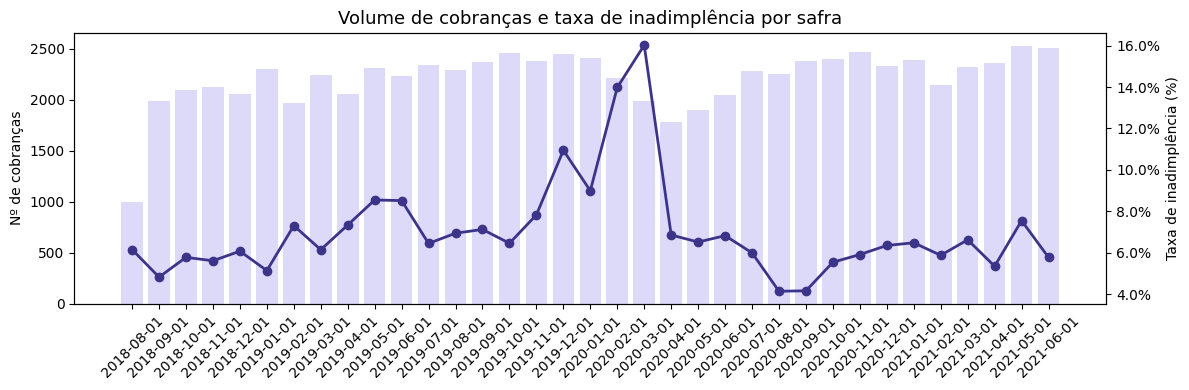

### 📊 Detalhamento por Safra

,SAFRA_REF,taxa_inad,n_cobr
0,2018-08-01 00:00:00,6.15%,992
1,2018-09-01 00:00:00,4.82%,"1,992"
2,2018-10-01 00:00:00,5.77%,"2,096"
3,2018-11-01 00:00:00,5.61%,"2,122"
4,2018-12-01 00:00:00,6.07%,"2,059"
5,2019-01-01 00:00:00,5.13%,"2,299"
6,2019-02-01 00:00:00,7.31%,"1,971"
7,2019-03-01 00:00:00,6.14%,"2,247"
8,2019-04-01 00:00:00,7.34%,"2,058"
9,2019-05-01 00:00:00,8.55%,"2,317"


In [ ]:
from IPython.display import display, Markdown

# 4 - Target por safra
taxa_por_safra = (
    dev.groupby("SAFRA_REF")["TARGET"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "taxa_inad", "count": "n_cobr"})
    .reset_index()
)

# ===== GRÁFICO =====
fig, ax1 = plt.subplots(figsize=(12, 4))

# Barras (volume)
ax1.bar(
    taxa_por_safra["SAFRA_REF"].astype(str),
    taxa_por_safra["n_cobr"],
    color="#CECBF6",
    alpha=0.7
)
ax1.set_ylabel("Nº de cobranças")
ax1.tick_params(axis="x", rotation=45)

# Linha (taxa inadimplência)
ax2 = ax1.twinx()
ax2.plot(
    taxa_por_safra["SAFRA_REF"].astype(str),
    taxa_por_safra["taxa_inad"] * 100,
    color="#3C3489",
    marker="o",
    linewidth=2
)
ax2.set_ylabel("Taxa de inadimplência (%)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))

# Título
ax1.set_title("Volume de cobranças e taxa de inadimplência por safra", fontsize=13)

plt.tight_layout()

plt.show()

display(Markdown("### 📊 Detalhamento por Safra"))

# ===== TABELA =====
display(
    taxa_por_safra.style
    .format({
        "taxa_inad": "{:.2%}",
        "n_cobr": "{:,}"
    })
    .set_caption("Tabela: Taxa de inadimplência por safra")
)

**Volume de cobranças**

A base começa com 992 cobranças em agosto/2018 e estabiliza em torno de 2.000 a 2.500 por mês a partir de setembro/2018. Esse primeiro mês com volume pela metade provavelmente representa uma entrada parcial de dados, vale ter isso em mente na hora de definir o split, pois safras com volume anormal podem distorcer as métricas.

**O pico de fevereiro e março/2020**

Esse é o insight mais importante do gráfico. A taxa de inadimplência sobe de 6-8% para 14% em fevereiro e atinge 16% em março/2020 isso coincide exatamente com o período de início da pandemia de COVID-19. É um choque externo claro e abrupto no comportamento de pagamento. Logo depois, em abril/2020, a taxa cai bruscamente para 6.8% e segue em queda até agosto/2020, chegando ao menor patamar histórico de 4.1%.
Essa queda pós-pico provavelmente reflete medidas de renegociação, carência ou auxílios emergenciais que reduziram temporariamente a inadimplência. Esse padrão é um sinal de que o comportamento dos clientes é sensível a fatores macroeconômicos externos, algo que o modelo não consegue capturar diretamente mas que eu acho importante mencionar como limitação.

**Implicação direta para o time-based split**

O período de fevereiro e março/2020 é atípico e se cair inteiro no conjunto de validação, as métricas vão refletir um comportamento de crise que não representa o padrão normal. O ideal é que o split coloque essas safras no treino, deixando para validação os meses de 2021, que já mostram comportamento normalizado entre 5% e 7%. Minha Sugestão seria: treino até dezembro/2020, validação de janeiro a junho/2021.

**Padrão sazonal**

Olhando fora do período de crise, dezembro tende a ter taxas ligeiramente mais altas (11% em 2019, 6.3% em 2020). Isso pode ser um padrão sazonal, o fim de ano com mais pressão financeira sobre as empresas. Valeria criar até uma feature de mês do vencimento para o modelo capturar isso.


## **Conclusão**

A inspeção inicial revelou que as bases estão bem estruturadas e se relacionam corretamente pelas
chaves ID_CLIENTE e SAFRA_REF. O separador das bases é ponto e vírgula, não vírgula que foi um detalhe
técnico que precisou ser corrigido no carregamento. A base de desenvolvimento cobre agosto/2018 a
junho/2021, enquanto a base de teste representa os 5 meses seguintes (julho a novembro/2021),
garantindo que o modelo sempre prediz o futuro a partir do passado.

Identificamos 88 clientes no teste sem histórico de pagamentos, sendo 21 deles também sem cadastro.
Para esse grupo, o modelo dependerá exclusivamente das informações da cobrança e da base_info.

O target foi construído sem ambiguidades: nenhum valor nulo em DATA_PAGAMENTO, regra dos 5 dias
aplicada diretamente. A taxa de inadimplência é de 7%, desbalanceamento grande que orienta a
escolha de AUC-ROC como métrica principal. A análise temporal revelou um pico expressivo em
fevereiro e março/2020, coincidindo com o início da pandemia, seguido de queda abrupta, padrão
que reforça a necessidade de um split temporal criterioso e que será considerado na modelagem.

Por fim, a coluna DIAS_ATRASO não será utilizada como feature direta pois ela depende de
DATA_PAGAMENTO e é uma informação que não existe na base de teste, já que os pagamentos ainda não
ocorreram. Usá-la seria uma forma de vazamento de dados (data leakage). No entanto, ela é a
matéria-prima mais valiosa do feature engineering: a partir dos pagamentos históricos já realizados,
vamos calcular agregações por cliente como média de dias de atraso, maior atraso já registrado e
número de vezes que atrasou 5 dias ou mais. Essas features são legítimas porque representam
comportamento passado que é uma informação que de fato existe no momento em que o modelo precisa fazer
a previsão.

In [ ]:
dev.head(10)

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA,DIAS_ATRASO,TARGET
0,1661240395903230676,2018-08-01,2018-08-17,2018-09-06,2018-09-06,35516.41,6.99,0,0
1,1661240395903230676,2018-08-01,2018-08-19,2018-09-11,2018-09-10,17758.21,6.99,1,0
2,1661240395903230676,2018-08-01,2018-08-26,2018-09-18,2018-09-17,17431.96,6.99,1,0
3,1661240395903230676,2018-08-01,2018-08-30,2018-10-11,2018-10-05,1341.00,6.99,6,1
4,1661240395903230676,2018-08-01,2018-08-31,2018-09-20,2018-09-20,21309.85,6.99,0,0
5,8274986328479596038,2018-08-01,2018-08-17,2018-09-25,2018-09-25,48811.35,6.99,0,0
6,345447888460137901,2018-08-01,2018-08-17,2018-09-05,2018-09-05,55131.20,5.99,0,0
7,1003144834589372198,2018-08-01,2018-08-17,2018-09-03,2018-09-03,85855.04,6.99,0,0
8,324916756972236008,2018-08-01,2018-08-17,2018-09-03,2018-09-03,42072.00,5.99,0,0
9,324916756972236008,2018-08-01,2018-08-19,2018-09-05,2018-09-05,21071.97,5.99,0,0


In [ ]:
# Salvar base com target
dev.to_csv("dev_com_target.csv", index=False)
print("\nArquivo dev_com_target.csv salvo.")


Arquivo dev_com_target.csv salvo.


## **Análise Exploratória de Dados (EDA)**

**Eu  dividi essa EDA em 6 blocos temáticos:**

**Bloco 1** - Diagnóstico de Qualidade dos Dados - junção das tabelas e remoção de duplicatas, verificando e entendendo valores nulos e outliers para possível tratamento

**Bloco 2** — Variáveis numéricas: Como se distribuem VALOR_A_PAGAR, TAXA, RENDA_MES_ANTERIOR e NO_FUNCIONARIOS?

**Bloco 3** — Variáveis categóricas vs target: PORTE, SEGMENTO_INDUSTRIAL, FLAG_PF, CEP_2_DIG e DDD discriminam inadimplência? Quais categorias têm maior risco?

**Bloco 4** — Comportamento temporal: Já vimos a taxa por safra. Agora aprofundamos: há sazonalidade mensal? O comportamento de clientes novos difere dos antigos?

**Bloco 5** - Comportamento dos clientes indica possível inadimplência? Análise de comportamento vs TARGET

**Bloco 6** — Correlações e sinais para feature engineering: Quais variáveis se relacionam com o target? O valor da cobrança relativo à renda tem poder preditivo?

In [ ]:
# ============================================================
# Análise Exploratória de Dados (EDA) e tratamento de dados
# ============================================================
# Objetivo: entender a estrutura dos dados, identificar
# padrões de inadimplência e documentar todas as decisões
# de tratamento antes do feature engineering.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

RANDOM_STATE = 42

In [ ]:
# 1.1 — Carregamento

# Leitura dos dados
dev = pd.read_csv("dev_com_target.csv", sep=",")

cadastral = pd.read_csv("base_cadastral.csv", sep=";")

info = pd.read_csv("base_info.csv", sep=";")

teste = pd.read_csv("base_pagamentos_teste.csv", sep=";")

# Verificar dimensão das bases
for nome, base in [("dev", dev), ("cadastral", cadastral),
                   ("info", info), ("teste", teste)]:
    print(f"[{nome}] {base.shape}")

[dev] (77414, 9)
[cadastral] (1315, 8)
[info] (24401, 4)
[teste] (12275, 6)


In [ ]:
teste.head()

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,5058298901476893676,2021-07,2021-07-14,2021-08-04,11204.7500,4.9900
1,274692171162531764,2021-07,2021-07-08,2021-08-23,60718.5000,5.9900
2,274692171162531764,2021-07,2021-07-11,2021-08-25,60718.5000,5.9900
3,274692171162531764,2021-07,2021-07-16,2021-08-30,62250.0000,5.9900
4,465309249432033993,2021-07,2021-07-05,2021-07-30,26593.9500,6.9900


In [ ]:
teste.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12275 entries, 0 to 12274
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_CLIENTE              12275 non-null  int64  
 1   SAFRA_REF               12275 non-null  object 
 2   DATA_EMISSAO_DOCUMENTO  12275 non-null  object 
 3   DATA_VENCIMENTO         12275 non-null  object 
 4   VALOR_A_PAGAR           12144 non-null  float64
 5   TAXA                    12275 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 575.5+ KB


In [ ]:
teste.isnull().sum()

,0
ID_CLIENTE,0
SAFRA_REF,0
DATA_EMISSAO_DOCUMENTO,0
DATA_VENCIMENTO,0
VALOR_A_PAGAR,131
TAXA,0


In [ ]:
# ============================================================
# 1.2 — Padronização de chaves para JOIN
# Garante que merges funcionem sem erro de tipo/formato.
# Essencial para evitar perda de linhas e inconsistências.
# ============================================================

# ID_CLIENTE como string (evita erro int vs object)
for base in [dev, cadastral, info, teste]:
    base["ID_CLIENTE"] = base["ID_CLIENTE"].astype(str)

# SAFRA_REF padronizada (mesmo formato em TODAS as bases)
for base in [dev, info, teste]:
    base["SAFRA_REF"] = pd.to_datetime(
        base["SAFRA_REF"], errors="coerce"
    ).dt.strftime("%Y-%m-%d")

# Conferência rápida (debug crítico)
print("dev:",   dev["SAFRA_REF"].iloc[0],   type(dev["SAFRA_REF"].iloc[0]))
print("info:",  info["SAFRA_REF"].iloc[0],  type(info["SAFRA_REF"].iloc[0]))
print("teste:", teste["SAFRA_REF"].iloc[0], type(teste["SAFRA_REF"].iloc[0]))

# Merge
df = dev.merge(cadastral, on="ID_CLIENTE", how="left")
df = df.merge(info,       on=["ID_CLIENTE", "SAFRA_REF"], how="left")

# TARGET como última coluna
cols = [c for c in df.columns if c != "TARGET"] + ["TARGET"]
df   = df[cols]

print(f"\nTabela analítica: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print(f"Nulos RENDA_MES_ANTERIOR: {df['RENDA_MES_ANTERIOR'].isna().sum():,}")
print(f"Nulos NO_FUNCIONARIOS:    {df['NO_FUNCIONARIOS'].isna().sum():,}")

dev: 2018-08-01 <class 'str'>
info: 2018-09-01 <class 'str'>
teste: 2021-07-01 <class 'str'>

Tabela analítica: 77,414 linhas x 18 colunas
Nulos RENDA_MES_ANTERIOR: 6,132
Nulos NO_FUNCIONARIOS:    7,587


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77414 entries, 0 to 77413
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_CLIENTE              77414 non-null  object 
 1   SAFRA_REF               77414 non-null  object 
 2   DATA_EMISSAO_DOCUMENTO  77414 non-null  object 
 3   DATA_PAGAMENTO          77414 non-null  object 
 4   DATA_VENCIMENTO         77414 non-null  object 
 5   VALOR_A_PAGAR           76244 non-null  float64
 6   TAXA                    77414 non-null  float64
 7   DIAS_ATRASO             77414 non-null  int64  
 8   DATA_CADASTRO           77414 non-null  object 
 9   DDD                     70000 non-null  object 
 10  FLAG_PF                 219 non-null    object 
 11  SEGMENTO_INDUSTRIAL     75997 non-null  object 
 12  DOMINIO_EMAIL           76516 non-null  object 
 13  PORTE                   74938 non-null  object 
 14  CEP_2_DIG               77414 non-null

In [ ]:
# Converte as datas em tipo correto "datetime"
cols_datas = [
    "SAFRA_REF",
    "DATA_EMISSAO_DOCUMENTO",
    "DATA_PAGAMENTO",
    "DATA_VENCIMENTO",
    "DATA_CADASTRO"
]

for col in cols_datas:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77414 entries, 0 to 77413
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ID_CLIENTE              77414 non-null  object        
 1   SAFRA_REF               77414 non-null  datetime64[ns]
 2   DATA_EMISSAO_DOCUMENTO  77414 non-null  datetime64[ns]
 3   DATA_PAGAMENTO          77414 non-null  datetime64[ns]
 4   DATA_VENCIMENTO         77414 non-null  datetime64[ns]
 5   VALOR_A_PAGAR           76244 non-null  float64       
 6   TAXA                    77414 non-null  float64       
 7   DIAS_ATRASO             77414 non-null  int64         
 8   DATA_CADASTRO           77414 non-null  datetime64[ns]
 9   DDD                     70000 non-null  object        
 10  FLAG_PF                 219 non-null    object        
 11  SEGMENTO_INDUSTRIAL     75997 non-null  object        
 12  DOMINIO_EMAIL           76516 non-null  object

In [ ]:
df.isnull().sum()

,0
ID_CLIENTE,0
SAFRA_REF,0
DATA_EMISSAO_DOCUMENTO,0
DATA_PAGAMENTO,0
DATA_VENCIMENTO,0
VALOR_A_PAGAR,1170
TAXA,0
DIAS_ATRASO,0
DATA_CADASTRO,0
DDD,7414


In [ ]:
# 1.3 — Consistência das chaves
# Verificar cobertura entre bases e clientes novos no teste

# Criar conjuntos únicos
ids_dev   = set(dev["ID_CLIENTE"])
ids_teste = set(teste["ID_CLIENTE"])
ids_cad   = set(cadastral["ID_CLIENTE"])

# Análises
novos         = ids_teste - ids_dev
sem_cadastro  = ids_teste - ids_cad
novos_sem_cad = novos & sem_cadastro

# Prints
print(f"Clientes únicos — dev:       {len(ids_dev):,}")
print(f"Clientes únicos — teste:     {len(ids_teste):,}")
print(f"Clientes únicos — cadastral: {len(ids_cad):,}")

print(f"\nClientes no teste sem histórico: "
      f"{len(novos):,} ({len(novos)/len(ids_teste)*100:.1f}%)")

print(f"Clientes no teste sem cadastro:  {len(sem_cadastro):,}")

print(f"Sem histórico E sem cadastro:    {len(novos_sem_cad):,}")

print(f"\nCobertura do cadastral no dev: "
      f"{len(ids_dev & ids_cad)/len(ids_dev)*100:.1f}%")

Clientes únicos — dev:       1,248
Clientes únicos — teste:     976
Clientes únicos — cadastral: 1,315

Clientes no teste sem histórico: 88 (9.0%)
Clientes no teste sem cadastro:  21
Sem histórico E sem cadastro:    21

Cobertura do cadastral no dev: 100.0%


Cobertura 100% do cadastral no dev. Todos os 1.248 clientes que aparecem no histórico têm cadastro. Os 1.315 do cadastral são maiores porque incluem clientes que ainda não geraram cobranças no período analisado.
88 clientes novos no teste (9%) e sem nenhuma cobrança anterior no dev. Para esses, todas as features de histórico virão nulas.
21 sem histórico e sem cadastro — subconjunto dos 88. São clientes completamente novos no sistema, sem nenhuma informação prévia além da base_info e da própria cobrança.

In [ ]:
# Verificando duplicatas
df.duplicated().sum()

np.int64(1)

In [ ]:
# Identificar a duplicata antes de remover
duplicata = df[df.duplicated(keep=False)]
print(duplicata[["ID_CLIENTE", "SAFRA_REF", "VALOR_A_PAGAR",
                 "DATA_VENCIMENTO", "TARGET"]].to_string())

                ID_CLIENTE  SAFRA_REF  VALOR_A_PAGAR DATA_VENCIMENTO  TARGET
32322  3218226066162129945 2019-11-01            NaN      2019-11-25       0
32323  3218226066162129945 2019-11-01            NaN      2019-11-25       0


É uma duplicata verdadeira - mesmo cliente, mesma safra, mesmo vencimento, mesmo target e ambas com VALOR_A_PAGAR nulo. É um erro de sistema, vou remover

In [ ]:
# Remover duplicata
df = df.drop_duplicates()

print(f"Shape após remoção: {df.shape}")
print(f"Duplicatas restantes: {df.duplicated().sum()}")



Shape após remoção: (77413, 18)
Duplicatas restantes: 0


In [ ]:
# Bloco 1.4 — Diagnóstico de nulos
# Três perguntas por coluna:
#   1. Qual a proporção de nulos?
#   2. O nulo tem padrão?
#   3. O nulo está relacionado ao target?

# 0.4.1 — Mapa geral de nulos
print("── Mapa de nulos — tabela analítica ─────────────────────")
nulos = pd.DataFrame({
    "nulos":   df.isnull().sum(),
    "pct_%":   (df.isnull().mean() * 100).round(2)
})
nulos = nulos[nulos["nulos"] > 0].sort_values("pct_%", ascending=False)
print(nulos.to_string())

── Mapa de nulos — tabela analítica ─────────────────────
                     nulos   pct_%
FLAG_PF              77194 99.7200
NO_FUNCIONARIOS       7587  9.8000
DDD                   7413  9.5800
RENDA_MES_ANTERIOR    6132  7.9200
PORTE                 2476  3.2000
SEGMENTO_INDUSTRIAL   1417  1.8300
VALOR_A_PAGAR         1169  1.5100
DOMINIO_EMAIL          898  1.1600


In [ ]:
# 1.4.2 — Nulos vs TARGET
# Se a taxa de inadimplência for diferente entre nulo e
# preenchido, o nulo carrega sinal preditivo então seria melhor criar flag

# Lista de colunas a serem analisadas
colunas_verificar = [
    "FLAG_PF", "NO_FUNCIONARIOS", "DDD",
    "RENDA_MES_ANTERIOR", "PORTE", "SEGMENTO_INDUSTRIAL",
    "VALOR_A_PAGAR", "DOMINIO_EMAIL"
]

resultados = []  # Armazena resultados por variável

# Loop sobre cada coluna
for col in colunas_verificar:

    flag = df[col].isna()  # Identifica registros com valor nulo

    # Calcula taxa de inadimplência para nulos e preenchidos
    taxa_nulo = df[flag]["TARGET"].mean()
    taxa_pree = df[~flag]["TARGET"].mean()

    # Contagem de registros
    n_nulo = flag.sum()
    n_pree = (~flag).sum()

    # Diferença absoluta entre as taxas
    diff = abs(taxa_nulo - taxa_pree) if pd.notna(taxa_nulo) else 0

    # Armazena métricas
    resultados.append({
        "coluna":       col,
        "n_nulo":       n_nulo,
        "pct_nulo_%":   round(n_nulo / len(df) * 100, 2),
        "taxa_nulo":    round(taxa_nulo, 4) if pd.notna(taxa_nulo) else None,
        "taxa_pree":    round(taxa_pree, 4),
        "diff_abs":     round(diff, 4),
        "informativo":  "SIM" if diff > 0.01 else "NÃO"  # threshold de relevância
    })

# Cria DataFrame final ordenado por % de nulos
res_df = pd.DataFrame(resultados).sort_values("pct_nulo_%",
                                               ascending=False)

# Exibe resultados
print("\n── Nulos vs TARGET ──────────────────────────────────────")
print(res_df.to_string(index=False))


── Nulos vs TARGET ──────────────────────────────────────
             coluna  n_nulo  pct_nulo_%  taxa_nulo  taxa_pree  diff_abs informativo
            FLAG_PF   77194     99.7200     0.0698     0.2009    0.1311         SIM
    NO_FUNCIONARIOS    7587      9.8000     0.0820     0.0689    0.0130         SIM
                DDD    7413      9.5800     0.0801     0.0692    0.0110         SIM
 RENDA_MES_ANTERIOR    6132      7.9200     0.0757     0.0698    0.0059         NÃO
              PORTE    2476      3.2000     0.1749     0.0668    0.1081         SIM
SEGMENTO_INDUSTRIAL    1417      1.8300     0.0734     0.0702    0.0032         NÃO
      VALOR_A_PAGAR    1169      1.5100     0.0941     0.0699    0.0242         SIM
      DOMINIO_EMAIL     898      1.1600     0.0590     0.0704    0.0113         SIM


**O que o diff_abs representa**

É a diferença absoluta entre a taxa de inadimplência do grupo nulo e do grupo preenchido. Um diff de 0.01 significa 1 ponto percentual de diferença, por exemplo, 7.0% vs 8.0%.

**Por que 0.01 como corte?**

A taxa geral de inadimplência é 7%. Um diff de 0.01 representa aproximadamente 14% de variação relativa em torno dessa média, ou seja, o nulo muda o risco do cliente em pelo menos 14% em relação à média. Abaixo disso a diferença é tão pequena que provavelmente é ruído estatístico e não um padrão real.
Mas não é uma regra absoluta, olhando os nossos resultados, DOMINIO_EMAIL tem diff de 0.0113 e passou pelo corte por pouco. Eu decidi não criar flag mesmo assim porque o sinal é invertido e fraco. Já PORTE tem diff de 0.1081 e é muito acima do corte, decisão óbvia.
O corte de 0.01 funciona como um filtro inicial para eliminar os casos claramente sem sinal, mas a decisão final sempre considero o contexto

**FLAG_PF** — diff de 0.1311, maior de todas
Taxa de 20.09% para o valor preenchido ('X' = pessoa física) contra 6.98% para nulo (pessoa jurídica). Pessoas físicas são muito mais inadimplentes que pessoas jurídicas. Essa informação muda completamente a decisão anterior de eliminar a coluna porque ela tem sinal preditivo forte. Vamos manter como binária: 1 = pessoa física, 0 = pessoa jurídica.

**PORTE** — diff de 0.1081, segunda maior
17.49% de inadimplência para clientes sem classificação de porte contra 6.68% para os classificados. Clientes sem porte definido são significativamente mais arriscados, então o nulo aqui é um sinal muito forte. Criar FLAG_PORTE_NULO é essencial.

**VALOR_A_PAGAR** — diff de 0.0242, confirmando o que já vimos: cobranças sem valor têm mais inadimplência. Manter FLAG_VALOR_NULO.

**NO_FUNCIONARIOS** — diff de 0.0130, confirma que empresas que não reportam funcionários são levemente mais inadimplentes. Manter FLAG_FUNC_NULO.

**DDD** — diff de 0.0110, Clientes sem DDD têm inadimplência de 8.01% vs 6.92%. Sinal fraco mas consistente com o padrão de menor formalização que identificamos antes. Manter FLAG_DDD_NULO.

**DOMINIO_EMAIL** — diff de 0.0113, Surpreendente, estva achando que era aleatório mas tem sinal pequeno. Clientes sem email têm taxa ligeiramente menor (5.90% vs 7.04%). Sinal fraco e invertido, sem email indica menos inadimplência. Não criar flag, tratar como categoria DESCONHECIDO.

**RENDA_MES_ANTERIOR** e **SEGMENTO_INDUSTRIAL** - Diffs de 0.0059 e 0.0032 — abaixo do limiar de 0.01. Confirmados como aleatórios. Sem flag binária.

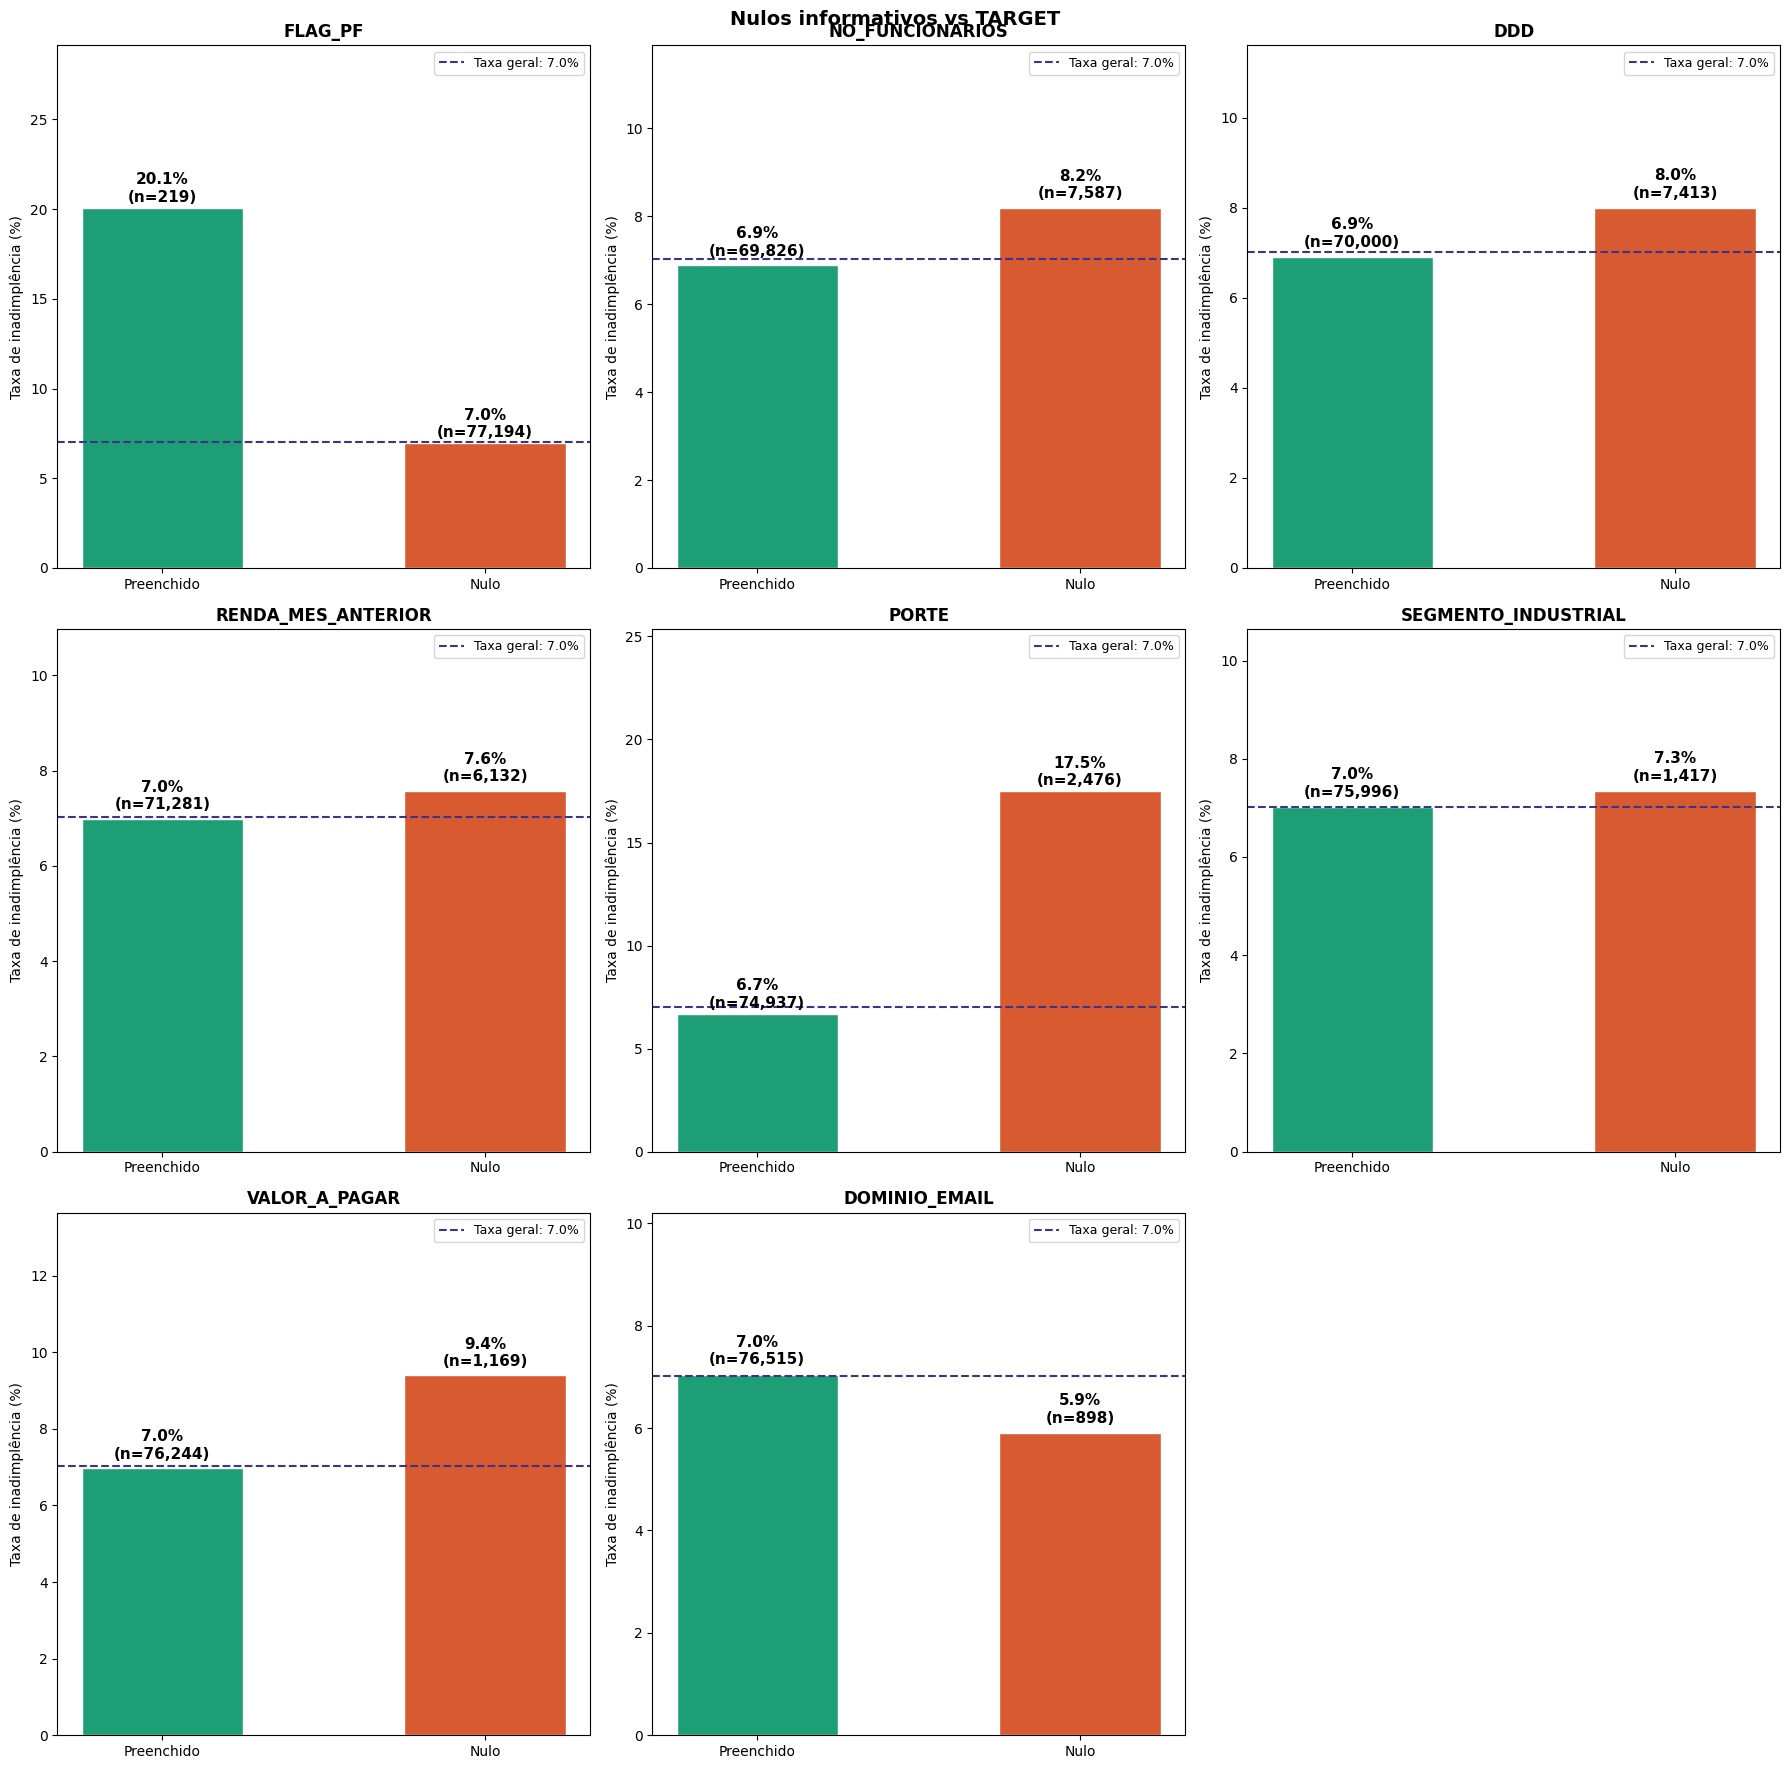

In [ ]:
# 1.4.3 — Visualização: nulos informativos vs target
# Só plota colunas onde o nulo é informativo (diff > 0.01)
# e tem volume suficiente para análise (n_nulo > 100)

# Define quantidade de gráficos e layout (3 colunas por linha)
n_cols = len(res_df)
n_rows = (n_cols + 2) // 3  # garante arredondamento para cima

# Cria a figura com múltiplos subplots
fig, axes = plt.subplots(n_rows, 3,
                         figsize=(18, 6 * n_rows))
axes = axes.flatten()  # facilita iteração

# Calcula taxa geral de inadimplência (baseline)
taxa_geral = df["TARGET"].mean() * 100

# Loop sobre variáveis informativas
for i, (_, row) in enumerate(res_df.iterrows()):
    ax  = axes[i]
    col = row["coluna"]

    # Taxas de inadimplência (preenchido vs nulo)
    taxas = [row["taxa_pree"] * 100, row["taxa_nulo"] * 100]

    # Quantidade de registros em cada grupo
    ns = [int(len(df) - row["n_nulo"]), int(row["n_nulo"])]

    labels = ["Preenchido", "Nulo"]
    cores  = ["#1D9E75", "#D85A30"]

    # Cria gráfico de barras
    bars = ax.bar(labels, taxas, color=cores,
                  edgecolor="white", width=0.5)

    # Adiciona valores e volume em cima das barras
    for bar, v, n in zip(bars, taxas, ns):
        ax.text(bar.get_x() + bar.get_width() / 2,
                v + 0.15, f"{v:.1f}%\n(n={n:,})",
                ha="center", va="bottom",
                fontsize=11, fontweight="bold")

    # Linha de referência com taxa média geral
    ax.axhline(taxa_geral, color="#3C3489",
               linestyle="--", linewidth=1.5,
               label=f"Taxa geral: {taxa_geral:.1f}%")

    # Ajustes visuais
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_ylabel("Taxa de inadimplência (%)")
    ax.set_ylim(0, max(taxas) * 1.45)
    ax.legend(fontsize=9)

# Esconde eixos vazios (caso não complete múltiplos de 3)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Título geral
plt.suptitle("Nulos informativos vs TARGET",
             fontsize=14, fontweight="bold")

# Ajuste de layout
plt.tight_layout()

# Exibe gráficos
plt.show()

**FLAG_PF** — sinal mais forte de todos

20.1% de inadimplência para pessoas físicas contra 7.0% para pessoas jurídicas é quase 3x mais risco. É o sinal mais poderoso encontrado até agora. A decisão de manter essa coluna como feature binária está completamente justificada por esse gráfico.

**NO_FUNCIONARIOS**

8.2% para nulos contra 6.9% para preenchidos. Empresas que não reportam funcionários são ligeiramente mais arriscadas. Sinal moderado mas consistente, criar FLAG_FUNC_NULO vai capturar isso.

**DDD**

8.0% para nulos contra 6.9% para preenchidos. Clientes sem telefone cadastrado têm perfil de menor formalização e maior risco. Sinal similar ao de NO_FUNCIONARIOS, criar FLAG_DDD_NULO.

**PORTE**

O segundo sinal mais forte. 17.5% para nulos contra 6.7% para preenchidos — clientes sem classificação de porte têm risco 2.6x maior que a média. Esse é um insight de negócio muito relevante: empresas não classificadas representam um grupo de alto risco que o modelo precisa identificar. Criar FLAG_PORTE_NULO obrigatoriamente.

**VALOR_A_PAGAR**

9.4% para nulos contra 7.0% para preenchidos. Cobranças sem valor registrado têm risco 34% maior. Criar FLAG_VALOR_NULO.

**DOMINIO_EMAIL**

Único caso invertido — 5.9% para nulos contra 7.0% para preenchidos. Clientes sem email são ligeiramente menos inadimplentes, o que é contraintuitivo. Pode indicar que clientes sem email são grandes empresas com relacionamento mais antigo. Sinal fraco e invertido, não criar flag, tratar como categoria DESCONHECIDO conforme decidido.

In [ ]:
# 1.5 — Diagnóstico de outliers
# Método IQR fator 3 — conservador para dados financeiros
# Não removemos outliers: podem ser clientes reais

# Função para diagnóstico de outliers usando método IQR (robusto para dados assimétricos)
def diagnostico_outliers(data, colunas, nome):

    # Cabeçalho para organização da saída
    print(f"\n{'='*60}")
    print(f"  OUTLIERS — {nome.upper()}")
    print(f"{'='*60}")

    rows = []  # Lista para armazenar resultados por variável

    # Loop sobre cada coluna analisada
    for col in colunas:
        s = data[col].dropna()  # Remove valores nulos

        # Cálculo dos quartis e intervalo interquartil
        Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
        IQR    = Q3 - Q1

        # Definição dos limites de outliers extremos (IQR * 3)
        lim_inf = Q1 - 3 * IQR
        lim_sup = Q3 + 3 * IQR

        # Contagem de outliers inferiores e superiores
        n_inf = (s < lim_inf).sum()
        n_sup = (s > lim_sup).sum()

        # Armazena métricas calculadas
        rows.append({
            "coluna":    col,
            "Q1":        round(Q1, 2),
            "Q3":        round(Q3, 2),
            "lim_inf":   round(lim_inf, 2),
            "lim_sup":   round(lim_sup, 2),
            "n_inf":     n_inf,
            "pct_inf_%": round(n_inf / len(s) * 100, 2),
            "n_sup":     n_sup,
            "pct_sup_%": round(n_sup / len(s) * 100, 2),
        })

    # Exibe resultados em formato tabular
    print(pd.DataFrame(rows).to_string(index=False))

# Analisar outliers apenas nas bases que fazem sentido
# separadamente — tabela analítica (fonte única de verdade)
# e teste (para verificar consistência com o treino)

colunas_num = ["VALOR_A_PAGAR", "TAXA",
               "RENDA_MES_ANTERIOR", "NO_FUNCIONARIOS"]

diagnostico_outliers(df,    colunas_num, "tabela analítica")
diagnostico_outliers(teste, ["VALOR_A_PAGAR", "TAXA"], "teste")


  OUTLIERS — TABELA ANALÍTICA
            coluna          Q1          Q3      lim_inf      lim_sup  n_inf  pct_inf_%  n_sup  pct_sup_%
     VALOR_A_PAGAR  18765.3600  60933.8400 -107740.0600  187439.2600      0     0.0000    815     1.0700
              TAXA      5.9900      6.9900       2.9900       9.9900      0     0.0000   5297     6.8400
RENDA_MES_ANTERIOR 134054.0000 396250.0000 -652534.0000 1182838.0000      0     0.0000    182     0.2600
   NO_FUNCIONARIOS    105.0000    130.0000      30.0000     205.0000    147     0.2100      0     0.0000

  OUTLIERS — TESTE
       coluna         Q1         Q3      lim_inf     lim_sup  n_inf  pct_inf_%  n_sup  pct_sup_%
VALOR_A_PAGAR 26712.3400 87029.3600 -154238.7500 267980.4400      0     0.0000    110     0.9100
         TAXA     5.9900     6.9900       2.9900      9.9900      0     0.0000    866     7.0500


**Tabela analítica** vs **teste — VALOR_A_PAGAR**

Q1 do teste (26k) é maior que o do dev (18k) e Q3 do teste (87k) também maior que o dev (60k). O teste tem cobranças maiores em geral, o limite superior calculado no teste (267k) é mais alto que o do dev (187k). O clip deve ser calculado no treino e aplicado consistentemente no teste, sem recalcular.

**TAXA — idêntica entre treino e teste**

Q1, Q3 e limite superior exatamente iguais nos dois conjuntos. Distribuição estável ao longo do tempo.

**RENDA_MES_ANTERIOR**

Números ligeiramente diferentes da análise anterior porque agora estamos usando a tabela analítica completa. 182 outliers superiores (0.26%) — proporção mínima. Decisão de clip no p99 confirmada.

**NO_FUNCIONARIOS**

147 outliers inferiores (0.21%) — empresas com menos de 30 funcionários. Sem outliers superiores. Decisão de não aplicar clip inferior confirmada.


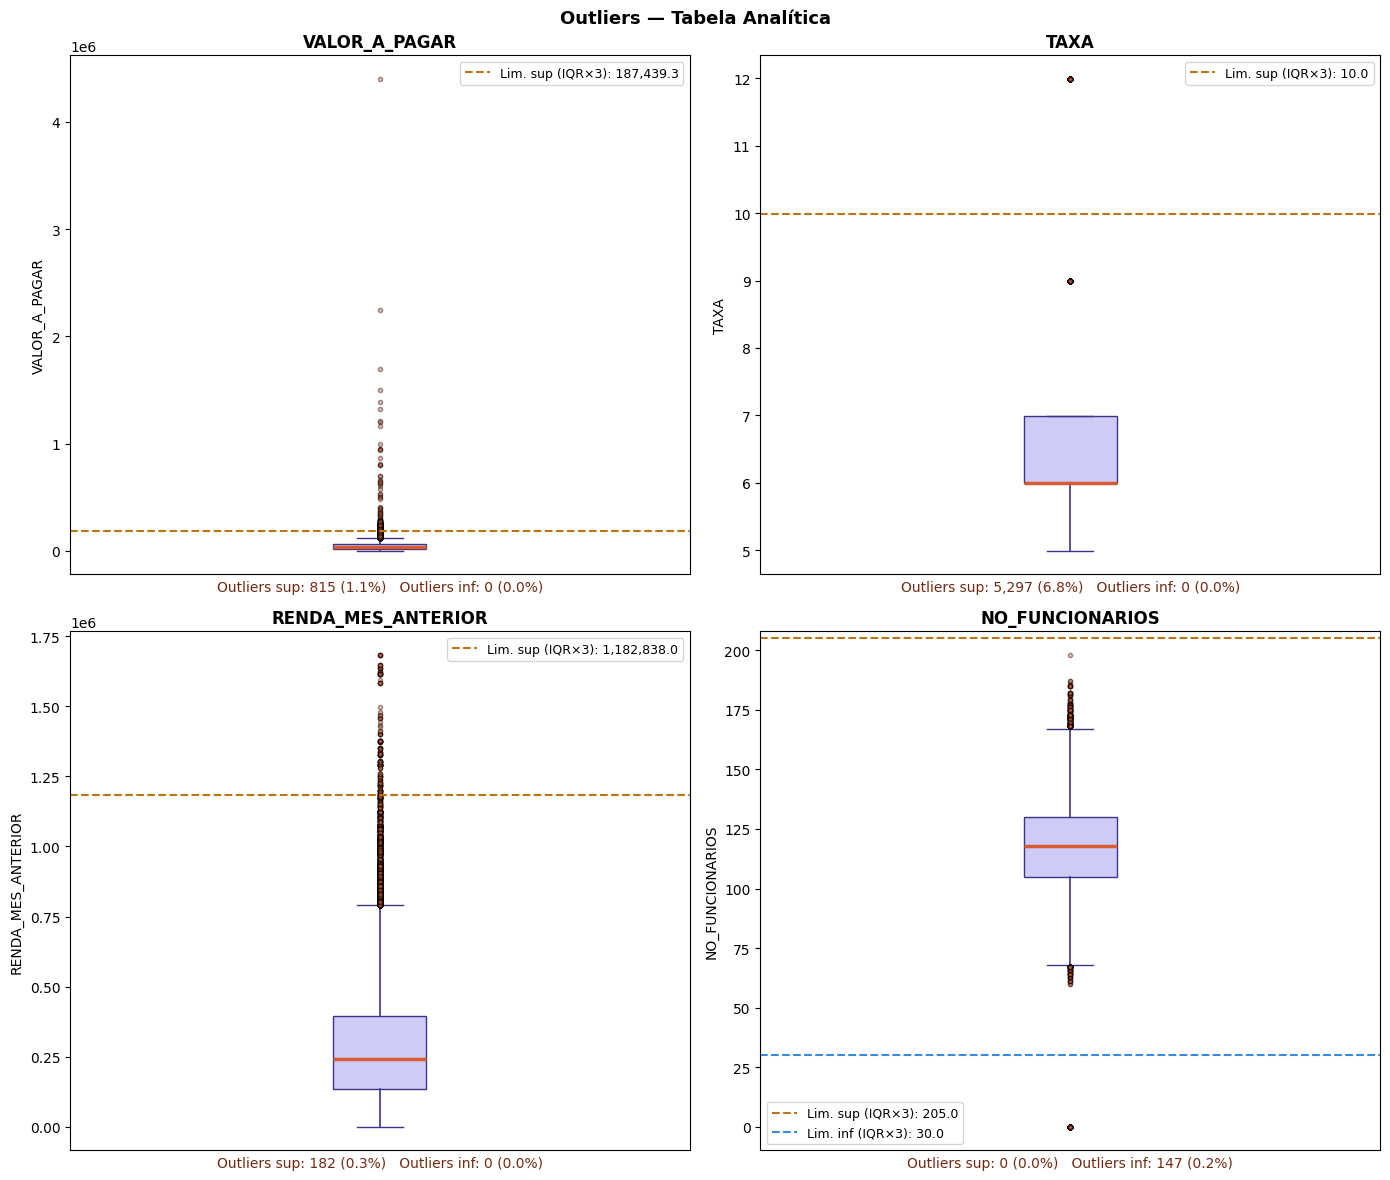

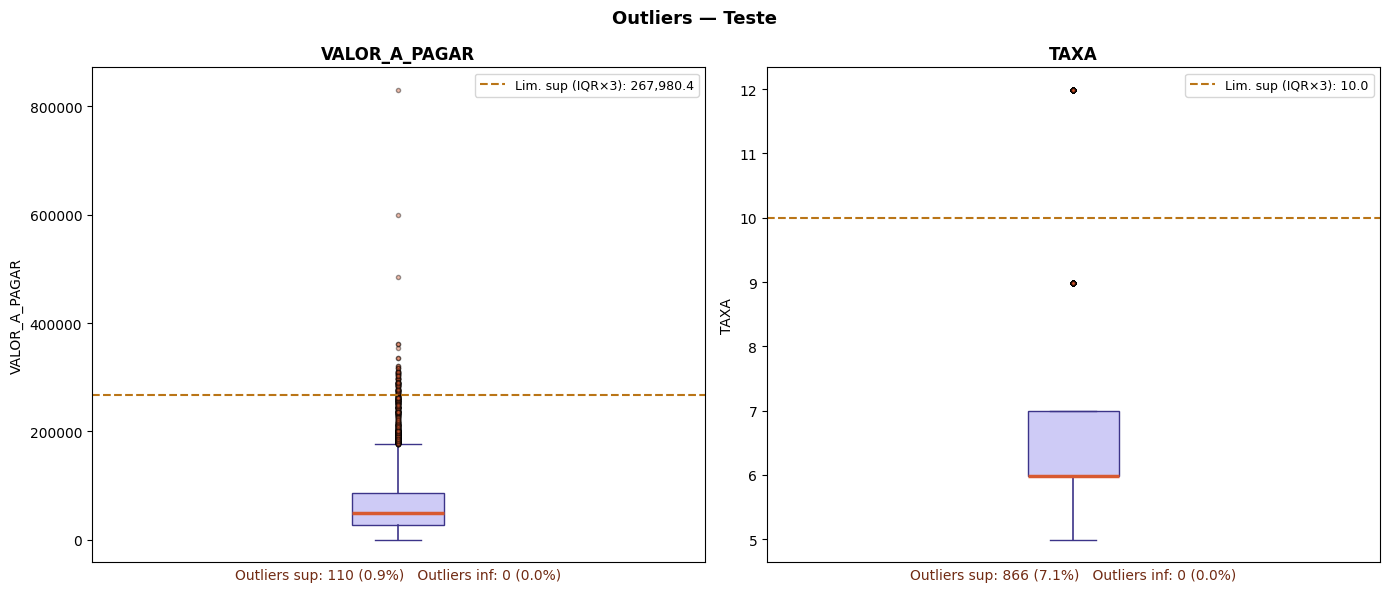

In [ ]:
# Boxplot de outliers
# Uma linha por base, uma coluna por variável
# Linha tracejada marca o limite IQR x3
# Contagem de outliers no rodapé de cada gráfico

# Configuração das bases e colunas a serem analisadas
config = [
    (df,    colunas_num,              "Tabela Analítica"),
    (teste, ["VALOR_A_PAGAR", "TAXA"], "Teste"),
]

# Loop sobre cada base configurada
for data, colunas, titulo in config:
    n     = len(colunas)   # número de variáveis
    ncols = 2              # número fixo de colunas no grid
    nrows = (n + 1) // 2   # número de linhas necessárias

    # Criação dos subplots
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(14, 6 * nrows))
    axes = axes.flatten()

    # Loop sobre cada variável
    for i, col in enumerate(colunas):
        ax = axes[i]
        s  = data[col].dropna()  # remove nulos

        # Cálculo IQR
        Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
        IQR    = Q3 - Q1

        # Limites de outliers extremos
        lim_inf = Q1 - 3 * IQR
        lim_sup = Q3 + 3 * IQR

        # Contagem de outliers
        n_sup   = (s > lim_sup).sum()
        n_inf   = (s < lim_inf).sum()
        pct_sup = n_sup / len(s) * 100
        pct_inf = n_inf / len(s) * 100

        # Criação do boxplot com customização visual
        ax.boxplot(s, vert=True, patch_artist=True,
                   boxprops=dict(facecolor="#CECBF6",
                                 color="#3C3489"),
                   medianprops=dict(color="#D85A30",
                                    linewidth=2.5),
                   whiskerprops=dict(color="#3C3489",
                                     linewidth=1.2),
                   capprops=dict(color="#3C3489"),
                   flierprops=dict(marker="o",
                                   markerfacecolor="#D85A30",
                                   markersize=3,
                                   alpha=0.4))

        # Linha do limite superior
        ax.axhline(lim_sup, color="#BA7517", linestyle="--",
                   linewidth=1.5,
                   label=f"Lim. sup (IQR×3): {lim_sup:,.1f}")

        # Linha do limite inferior (se houver outliers inferiores)
        if n_inf > 0:
            ax.axhline(lim_inf, color="#378ADD",
                       linestyle="--", linewidth=1.5,
                       label=f"Lim. inf (IQR×3): {lim_inf:,.1f}")

        # Ajustes visuais
        ax.set_title(col, fontsize=12, fontweight="bold")
        ax.set_ylabel(col)
        ax.set_xticks([])
        ax.legend(fontsize=9)

        # Exibe quantidade e percentual de outliers
        ax.set_xlabel(
            f"Outliers sup: {n_sup:,} ({pct_sup:.1f}%)   "
            f"Outliers inf: {n_inf:,} ({pct_inf:.1f}%)",
            fontsize=10, color="#712B13"
        )

    # Esconde eixos extras caso número de gráficos seja ímpar
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    # Título geral da figura
    fig.suptitle(f"Outliers — {titulo}",
                 fontsize=13, fontweight="bold")

    # Ajuste de layout
    plt.tight_layout()

    # (nome_arquivo foi preparado mas não utilizado para salvar)
    nome_arquivo = titulo.lower().replace(" ", "_")

    # Exibe os gráficos
    plt.show()

Esses gráficos mostram de maneira visual os outliers

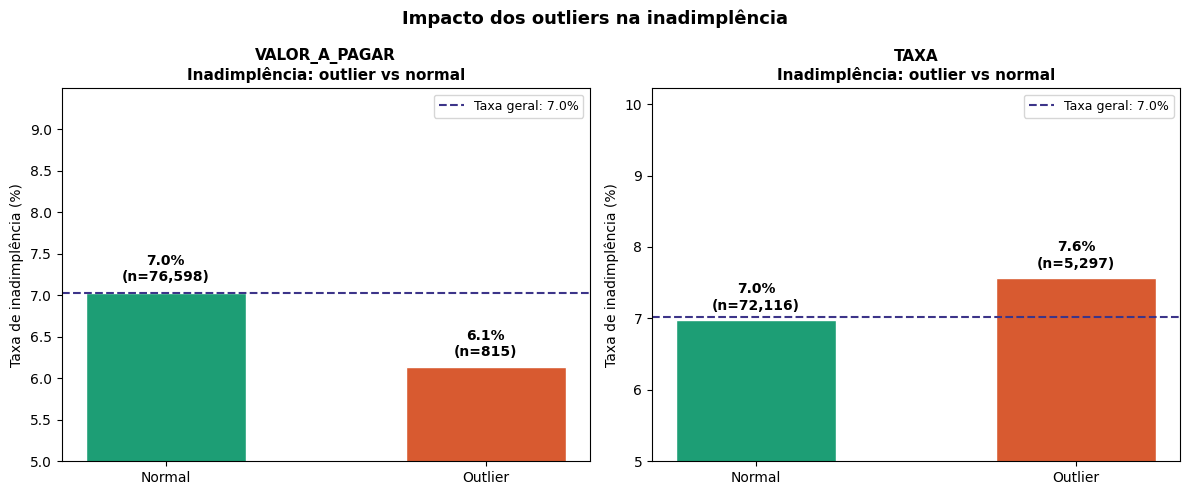

In [ ]:
# 1.6 — Outliers vs TARGET
# Se outliers tiverem taxa de inad. diferente da média isso é
# sinal preditivo, então não aplicar clip agressivo nessa coluna

# Cria figura com 2 gráficos (um por variável)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Taxa média geral de inadimplência (baseline)
taxa_geral = df["TARGET"].mean() * 100

# Loop sobre variáveis de interesse
for ax, col in zip(axes, ["VALOR_A_PAGAR", "TAXA"]):

    s = df[col].dropna()  # remove nulos

    # Cálculo do limite de outlier (IQR * 3)
    Q1, Q3  = s.quantile(0.25), s.quantile(0.75)
    lim_sup = Q3 + 3 * (Q3 - Q1)

    # Cria flag temporária de outlier (1 = outlier)
    df["_flag"] = (df[col] > lim_sup).astype(int)

    # Calcula taxa de inadimplência por grupo
    taxas = df.groupby("_flag")["TARGET"].mean() * 100

    # Quantidade de observações por grupo
    ns = df.groupby("_flag")["TARGET"].count()

    # Remove flag (era só para análise)
    df.drop(columns=["_flag"], inplace=True)

    # Cria gráfico de barras
    bars = ax.bar(["Normal", "Outlier"], taxas.values,
                  color=["#1D9E75", "#D85A30"],
                  edgecolor="white", width=0.5)

    # Adiciona valores e volume nas barras
    for bar, v, n in zip(bars, taxas.values, ns.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                v + 0.1, f"{v:.1f}%\n(n={n:,})",
                ha="center", va="bottom",
                fontsize=10, fontweight="bold")

    # Linha da taxa média geral
    ax.axhline(taxa_geral, color="#3C3489", linestyle="--",
               linewidth=1.5, label=f"Taxa geral: {taxa_geral:.1f}%")

    # Ajustes visuais
    ax.set_title(f"{col}\nInadimplência: outlier vs normal",
                 fontsize=11, fontweight="bold")
    ax.set_ylabel("Taxa de inadimplência (%)")
    ax.set_ylim(5, max(taxas.values) * 1.35)
    ax.legend(fontsize=9)

# Título geral
plt.suptitle("Impacto dos outliers na inadimplência",
             fontsize=13, fontweight="bold")

# Ajuste de layout
plt.tight_layout()

# Exibe gráfico
plt.show()

**VALOR_A_PAGAR** — outliers pagam melhor
6.1% para outliers contra 7.0% para normais. Grandes cobranças pertencem a empresas maiores e mais organizadas financeiramente. O clip no p99 é aplicado apenas para estabilizar a escala da feature e não para eliminar o sinal, que nesse caso é favorável.

**TAXA** — outliers são mais inadimplentes
7.6% para outliers contra 7.0% para normais. Taxas altas já refletem um cliente classificado como mais arriscado pela instituição e o modelo deve capturar esse sinal diretamente. Sem clip confirmado.



In [ ]:
# 1.7 — Tabela de decisões consolidada
# Registra formalmente cada decisão tomada nos blocos anteriores
# Serve como documentação para o feature engineering

decisoes = pd.DataFrame([
    {"coluna": "FLAG_PF",
     "problema": "99.7% nulos",
     "decisao": "MANTER",
     "motivo": "PF tem 20.1% vs 7.0% PJ — sinal preditivo forte. Binarizar: 1=PF, 0=PJ."},
    {"coluna": "NO_FUNCIONARIOS",
     "problema": "9.8% nulos",
     "decisao": "FLAG + IMPUTAR",
     "motivo": "Nulo informativo (8.3% vs 6.9%). Flag + mediana por PORTE."},
    {"coluna": "DDD",
     "problema": "9.6% nulos",
     "decisao": "FLAG + IMPUTAR",
     "motivo": "Nulo aumenta com menor porte. Flag + moda por PORTE."},
    {"coluna": "RENDA_MES_ANTERIOR",
     "problema": "7.9% nulos",
     "decisao": "IMPUTAR",
     "motivo": "Nulo aleatório (7.0% vs 6.6%). Mediana por PORTE."},
    {"coluna": "PORTE",
     "problema": "3.2% nulos",
     "decisao": "CATEGORIA",
     "motivo": "Sem classificação → categoria 'DESCONHECIDO'."},
    {"coluna": "SEGMENTO_INDUSTRIAL",
     "problema": "1.8% nulos",
     "decisao": "CATEGORIA",
     "motivo": "PF → 'PESSOA_FISICA'. Demais → 'DESCONHECIDO'."},
    {"coluna": "VALOR_A_PAGAR",
     "problema": "1.5% nulos",
     "decisao": "FLAG + IMPUTAR",
     "motivo": "Nulo informativo (9.4% vs 7.0%). Flag + mediana geral."},
    {"coluna": "DOMINIO_EMAIL",
     "problema": "1.2% nulos",
     "decisao": "CATEGORIA",
     "motivo": "Nulos aleatórios → categoria 'DESCONHECIDO'."},
    {"coluna": "VALOR_A_PAGAR",
     "problema": "1.1% outliers sup",
     "decisao": "CLIP p99",
     "motivo": "Outliers têm MENOR inad. (6.1%). Clip só na feature."},
    {"coluna": "TAXA",
     "problema": "6.8% outliers sup",
     "decisao": "SEM CLIP",
     "motivo": "Outliers têm MAIOR inad. (7.6%). Sinal preditivo."},
    {"coluna": "RENDA_MES_ANTERIOR",
     "problema": "0.3% outliers sup",
     "decisao": "CLIP p99",
     "motivo": "Proporção mínima. Clip estabiliza escala."},
    {"coluna": "NO_FUNCIONARIOS",
     "problema": "0.9% outliers inf",
     "decisao": "SEM CLIP",
     "motivo": "Empresas pequenas são clientes reais."},
])

print(decisoes.to_string(index=False))

             coluna          problema        decisao                                                                  motivo
            FLAG_PF       99.7% nulos         MANTER PF tem 20.1% vs 7.0% PJ — sinal preditivo forte. Binarizar: 1=PF, 0=PJ.
    NO_FUNCIONARIOS        9.8% nulos FLAG + IMPUTAR              Nulo informativo (8.3% vs 6.9%). Flag + mediana por PORTE.
                DDD        9.6% nulos FLAG + IMPUTAR                    Nulo aumenta com menor porte. Flag + moda por PORTE.
 RENDA_MES_ANTERIOR        7.9% nulos        IMPUTAR                       Nulo aleatório (7.0% vs 6.6%). Mediana por PORTE.
              PORTE        3.2% nulos      CATEGORIA                           Sem classificação → categoria 'DESCONHECIDO'.
SEGMENTO_INDUSTRIAL        1.8% nulos      CATEGORIA                          PF → 'PESSOA_FISICA'. Demais → 'DESCONHECIDO'.
      VALOR_A_PAGAR        1.5% nulos FLAG + IMPUTAR                  Nulo informativo (9.4% vs 7.0%). Flag + mediana geral.


In [ ]:
# ============================================================
# Variáveis Numéricas e Categóricas
# ============================================================
# Objetivo: entender como cada variável se distribui e
# qual sua relação com o TARGET.
# Insights gerados aqui alimentam diretamente o
# feature engineering.
# ============================================================

df.head(10)

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA,DIAS_ATRASO,DATA_CADASTRO,DDD,FLAG_PF,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS,TARGET
0,1661240395903230676,2018-08-01,2018-08-17,2018-09-06,2018-09-06,35516.4100,6.9900,0,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65,NaN,NaN,0
1,1661240395903230676,2018-08-01,2018-08-19,2018-09-11,2018-09-10,17758.2100,6.9900,1,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65,NaN,NaN,0
2,1661240395903230676,2018-08-01,2018-08-26,2018-09-18,2018-09-17,17431.9600,6.9900,1,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65,NaN,NaN,0
3,1661240395903230676,2018-08-01,2018-08-30,2018-10-11,2018-10-05,1341.0000,6.9900,6,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65,NaN,NaN,1
4,1661240395903230676,2018-08-01,2018-08-31,2018-09-20,2018-09-20,21309.8500,6.9900,0,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65,NaN,NaN,0
5,8274986328479596038,2018-08-01,2018-08-17,2018-09-25,2018-09-25,48811.3500,6.9900,0,2017-01-25,31,NaN,Comércio,YAHOO,MEDIO,77,NaN,NaN,0
6,345447888460137901,2018-08-01,2018-08-17,2018-09-05,2018-09-05,55131.2000,5.9900,0,2000-08-15,75,NaN,Serviços,HOTMAIL,PEQUENO,48,NaN,NaN,0
7,1003144834589372198,2018-08-01,2018-08-17,2018-09-03,2018-09-03,85855.0400,6.9900,0,2017-08-06,49,NaN,Serviços,OUTLOOK,PEQUENO,89,NaN,NaN,0
8,324916756972236008,2018-08-01,2018-08-17,2018-09-03,2018-09-03,42072.0000,5.9900,0,2011-02-14,88,NaN,Serviços,GMAIL,GRANDE,62,NaN,NaN,0
9,324916756972236008,2018-08-01,2018-08-19,2018-09-05,2018-09-05,21071.9700,5.9900,0,2011-02-14,88,NaN,Serviços,GMAIL,GRANDE,62,NaN,NaN,0


In [ ]:
# Ver frequência dos valores
df["SEGMENTO_INDUSTRIAL"].value_counts().head()

,count
SEGMENTO_INDUSTRIAL,
Serviços,31638
Comércio,27062
Indústria,17296


In [ ]:
# Ver frequência dos valores
df["DOMINIO_EMAIL"].value_counts().head()

,count
DOMINIO_EMAIL,
YAHOO,25322
GMAIL,21407
HOTMAIL,18680
OUTLOOK,4808
AOL,4456


In [ ]:
# Ver frequência dos valores
df["PORTE"].value_counts().head()

,count
PORTE,
MEDIO,29929
GRANDE,29032
PEQUENO,15976


Fiz essa rápida análise para verificar se os nomes estão padronizados corretamente porque categorias inconsistentes fragmentam o dado e prejudicam o modelo. O mesmo segmento pode aparecer como várias categorias diferentes, diluindo o sinal. Isso piora encoding (ex: one-hot) e reduz poder preditivo. Identificar e padronizar melhora a qualidade das features. Também evita aumento desnecessário de dimensionalidade.

In [ ]:
# Padroniza os nomes, começando com letra maiúscula e o resto minúsculo
df["DOMINIO_EMAIL"] = df["DOMINIO_EMAIL"].str.lower().str.capitalize()
df["PORTE"]         = df["PORTE"].str.lower().str.capitalize()

Padronizar texto evita duplicidade de categorias causadas por diferenças de formatação. Isso melhora a consistência dos dados e evita erro em agrupamentos e encoding. Em risco de crédito, categorias bem definidas aumentam o poder preditivo. Também reduz ruído e dimensionalidade no modelo.

In [ ]:
df.head(10)

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA,DIAS_ATRASO,DATA_CADASTRO,DDD,FLAG_PF,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS,TARGET
0,1661240395903230676,2018-08-01,2018-08-17,2018-09-06,2018-09-06,35516.4100,6.9900,0,2013-08-22,99,NaN,Serviços,Yahoo,Pequeno,65,NaN,NaN,0
1,1661240395903230676,2018-08-01,2018-08-19,2018-09-11,2018-09-10,17758.2100,6.9900,1,2013-08-22,99,NaN,Serviços,Yahoo,Pequeno,65,NaN,NaN,0
2,1661240395903230676,2018-08-01,2018-08-26,2018-09-18,2018-09-17,17431.9600,6.9900,1,2013-08-22,99,NaN,Serviços,Yahoo,Pequeno,65,NaN,NaN,0
3,1661240395903230676,2018-08-01,2018-08-30,2018-10-11,2018-10-05,1341.0000,6.9900,6,2013-08-22,99,NaN,Serviços,Yahoo,Pequeno,65,NaN,NaN,1
4,1661240395903230676,2018-08-01,2018-08-31,2018-09-20,2018-09-20,21309.8500,6.9900,0,2013-08-22,99,NaN,Serviços,Yahoo,Pequeno,65,NaN,NaN,0
5,8274986328479596038,2018-08-01,2018-08-17,2018-09-25,2018-09-25,48811.3500,6.9900,0,2017-01-25,31,NaN,Comércio,Yahoo,Medio,77,NaN,NaN,0
6,345447888460137901,2018-08-01,2018-08-17,2018-09-05,2018-09-05,55131.2000,5.9900,0,2000-08-15,75,NaN,Serviços,Hotmail,Pequeno,48,NaN,NaN,0
7,1003144834589372198,2018-08-01,2018-08-17,2018-09-03,2018-09-03,85855.0400,6.9900,0,2017-08-06,49,NaN,Serviços,Outlook,Pequeno,89,NaN,NaN,0
8,324916756972236008,2018-08-01,2018-08-17,2018-09-03,2018-09-03,42072.0000,5.9900,0,2011-02-14,88,NaN,Serviços,Gmail,Grande,62,NaN,NaN,0
9,324916756972236008,2018-08-01,2018-08-19,2018-09-05,2018-09-05,21071.9700,5.9900,0,2011-02-14,88,NaN,Serviços,Gmail,Grande,62,NaN,NaN,0


In [ ]:
# Salva a tabela com modificações
df.to_csv("tabela_analitica_padronizada.csv", index=False)

In [ ]:
df2 = pd.read_csv("tabela_analitica_padronizada.csv")

In [ ]:
# Converter datas
colunas_data = ["SAFRA_REF", "DATA_EMISSAO_DOCUMENTO",
                "DATA_PAGAMENTO", "DATA_VENCIMENTO",
                "DATA_CADASTRO"]
for col in colunas_data:
    if col in df.columns:
        df2[col] = pd.to_datetime(df2[col], errors="coerce")

# Converter ID para string
df2["ID_CLIENTE"] = df2["ID_CLIENTE"].astype(str)

# Confirmar tipos
print(df2.dtypes)

ID_CLIENTE                        object
SAFRA_REF                 datetime64[ns]
DATA_EMISSAO_DOCUMENTO    datetime64[ns]
DATA_PAGAMENTO            datetime64[ns]
DATA_VENCIMENTO           datetime64[ns]
VALOR_A_PAGAR                    float64
TAXA                             float64
DIAS_ATRASO                        int64
DATA_CADASTRO             datetime64[ns]
DDD                               object
FLAG_PF                           object
SEGMENTO_INDUSTRIAL               object
DOMINIO_EMAIL                     object
PORTE                             object
CEP_2_DIG                         object
RENDA_MES_ANTERIOR               float64
NO_FUNCIONARIOS                  float64
TARGET                             int64
dtype: object


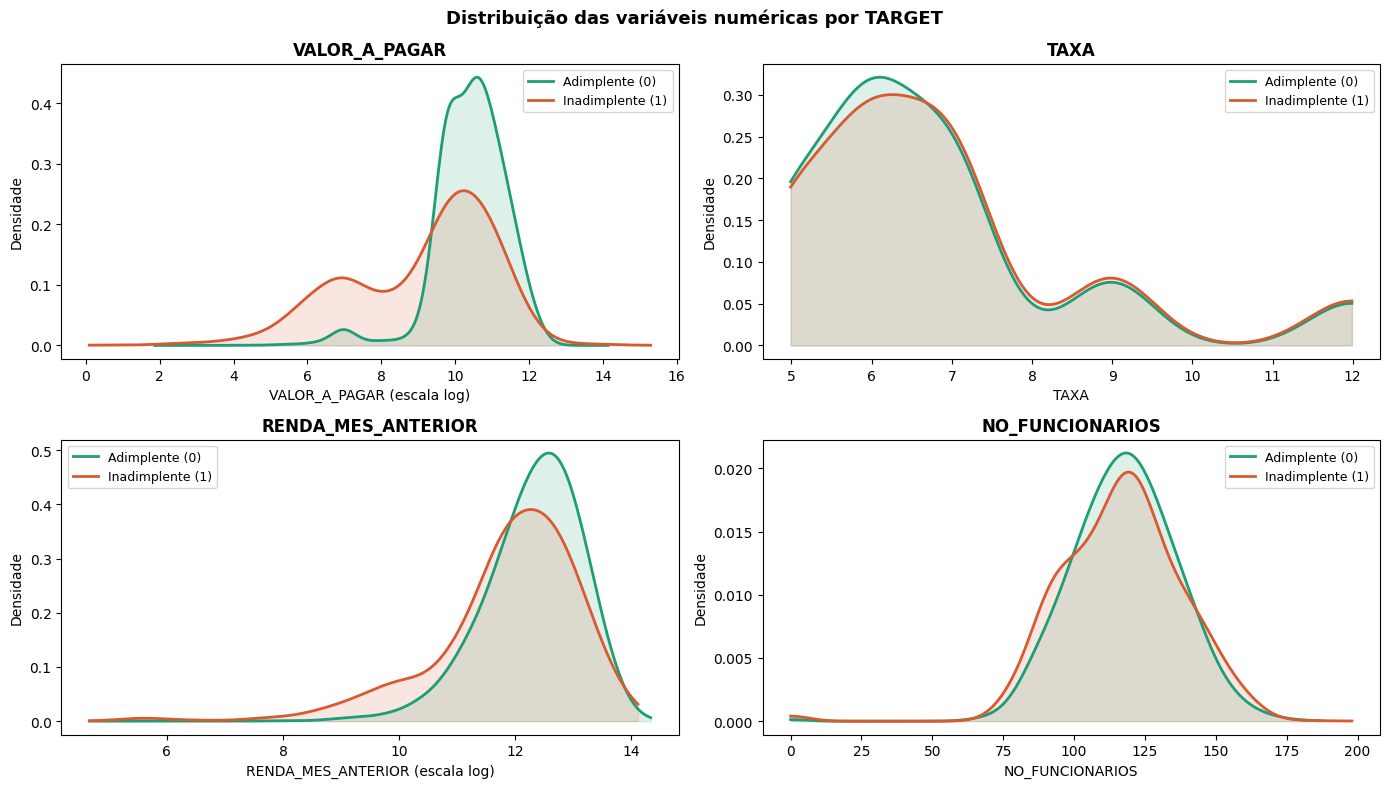

In [ ]:
# 2.1 Distribuição das variáveis numéricas
# KDE (kernel density) é mais limpo que histograma para
# comparar duas distribuições sobrepostas.
# Log scale em VALOR_A_PAGAR e RENDA para revelar a forma
# real da distribuição sem ser dominado pela assimetria.

from scipy.stats import gaussian_kde

# Define quais variáveis usar e se aplicar log
numericas_config = {
    "VALOR_A_PAGAR":      {"log": True},
    "TAXA":               {"log": False},
    "RENDA_MES_ANTERIOR": {"log": True},
    "NO_FUNCIONARIOS":    {"log": False}
}

# Cria grid de gráficos (2x2)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

# Loop sobre cada variável
for ax, (col, cfg) in zip(axes, numericas_config.items()):

    # Separa por target
    adim = df2[df2["TARGET"] == 0][col].dropna()
    inad = df2[df2["TARGET"] == 1][col].dropna()

    # Aplica transformação log se necessário
    if cfg["log"]:
        adim = adim[adim > 0]  # remove zeros
        inad = inad[inad > 0]
        adim = np.log1p(adim)  # log(1+x)
        inad = np.log1p(inad)
        xlabel = f"{col} (escala log)"
    else:
        xlabel = col

    # Loop para plotar KDE de cada grupo
    for serie, cor, label in [
        (adim, "#1D9E75", "Adimplente (0)"),
        (inad, "#D85A30", "Inadimplente (1)")
    ]:
        kde  = gaussian_kde(serie, bw_method=0.3)  # estima densidade
        xmin = serie.min()
        xmax = serie.max()
        x    = np.linspace(xmin, xmax, 300)

        # Curva de densidade
        ax.plot(x, kde(x), linewidth=2, label=label,
                color=cor)

        # Área preenchida para melhor visual
        ax.fill_between(x, kde(x), alpha=0.15, color=cor)

    # Ajustes visuais
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Densidade")
    ax.legend(fontsize=9)

# Título geral
plt.suptitle("Distribuição das variáveis numéricas por TARGET",
             fontsize=13, fontweight="bold")

# Ajuste de layout
plt.tight_layout()

# Exibe gráficos
plt.show()

**Análise dos gráficos nos mostram insights importantes:**

**VALOR_A_PAGAR**

Esse é o mais revelador. A curva verde (adimplentes) está claramente deslocada para a direita em relação à laranja (inadimplentes) devido que adimplentes têm cobranças maiores. Inadimplentes concentram mais na faixa baixa de valores (escala log 6-9, equivalente a 400 a 8k). Isso confirma o que vimos antes, que cobranças de alto valor pertencem a empresas maiores que pagam melhor. A variável tem poder preditivo visual claro.

**TAXA**

Duas curvas quase sobrepostas com pequena diferença na cauda direita, o que quer dizer que inadimplentes têm densidade ligeiramente maior nas taxas altas (acima de 8%). O sinal existe mas é fraco individualmente.

**RENDA_MES_ANTERIOR**

Padrão similar ao VALOR_A_PAGAR, os adimplentes têm renda maior (curva verde deslocada à direita) e isso faz sentido porque empresas com maior faturamento têm mais capacidade de pagamento. Sinal moderado e na direção esperada.

**NO_FUNCIONARIOS**

Curvas praticamente sobrepostas indicando que a variável tem baixíssimo poder discriminativo individual. Inadimplentes aparecem levemente mais concentrados em empresas menores (abaixo de 75 funcionários) mas a diferença é mínima. Vai ser mais útil como feature de nulo do que como valor numérico em si.

In [ ]:
# 2.2 Média das numéricas por TARGET
# Complementa o KDE com números concretos.
# Diferença na média indica poder preditivo da variável.


# Lista de variáveis numéricas
numericas = ["VALOR_A_PAGAR", "TAXA",
             "RENDA_MES_ANTERIOR", "NO_FUNCIONARIOS"]

print("── Média das variáveis numéricas por TARGET ─────────────")

# Calcula média por TARGET (0 = adimplente, 1 = inadimplente)
medias = df2.groupby("TARGET")[numericas].mean().round(2)

# Transpõe para facilitar leitura (variáveis nas linhas)
# Renomeia colunas e calcula diferença percentual
print(
    medias.T
    .rename(columns={0: "Adimplente", 1: "Inadimplente"})
    .assign(diff_pct=lambda x: (
        (x["Inadimplente"] - x["Adimplente"])
        / x["Adimplente"] * 100
    ).round(1))
    .to_string()
)

── Média das variáveis numéricas por TARGET ─────────────
TARGET              Adimplente  Inadimplente  diff_pct
VALOR_A_PAGAR       47713.1500    31645.8500  -33.7000
TAXA                    6.7800        6.8700    1.3000
RENDA_MES_ANTERIOR 295401.9800   238589.9000  -19.2000
NO_FUNCIONARIOS       117.7800      116.5100   -1.1000


**VALOR_A_PAGAR** — diferença de -33.7%

Inadimplentes devem em média 31.6k contra 47.7k dos adimplentes. A maior diferença relativa entre todas as variáveis. Cobranças menores estão associadas a clientes de maior risco e provavelmente empresas menores com menos capacidade financeira. Feature com alto poder preditivo confirmado.

**RENDA_MES_ANTERIOR** — diferença de -19.2%

Inadimplentes faturam em média 238k contra 295k dos adimplentes. Direção esperada e fazer sentido já que menor faturamento, maior dificuldade de pagamento. Sinal moderado e consistente com o gráfico KDE.

**TAXA** — diferença de apenas +1.3%

6.87% para inadimplentes contra 6.78% para adimplentes. Diferença mínima em termos de média, mas o sinal está na cauda, clientes com taxas muito altas (9%, 10%, 12%) concentram mais inadimplência. A média não captura isso bem, o que reforça que TAXA é mais útil como variável categórica ou com transformação de faixas do que como valor contínuo puro.

**NO_FUNCIONARIOS** — diferença de -1.1%

Praticamente zero. Confirma o que o KDE mostrou, essa variável tem poder preditivo individual muito baixo. Seu valor está mais na flag de nulo e em combinação com outras variáveis do que sozinha.

**Insight para feature engineering**

A razão VALOR_A_PAGAR / RENDA_MES_ANTERIOR pode ser uma feature poderosa que captura o peso relativo da cobrança sobre o faturamento do cliente. Um cliente com cobrança de 50k e renda de 60k está em situação muito mais arriscada que um com cobrança de 50k e renda de 500k.

In [ ]:
# 3.1 Distribuição das variáveis categóricas
# Aqui vou transformar os números das colunas DDD e CEP_2_DIG em categóricos
# Para ter uma melhor visualização e análise dessas colunas
# Mapeamento DDD = Estado
mapa_ddd = {
    "11": "SP", "12": "SP", "13": "SP", "14": "SP", "15": "SP",
    "16": "SP", "17": "SP", "18": "SP", "19": "SP",
    "21": "RJ", "22": "RJ", "24": "RJ",
    "27": "ES", "28": "ES",
    "31": "MG", "32": "MG", "33": "MG", "34": "MG", "35": "MG",
    "37": "MG", "38": "MG",
    "41": "PR", "42": "PR", "43": "PR", "44": "PR", "45": "PR", "46": "PR",
    "47": "SC", "48": "SC", "49": "SC",
    "51": "RS", "53": "RS", "54": "RS", "55": "RS",
    "61": "DF",
    "62": "GO", "64": "GO",
    "63": "TO",
    "65": "MT", "66": "MT",
    "67": "MS",
    "68": "AC",
    "69": "RO",
    "71": "BA", "73": "BA", "74": "BA", "75": "BA", "77": "BA",
    "79": "SE",
    "81": "PE", "87": "PE",
    "82": "AL",
    "83": "PB",
    "84": "RN",
    "85": "CE", "88": "CE",
    "86": "PI", "89": "PI",
    "91": "PA", "93": "PA", "94": "PA",
    "92": "AM", "97": "AM",
    "95": "RR",
    "96": "AP",
    "98": "MA", "99": "MA",
}

# Mapeamento CEP_2_DIG → Região
def cep_para_regiao(cep):
    try:
        cep = int(cep)
    except (ValueError, TypeError):
        return "DESCONHECIDO"
    if 1 <= cep <= 9:
        return "SP_Capital"
    elif 10 <= cep <= 19:
        return "SP_Interior"
    elif 20 <= cep <= 28:
        return "RJ"
    elif cep == 29:
        return "ES"
    elif 30 <= cep <= 39:
        return "MG"
    elif 40 <= cep <= 48:
        return "BA"
    elif cep == 49:
        return "SE"
    elif 50 <= cep <= 56:
        return "PE"
    elif cep == 57:
        return "AL"
    elif cep == 58:
        return "PB"
    elif cep == 59:
        return "RN"
    elif 60 <= cep <= 63:
        return "CE"
    elif cep == 64:
        return "PI"
    elif cep == 65:
        return "MA"
    elif 66 <= cep <= 68:
        return "PA"
    elif cep == 69:
        return "AM_RR_AC"
    elif 70 <= cep <= 73:
        return "DF_GO"
    elif 74 <= cep <= 76:
        return "GO"
    elif cep == 77:
        return "TO"
    elif cep == 78:
        return "MT"
    elif cep == 79:
        return "MS"
    elif 80 <= cep <= 87:
        return "PR"
    elif 88 <= cep <= 89:
        return "SC"
    elif 90 <= cep <= 99:
        return "RS"
    else:
        return "DESCONHECIDO"

# Aplicar mapeamentos
# DDD já é string — mapear diretamente
df2["ESTADO_DDD"] = df2["DDD"].map(mapa_ddd).fillna("DESCONHECIDO")

# CEP_2_DIG pode ser int ou string — converter para int
df2["REGIAO_CEP"] = (df2["CEP_2_DIG"]
                    .apply(lambda x:
                           cep_para_regiao(x)
                           if pd.notna(x) else "DESCONHECIDO"))

# Verificar resultado
print("── ESTADO_DDD ───────────────────────────────────────────")
print(df2["ESTADO_DDD"].value_counts())

print("\n── REGIAO_CEP ───────────────────────────────────────────")
print(df2["REGIAO_CEP"].value_counts())

# Verificar taxa de inadimplência por estado
print("\n── Taxa de inadimplência por ESTADO_DDD ─────────────────")
print(df2.groupby("ESTADO_DDD")["TARGET"]
      .agg(["mean", "count"])
      .rename(columns={"mean": "taxa_inad", "count": "n"})
      .sort_values("taxa_inad", ascending=False)
      .round(4)
      .to_string())

print("\n── Taxa de inadimplência por REGIAO_CEP ─────────────────")
print(df2.groupby("REGIAO_CEP")["TARGET"]
      .agg(["mean", "count"])
      .rename(columns={"mean": "taxa_inad", "count": "n"})
      .sort_values("taxa_inad", ascending=False)
      .round(4)
      .to_string())

── ESTADO_DDD ───────────────────────────────────────────
ESTADO_DDD
SP              18588
DESCONHECIDO     9448
MG               8507
PR               6969
RJ               4281
BA               4094
SC               3698
RS               3445
GO               2619
PA               2099
MT               1900
CE               1874
ES               1832
PE               1437
MA               1247
MS               1066
DF                983
RO                855
TO                654
PI                519
AM                362
AL                334
RR                224
PB                187
SE                180
RN                 11
Name: count, dtype: int64

── REGIAO_CEP ───────────────────────────────────────────
REGIAO_CEP
SP_Interior     12444
MG              11830
PR               8620
RS               6347
RJ               6232
BA               5861
SC               4172
GO               3642
PA               3529
CE               2246
PE               2188
MT               2067

**ESTADO_DDD — destaques**

RR com 74.5% de inadimplência é um outlier extremo, mas tem apenas 224 registros, então a taxa é instável estatisticamente. RN com 27.3% tem apenas 11 registros é completamente irrelevante. DF com 23.7% e MT com 17.7% têm volume razoável e taxas altas consistentes. No extremo oposto, PB com 0% tem apenas 187 registros. PR, SC e RS formam um bloco de baixo risco (4-5%). SP com 5.6% também abaixo da média de 7%.

**REGIAO_CEP — padrão regional claro**

Confirma o padrão geográfico. Norte e Centro-Oeste (MA, MT, DF_GO, MS) com taxas altas entre 16% e 22%. Sul (PR, SC, RS) com taxas baixas entre 3% e 4%. Sudeste (MG, RJ, ES) na média ou abaixo. Esse gradiente geográfico é um sinal preditivo real e importante.

**Decisão importante para o feature engineering**

Estados com menos de 200 registros (RN, PB, SE, AM) têm taxas instáveis podendo gerar ruído no modelo. A estratégia que penso é agrupar estados pequenos em uma categoria regional antes de fazer o encoding. Por exemplo, todos os estados do Norte com baixo volume viram "NORTE_OUTROS".

**O que isso confirma?**

Tanto ESTADO_DDD quanto REGIAO_CEP têm poder preditivo geográfico relevante e devem entrar no modelo. REGIAO_CEP é mais limpa porque já agrega por região, enquanto ESTADO_DDD tem mais granularidade mas exige tratamento dos estados com baixo volume.

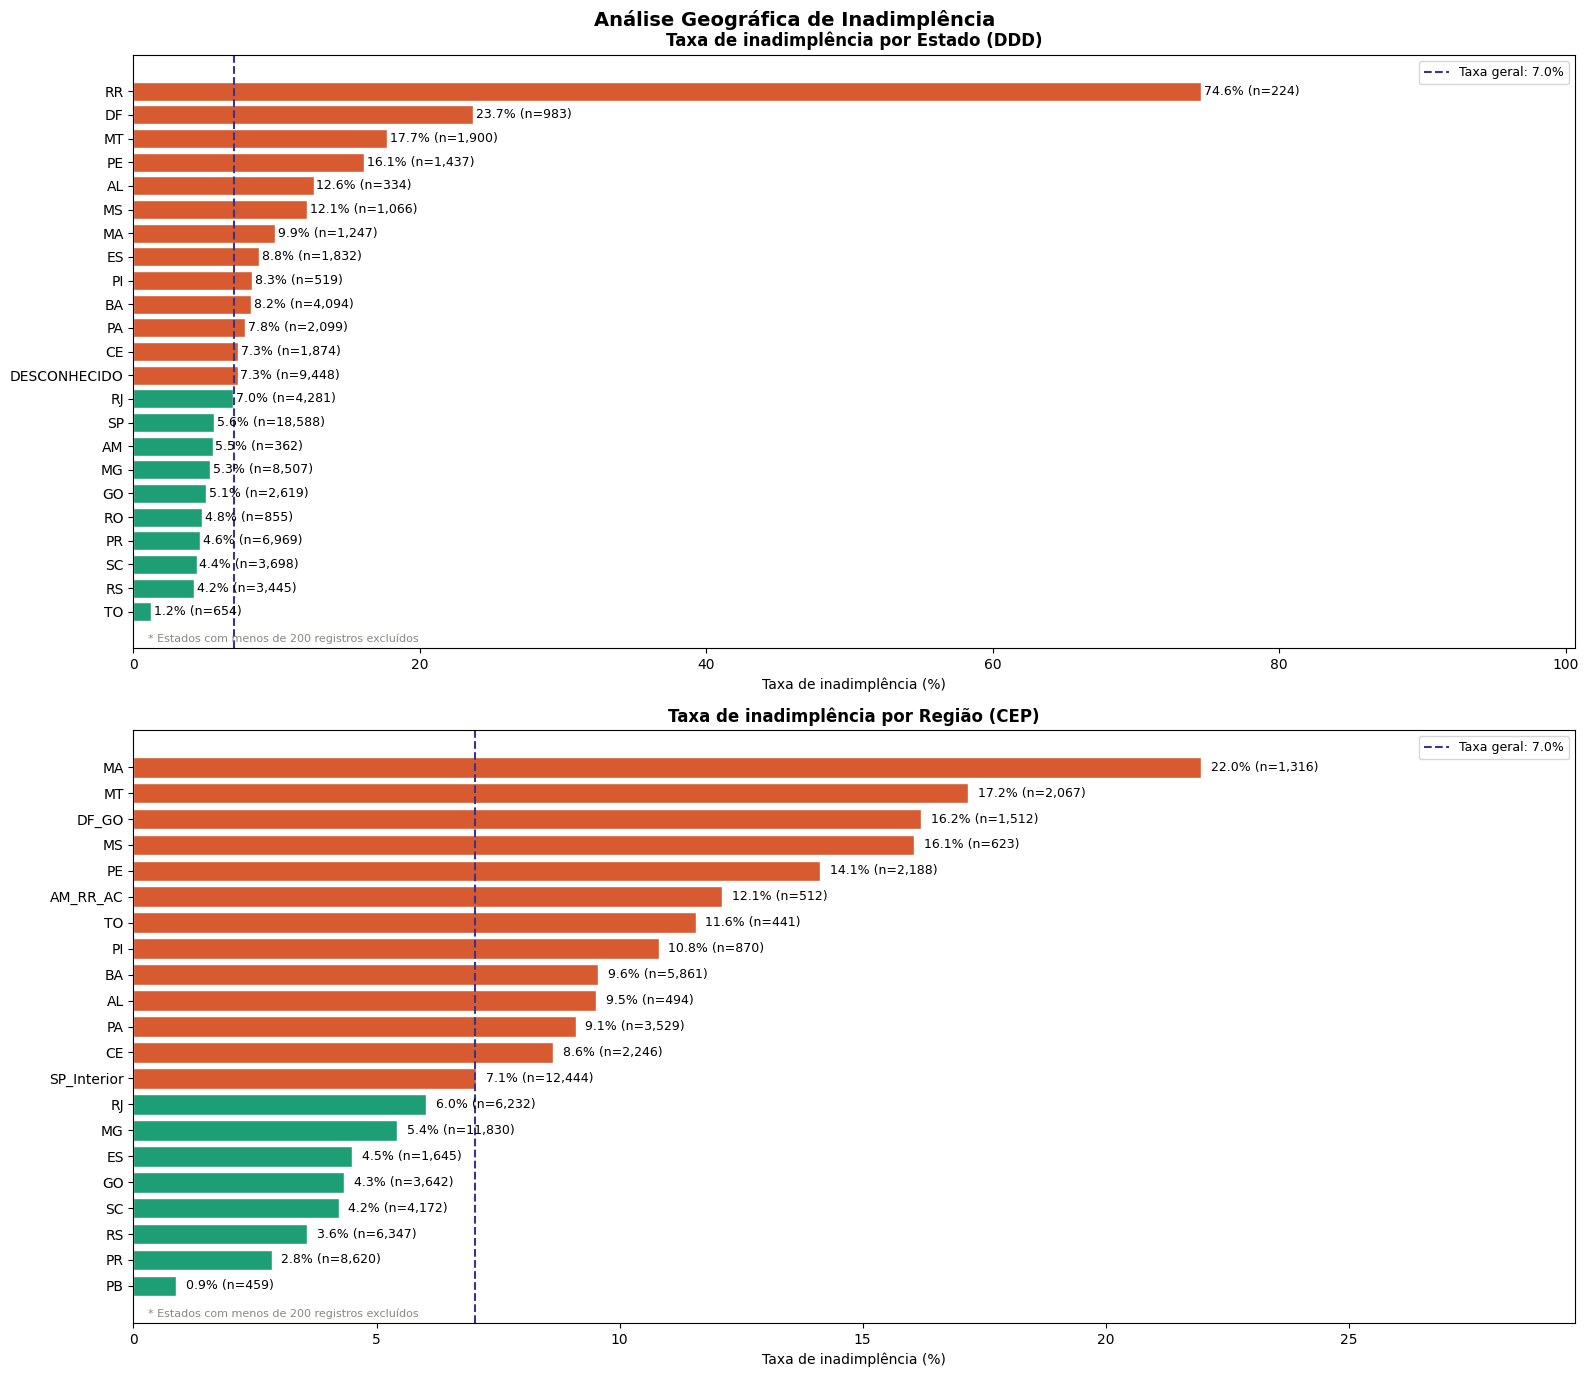

In [ ]:
# 3.2 Análise geográfica: ESTADO_DDD e REGIAO_CEP
# Visualizar taxa de inadimplência por estado e região.
# Barras coloridas: laranja = acima da média, verde = abaixo.
# Filtramos estados com menos de 200 registros para evitar
# taxas instáveis que podem enganar o modelo.

taxa_geral = df2["TARGET"].mean() * 100
volume_min = 200  # mínimo de registros para plotar

fig, axes = plt.subplots(2, 1, figsize=(16, 14))

for ax, col, titulo in zip(
    axes,
    ["ESTADO_DDD", "REGIAO_CEP"],
    ["Taxa de inadimplência por Estado (DDD)",
     "Taxa de inadimplência por Região (CEP)"]
):
    taxa = (df2.groupby(col)["TARGET"]
            .agg(["mean", "count"])
            .rename(columns={"mean": "taxa_inad", "count": "n"})
            .reset_index())
    taxa["taxa_%"] = taxa["taxa_inad"] * 100

    # Filtrar volume mínimo
    taxa = taxa[taxa["n"] >= volume_min].sort_values(
        "taxa_%", ascending=True)

    cores = ["#D85A30" if v > taxa_geral else "#1D9E75"
             for v in taxa["taxa_%"]]

    bars = ax.barh(taxa[col].astype(str),
                   taxa["taxa_%"],
                   color=cores, edgecolor="white")

    # Valor e volume em cada barra
    for bar, v, n in zip(bars, taxa["taxa_%"], taxa["n"]):
        ax.text(v + 0.2,
                bar.get_y() + bar.get_height() / 2,
                f"{v:.1f}% (n={n:,})",
                va="center", fontsize=9)

    ax.axvline(taxa_geral, color="#3C3489",
               linestyle="--", linewidth=1.5,
               label=f"Taxa geral: {taxa_geral:.1f}%")
    ax.set_title(titulo, fontsize=12, fontweight="bold")
    ax.set_xlabel("Taxa de inadimplência (%)")
    ax.legend(fontsize=9)
    ax.set_xlim(0, taxa["taxa_%"].max() * 1.35)

    # Nota sobre estados filtrados
    n_filtrados = (taxa["n"] < volume_min).sum() if "n" in taxa else 0
    ax.annotate(f"* Estados com menos de {volume_min} registros excluídos",
                xy=(0.01, 0.01), xycoords="axes fraction",
                fontsize=8, color="#888780")

plt.suptitle("Análise Geográfica de Inadimplência",
             fontsize=14, fontweight="bold")
plt.tight_layout()

plt.show()

**Mostrando visualmente a análise dos estados e regiões:**

**ESTADO_DDD**

RR com 74.6% é claramente um outlier extremo, mesmo com 224 registros acima do filtro de 200, a taxa é instável. Vale considerar agrupar RR com outros estados do Norte no feature engineering. DF com 23.7% e MT com 17.7% têm volume relevante e taxas consistentemente altas é um sinal confiável. O bloco Sul forma um grupo coeso de baixo risco: RS 4.2%, SC 4.4%, PR 4.6%. TO com 1.2% é surpreendente e merece atenção, pode ser volume ainda pequeno gerando taxa artificialmente baixa. SP com 5.6% abaixo da média apesar de ser o maior estado em volume confirma que empresas paulistas pagam melhor.

**REGIAO_CEP**

Gradiente geográfico muito claro e mais estável que o DDD porque os grupos têm volume maior. Norte e Centro-Oeste no topo: MA 22%, MT 17.2%, DF_GO 16.2%, MS 16.1%. Sul no fundo: PR 2.8%, RS 3.6%, SC 4.2%. Sudeste na média ou abaixo: MG 5.4%, RJ 6.0%. SP_Interior em 7.1% etsá exatamente na média geral.

**Insight importante**

**REGIAO_CEP** é mais confiável que ESTADO_DDD para o modelo porque tem grupos com volume maior e taxas mais estáveis. Os dois podem entrar como features, mas REGIAO_CEP deve ter prioridade.

In [ ]:
# 3.3 Variáveis categóricas vs TARGET
# Taxa de inadimplência por categoria.
# Categorias com taxas muito diferentes da média geral (7%)
# têm alto poder discriminativo e devem ser priorizadas
# no feature engineering.

# Lista de variáveis categóricas
categoricas = ["PORTE", "SEGMENTO_INDUSTRIAL",
               "CEP_2_DIG", "DOMINIO_EMAIL"]

# Loop sobre cada variável categórica
for col in categoricas:

    # Agrupa por categoria (incluindo nulos) e calcula:
    # - taxa média de inadimplência
    # - quantidade de registros
    taxa = (df2.groupby(col, dropna=False)["TARGET"]
            .agg(["mean", "count"])
            .rename(columns={"mean": "taxa_inad", "count": "n"})
            .sort_values("taxa_inad", ascending=False)
            .reset_index())

    # Converte taxa para percentual
    taxa["taxa_inad_%"] = (taxa["taxa_inad"] * 100).round(2)

    # Percentual que a categoria representa na base
    taxa["pct_base_%"]  = (taxa["n"] / len(df) * 100).round(2)

    # Exibe resultados formatados
    print(f"\n{'='*55}")
    print(f"  {col}")
    print(f"{'='*55}")
    print(taxa[[col, "n", "pct_base_%",
                "taxa_inad_%"]].to_string(index=False))


  PORTE
  PORTE     n  pct_base_%  taxa_inad_%
    NaN  2476      3.2000      17.4900
Pequeno 15976     20.6400       9.1700
  Medio 29929     38.6600       6.4800
 Grande 29032     37.5000       5.5100

  SEGMENTO_INDUSTRIAL
SEGMENTO_INDUSTRIAL     n  pct_base_%  taxa_inad_%
           Serviços 31638     40.8700       8.7500
          Indústria 17296     22.3400       7.6500
                NaN  1417      1.8300       7.3400
           Comércio 27062     34.9600       4.5900

  CEP_2_DIG
CEP_2_DIG    n  pct_base_%  taxa_inad_%
       51   45      0.0600      88.8900
       na    8      0.0100      87.5000
       63   36      0.0500      52.7800
       70  355      0.4600      39.7200
       48  357      0.4600      36.1300
       33  104      0.1300      30.7700
       67  339      0.4400      30.3800
       78 1035      1.3400      29.0800
       48  241      0.3100      26.1400
       52    4      0.0100      25.0000
       65  726      0.9400      23.4200
       55  553      0.710

**PORTE — sinal forte**

Relação perfeita e clara: quanto menor o porte, maior a inadimplência. NaN 17.5%, Pequeno 9.2%, Médio 6.5%, Grande 5.5%. É uma das variáveis mais discriminativas da base. A progressão monotônica é exatamente o que modelos de árvore adoram capturar. Feature essencial no modelo.

**SEGMENTO_INDUSTRIAL — sinal moderado**

Serviços com 8.75% acima da média, Indústria com 7.65% na média e Comércio com 4.59% bem abaixo. Faz sentido de negócio, empresas de comércio têm fluxo de caixa mais previsível que serviços. Diferença de 4 pontos percentuais entre o maior e menor segmento é relevante.

**CEP_2_DIG — confirma que REGIAO_CEP é melhor**

A tabela tem mais de 150 linhas com muitos CEPs com volume mínimo e taxas instáveis e o CEP 51 com 88.9% tem apenas 45 registros, completamente não confiável. Isso confirma que usar REGIAO_CEP agrupado é a decisão certa para o modelo. A tabela crua de CEP_2_DIG não será usada diretamente.

**DOMINIO_EMAIL — sinal surpreendente**

Hotmail com 9.26% é o mais inadimplente, provavelmente usuários mais antigos e menos ativos digitalmente. AOL com 3.9% é o menos inadimplente, tem base de usuários muito específica. Gmail e Yahoo na média. A diferença entre Hotmail e AOL é de 5.4 pontos percentuais que é um sinal relevante que justifica manter a variável no modelo.

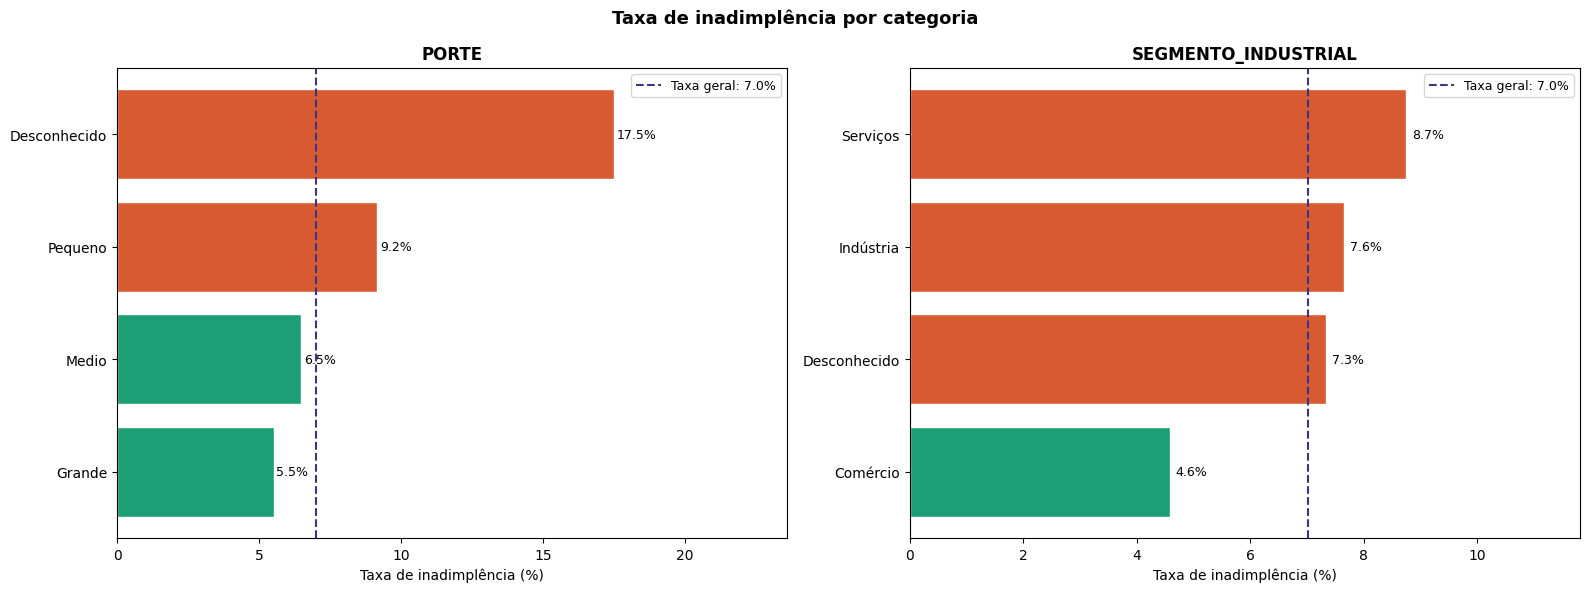

In [ ]:
# 3.4 Gráfico: taxa de inadimplência por PORTE e SEGMENTO
# Substituir nan por DESCONHECIDO apenas para visualização
# Não altera os dados originais

# Calcula a taxa geral de inadimplência (baseline)
taxa_geral = df2["TARGET"].mean() * 100

# Cria figura com 2 gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loop sobre variáveis categóricas
for ax, col, col_viz, titulo in zip(
    axes,
    ["PORTE", "SEGMENTO_INDUSTRIAL"],     # colunas originais
    ["PORTE_VIZ", "SEGMENTO_VIZ"],        # colunas temporárias para visualização
    ["PORTE", "SEGMENTO_INDUSTRIAL"]      # títulos
):
    # Substitui nulos por "Desconhecido" para análise
    df2[col_viz] = df2[col].fillna("Desconhecido")

    # Calcula taxa de inadimplência por categoria
    taxa = (df2.groupby(col_viz)["TARGET"]
            .mean()
            .reset_index()
            .rename(columns={"TARGET": "taxa_inad"}))

    # Converte para percentual
    taxa["taxa_inad_%"] = taxa["taxa_inad"] * 100

    # Ordena para melhorar visualização
    taxa = taxa.sort_values("taxa_inad_%", ascending=True)

    # Define cores: acima da média (vermelho), abaixo (verde)
    cores = ["#D85A30" if v > taxa_geral else "#1D9E75"
             for v in taxa["taxa_inad_%"]]

    # Cria gráfico de barras horizontal
    bars = ax.barh(taxa[col_viz].astype(str),
                   taxa["taxa_inad_%"],
                   color=cores, edgecolor="white")

    # Adiciona valores nas barras
    for bar, v in zip(bars, taxa["taxa_inad_%"]):
        ax.text(v + 0.1,
                bar.get_y() + bar.get_height() / 2,
                f"{v:.1f}%",
                va="center", fontsize=9)

    # Linha de referência com taxa média geral
    ax.axvline(taxa_geral, color="#3C3489",
               linestyle="--", linewidth=1.5,
               label=f"Taxa geral: {taxa_geral:.1f}%")

    # Ajustes visuais
    ax.set_title(titulo, fontsize=12, fontweight="bold")
    ax.set_xlabel("Taxa de inadimplência (%)")
    ax.set_xlim(0, taxa["taxa_inad_%"].max() * 1.35)
    ax.legend(fontsize=9)

    # Remove coluna temporária
    df2.drop(columns=[col_viz], inplace=True)

# Título geral
plt.suptitle("Taxa de inadimplência por categoria",
             fontsize=13, fontweight="bold")

# Ajuste de layout
plt.tight_layout()

# Exibe gráfico
plt.show()

***PORTE**

A progressão é visual e imediata. **Deconhecido** dispara para 17.5% , quase 2.5x a média geral. **Porte Pequeno** em 9.2% ainda acima da média. **Porte Médio e Grande** abaixo da linha tracejada em 6.5% e 5.5% respectivamente. Qualquer pessoa que veja esse gráfico entende instantaneamente a relação: quanto menor ou menos formalizado o cliente, maior o risco.

**SEGMENTO_INDUSTRIAL**

**Serviços e Indústria** acima da linha de 7%, **Comércio** bem abaixo em 4.6%. O **Desconhecido** em 7.3% ficando acima da linha é coerente com o que já sabemos, clientes sem segmento tendem a ser menos formalizados.

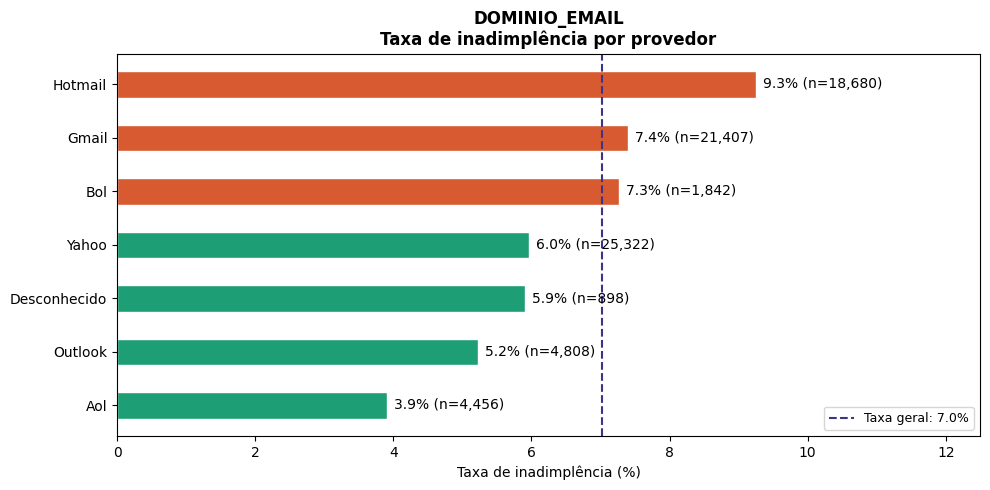

In [ ]:
# 3.5 Gráfico: Taxa de inadimplência por DOMINIO_EMAIL
# Separado de PORTE e SEGMENTO para ter espaço adequado.
# Mesmo padrão visual — barras horizontais ordenadas por taxa.

# Calcula a taxa geral de inadimplência (baseline)
taxa_geral = df2["TARGET"].mean() * 100

# Agrupa por domínio de e-mail e calcula:
# - taxa média de inadimplência
# - quantidade de registros
taxa_email = (df2.groupby("DOMINIO_EMAIL", dropna=False)["TARGET"]
              .agg(["mean", "count"])
              .rename(columns={"mean": "taxa_inad", "count": "n"})
              .reset_index())

# Converte taxa para percentual
taxa_email["taxa_%"] = taxa_email["taxa_inad"] * 100

# Trata valores nulos como "DESCONHECIDO"
taxa_email["DOMINIO_EMAIL"] = taxa_email["DOMINIO_EMAIL"].fillna(
    "Desconhecido")

# Ordena para melhor visualização
taxa_email = taxa_email.sort_values("taxa_%", ascending=True)

# Cria figura
fig, ax = plt.subplots(figsize=(10, 5))

# Define cores: acima da média (vermelho), abaixo (verde)
cores = ["#D85A30" if v > taxa_geral else "#1D9E75"
         for v in taxa_email["taxa_%"]]

# Cria gráfico de barras horizontal
bars = ax.barh(taxa_email["DOMINIO_EMAIL"].astype(str),
               taxa_email["taxa_%"],
               color=cores, edgecolor="white", height=0.5)

# Adiciona valores e volume nas barras
for bar, v, n in zip(bars, taxa_email["taxa_%"], taxa_email["n"]):
    ax.text(v + 0.1,
            bar.get_y() + bar.get_height() / 2,
            f"{v:.1f}% (n={n:,})",
            va="center", fontsize=10)

# Linha de referência com taxa média geral
ax.axvline(taxa_geral, color="#3C3489",
           linestyle="--", linewidth=1.5,
           label=f"Taxa geral: {taxa_geral:.1f}%")

# Ajustes visuais
ax.set_title("DOMINIO_EMAIL\nTaxa de inadimplência por provedor",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Taxa de inadimplência (%)")
ax.set_xlim(0, taxa_email["taxa_%"].max() * 1.35)
ax.legend(fontsize=9)

# Ajuste de layout
plt.tight_layout()

# Exibe gráfico
plt.show()

**Hotmail — maior risco (9.3%)**

Acima da média em 2.3 pontos percentuais. Hotmail é historicamente associado a usuários mais antigos e pode ser menos ativos digitalmente, pode indicar empresas com perfil mais tradicional e menos digitalizado, o que correlaciona com menor organização financeira.

**Gmail e Bol — levemente acima da média**

7.4% e 7.3% respectivamente. Praticamente na média geral, pouco poder discriminativo individual mas ainda acima da linha.
Yahoo, Desconhecido, Outlook estão abaixo da média
Yahoo com 6.0% e Outlook com 5.2%, usuários de Outlook tendem a ser empresas mais formalizadas com email corporativo, o que explica o menor risco.

**AOL — menor risco (3.9%)**

Quase metade da taxa do Hotmail. AOL tem uma base de usuários muito específica e provavelmente mais antiga e estável financeiramente. Sinal consistente e com volume razoável de 4.456 registros.

**Decisão para feature engineering**

A variável tem poder discriminativo real com uma diferença de 5.4 pontos entre Hotmail e AOL com volumes grandes nos dois extremos. Manter no modelo. Talvez agrupar em três faixas de risco para reduzir cardinalidade: alto risco (Hotmail, Gmail, Bol), médio risco (Yahoo, Desconhecido) e baixo risco (Outlook, AOL) seja uma estratégia.

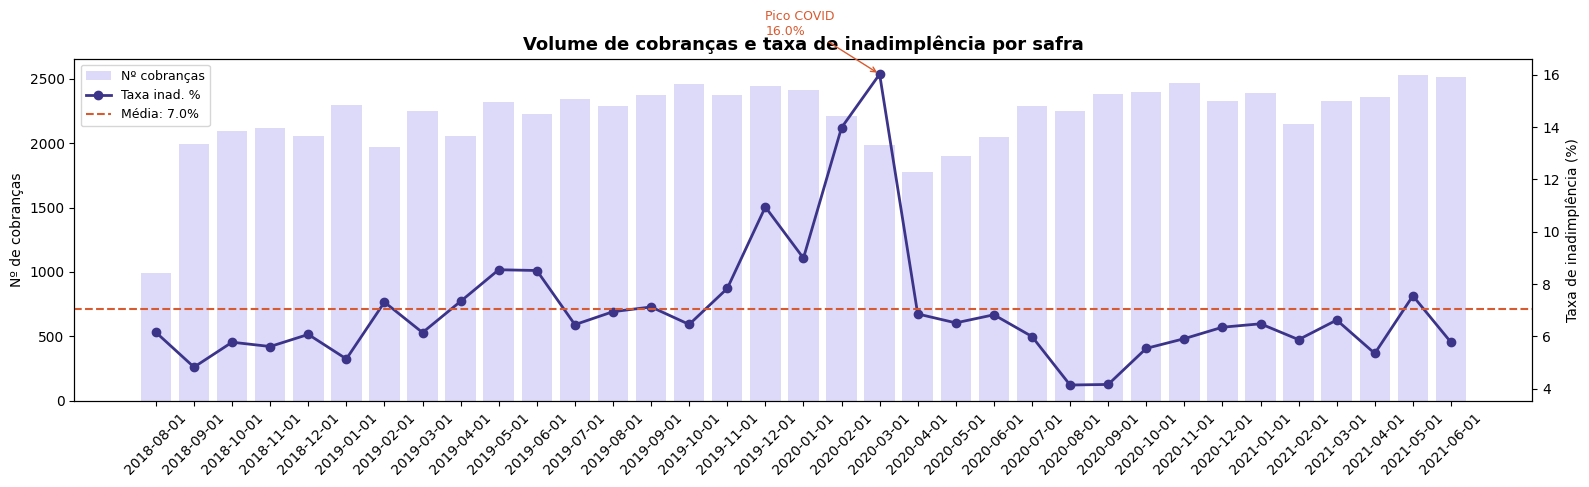

In [ ]:
# ============================================================
# Análise Temporal
# ============================================================
# Objetivo: entender como o comportamento de inadimplência
# evolui ao longo do tempo e identificar padrões sazonais.
# Esses insights definem a estratégia de time-based split
# e podem gerar features temporais relevantes.
# ============================================================

# 4.1 Taxa de inadimplência por safra
# Já vimos mas agora com a tabela
# analítica completa e com mais contexto para interpretar.

# Agrupa por safra (tempo) e calcula taxa de inadimplência e volume
taxa_safra = (df2.groupby("SAFRA_REF")["TARGET"]
              .agg(["mean", "count"])  # mean = taxa, count = volume
              .rename(columns={"mean": "taxa_inad", "count": "n"})
              .reset_index())

# Converte para % e extrai mês/ano (features temporais)
taxa_safra["taxa_%"] = taxa_safra["taxa_inad"] * 100
taxa_safra["mes"]    = taxa_safra["SAFRA_REF"].dt.month
taxa_safra["ano"]    = taxa_safra["SAFRA_REF"].dt.year

fig, ax1 = plt.subplots(figsize=(16, 5))

# Gráfico de barras - volume de cobranças por safra
ax1.bar(taxa_safra["SAFRA_REF"].astype(str),
        taxa_safra["n"],
        color="#CECBF6", alpha=0.7, label="Nº cobranças")
ax1.set_ylabel("Nº de cobranças")
ax1.tick_params(axis="x", rotation=45)

# Linha - taxa de inadimplência ao longo do tempo
ax2 = ax1.twinx()
ax2.plot(taxa_safra["SAFRA_REF"].astype(str),
         taxa_safra["taxa_%"],
         color="#3C3489", marker="o",
         linewidth=2, label="Taxa inad. %")

# Linha média - baseline de comparação
ax2.axhline(taxa_safra["taxa_%"].mean(),
            color="#D85A30", linestyle="--",
            linewidth=1.5,
            label=f"Média: {taxa_safra['taxa_%'].mean():.1f}%")
ax2.set_ylabel("Taxa de inadimplência (%)")

# Identifica e anota o pico de inadimplência
pico_idx = taxa_safra["taxa_%"].idxmax()
pico_val = taxa_safra.loc[pico_idx, "taxa_%"]
pico_data = taxa_safra.loc[pico_idx, "SAFRA_REF"].strftime("%Y-%m")

ax2.annotate(f"Pico COVID\n{pico_val:.1f}%",
             xy=(pico_idx, pico_val),
             xytext=(pico_idx - 3, pico_val + 1.5),
             fontsize=9, color="#D85A30",
             arrowprops=dict(arrowstyle="->",
                             color="#D85A30"))

# Junta legendas dos dois eixos
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper left", fontsize=9)

# Título e layout
ax1.set_title("Volume de cobranças e taxa de inadimplência por safra",
              fontsize=13, fontweight="bold")
fig.tight_layout()

plt.show()

**Volume de cobranças**

Base começa menor em agosto/2018 com cerca de 500 cobranças e cresce progressivamente até estabilizar entre 2.000 e 2.500 por mês a partir de 2019. Crescimento saudável e consistente da carteira.

**Taxa de inadimplência — padrão geral**

Oscila em torno da média de 7% na maior parte do período. Nenhuma tendência clara de piora ou melhora estrutural e o comportamento é estacionário exceto pelo evento de crise.

**Pico COVID — março/2020 em 16%**

Claramente anotado no gráfico. Subida abrupta de fevereiro (14%) para março (16%) seguida de queda igualmente abrupta para abril (6.8%). O choque foi intenso e temporário que é exatamente o padrão de um evento externo, não uma deterioração estrutural da carteira.

**Período pós-COVID — abaixo da média**

De agosto/2020 até dezembro/2020 a taxa fica consistentemente abaixo da linha vermelha de 7%, chegando a 4% em agosto e setembro. Depois volta gradualmente à média em 2021.

**Implicação para o time-based split**

Treino até dezembro/2020 captura o evento COVID inteiro, o modelo aprende que choques externos existem. Validação em janeiro a junho/2021 representa comportamento normalizado.

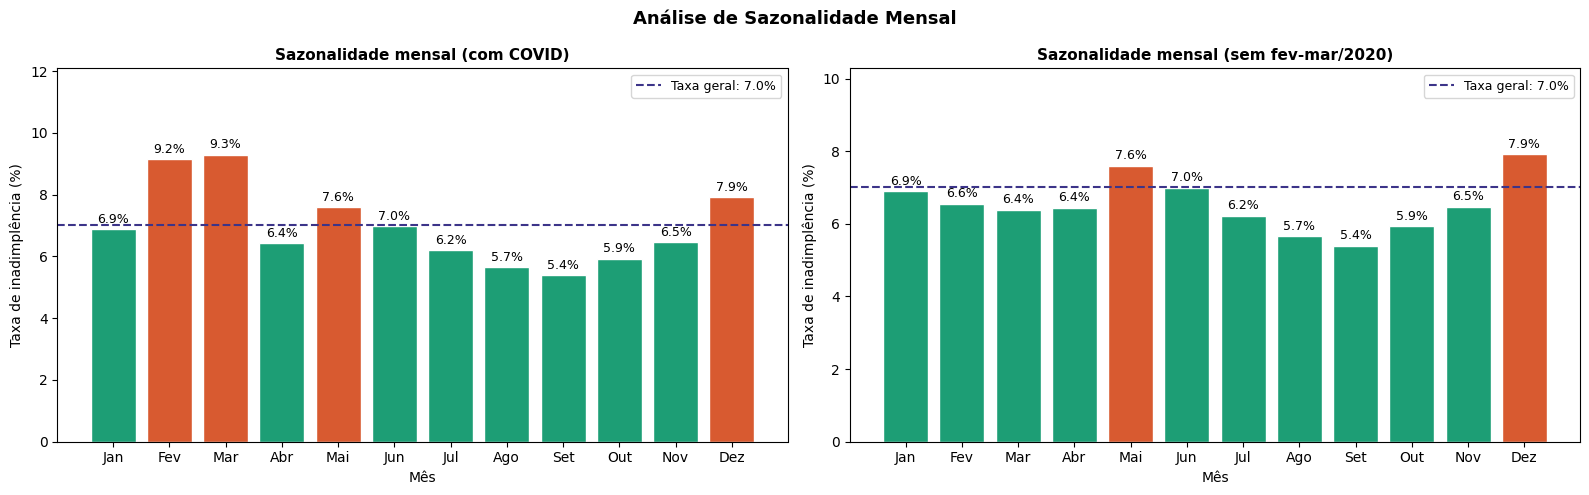

In [ ]:
# 4.2 Sazonalidade mensal
# Pergunta: há meses do ano com inadimplência consistentemente
# maior independente do ano?
# Se sim, o mês do vencimento é uma feature válida para o modelo.


# Cria features temporais (mês e ano) a partir da safra
df2["MES"] = df2["SAFRA_REF"].dt.month
df2["ANO"] = df2["SAFRA_REF"].dt.year

# Taxa de inadimplência por mês (com efeito COVID)
taxa_mes = (df2.groupby("MES")["TARGET"]
            .agg(["mean", "count"])  # taxa + volume
            .rename(columns={"mean": "taxa_inad", "count": "n"})
            .reset_index())
taxa_mes["taxa_%"] = taxa_mes["taxa_inad"] * 100

# Remove fev/mar de 2020 para limpar efeito anômalo (COVID)
taxa_mes_sem_covid = (
    df2[~((df2["MES"].isin([2, 3])) & (df2["ANO"] == 2020))]
    .groupby("MES")["TARGET"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "taxa_inad", "count": "n"})
    .reset_index()
)
taxa_mes_sem_covid["taxa_%"] = taxa_mes_sem_covid["taxa_inad"] * 100

# Mapeia número do mês → nome
nomes_mes = {1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr",
             5: "Mai", 6: "Jun", 7: "Jul", 8: "Ago",
             9: "Set", 10: "Out", 11: "Nov", 12: "Dez"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Taxa média geral (baseline)
taxa_geral = df2["TARGET"].mean() * 100

# Loop para comparar com e sem COVID
for ax, dados, titulo in zip(
    axes,
    [taxa_mes, taxa_mes_sem_covid],
    ["Sazonalidade mensal (com COVID)",
     "Sazonalidade mensal (sem fev-mar/2020)"]
):
    dados["nome_mes"] = dados["MES"].map(nomes_mes)

    # Cor: acima da média (vermelho), abaixo (verde)
    cores = ["#D85A30" if v > taxa_geral else "#1D9E75"
             for v in dados["taxa_%"]]

    # Gráfico de barras
    bars = ax.bar(dados["nome_mes"], dados["taxa_%"],
                  color=cores, edgecolor="white")

    # Valores nas barras
    for bar, v in zip(bars, dados["taxa_%"]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                v + 0.1, f"{v:.1f}%",
                ha="center", va="bottom", fontsize=9)

    # Linha da média geral
    ax.axhline(taxa_geral, color="#3C3489",
               linestyle="--", linewidth=1.5,
               label=f"Taxa geral: {taxa_geral:.1f}%")

    # Ajustes visuais
    ax.set_title(titulo, fontsize=11, fontweight="bold")
    ax.set_xlabel("Mês")
    ax.set_ylabel("Taxa de inadimplência (%)")
    ax.set_ylim(0, dados["taxa_%"].max() * 1.3)
    ax.legend(fontsize=9)

# Título geral
plt.suptitle("Análise de Sazonalidade Mensal",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

**Gráfico da esquerda — com COVID**

Fevereiro e março disparam para 9.2% e 9.3% isso demonstra claramente o efeito COVID distorcendo completamente a sazonalidade real. Sem esse filtro seria impossível identificar padrões reais.

**Gráfico da direita — sem COVID fev-mar/2020**

Esse é o que realmente importa para o feature engineering. O padrão fica muito mais claro. Dezembro lidera com 7.9%, fim de ano com pressão financeira nas empresas, 13º salário de funcionários, fechamento de balanço. Maio em 7.6% também acima da média, pode refletir pressão do início do segundo semestre fiscal. Janeiro em 6.9% surpreende por ser um mês tipicamente de aperto financeiro, mas pode ser que cobranças de janeiro tenham prazo mais longo.

**O que isso significa para o feature engineering?**

O mês do vencimento tem sinal preditivo real, dezembro e maio são meses de maior risco. Criar uma feature MES_VENCIMENTO é justificado por essa análise. Considerar também agrupar em grupos de risco: alto risco (dezembro, maio), médio risco (janeiro, abril, novembro), baixo risco (demais meses).

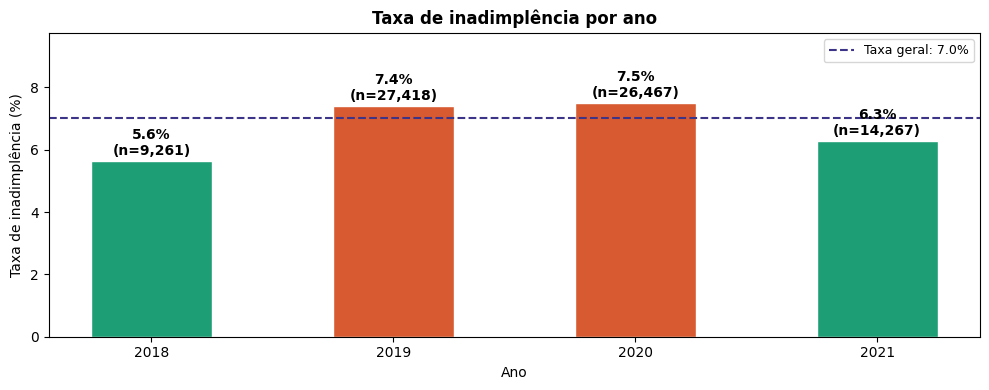

In [ ]:
# 4.3 Taxa por ano
# Visão anual para identificar tendência de longo prazo.
# Útil para entender se a base está melhorando ou piorando
# ao longo do tempo — impacta o time-based split.

# Agrupa por ano e calcula taxa de inadimplência e volume
taxa_ano = (df2.groupby("ANO")["TARGET"]
            .agg(["mean", "count"])  # mean = taxa, count = volume
            .rename(columns={"mean": "taxa_inad", "count": "n"})
            .reset_index())

# Converte taxa para percentual
taxa_ano["taxa_%"] = taxa_ano["taxa_inad"] * 100

fig, ax = plt.subplots(figsize=(10, 4))

# Define cores: acima da média (vermelho), abaixo (verde)
cores = ["#D85A30" if v > taxa_geral else "#1D9E75"
         for v in taxa_ano["taxa_%"]]

# Gráfico de barras por ano
bars = ax.bar(taxa_ano["ANO"].astype(str),
              taxa_ano["taxa_%"],
              color=cores, edgecolor="white", width=0.5)

# Adiciona taxa e volume em cada barra
for bar, v, n in zip(bars, taxa_ano["taxa_%"], taxa_ano["n"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            v + 0.1, f"{v:.1f}%\n(n={n:,})",
            ha="center", va="bottom", fontsize=10,
            fontweight="bold")

# Linha da média geral (baseline)
ax.axhline(taxa_geral, color="#3C3489",
           linestyle="--", linewidth=1.5,
           label=f"Taxa geral: {taxa_geral:.1f}%")

# Ajustes visuais
ax.set_title("Taxa de inadimplência por ano",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Ano")
ax.set_ylabel("Taxa de inadimplência (%)")
ax.set_ylim(0, taxa_ano["taxa_%"].max() * 1.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**2018 — 5.6% (n=9.261)**

Menor taxa do período e menor volume, base ainda em crescimento. Apenas 5 meses de dados (agosto a dezembro) o que explica o volume menor. Taxa baixa pode refletir uma carteira ainda jovem com clientes selecionados.

**2019 — 7.4% (n=27.418)**

Primeiro ano completo. Taxa sobe para 7.4% indicando acima da média geral de 7.0%. Volume estabilizado em torno de 2.300 cobranças por mês.

**2020 — 7.5% (n=26.467)**

O ano da pandemia. Taxa praticamente igual a 2019 em 7.5%, mas sabemos pelo gráfico de safras que isso é uma média que esconde o pico de 16% em março compensado pela queda abrupta no segundo semestre.

**2021 — 6.3% (n=14.267)**

Apenas 6 meses de dados (janeiro a junho). Taxa abaixo da média indicando período de normalização pós-pandemia. Isso é importante para o time-based split: validar em 2021 significa validar em um período de menor inadimplência que a média histórica. O modelo pode parecer melhor do que é, isso pode ser uma limitação

**Decisão para o split confirmada**

Treino: 2018 a 2020. Validação: janeiro a junho/2021. O modelo aprende o comportamento normal e o choque COVID, e valida em período normalizado.

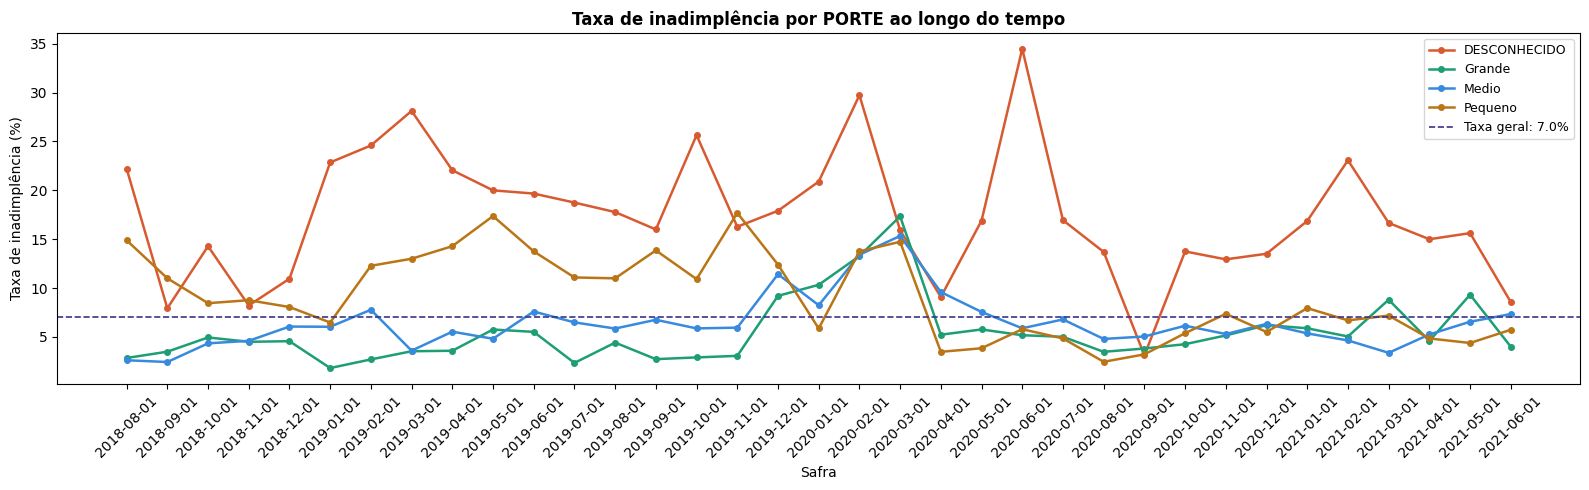

In [ ]:
# 4.4 Comportamento por PORTE ao longo do tempo
# Pergunta: o padrão de risco por porte é estável ao longo
# do tempo ou muda? Se mudar, pode ser necessário criar
# features de interação PORTE x SAFRA.

# Agrupa por safra e porte - taxa de inadimplência por segmento no tempo
taxa_porte_tempo = (df2.groupby(
    ["SAFRA_REF", "PORTE"], dropna=False)["TARGET"]
    .mean()  # taxa de inadimplência
    .reset_index()
    .rename(columns={"TARGET": "taxa_inad"}))

# Converte para percentual
taxa_porte_tempo["taxa_%"] = taxa_porte_tempo["taxa_inad"] * 100

# Trata nulos como "DESCONHECIDO"
taxa_porte_tempo["PORTE"] = taxa_porte_tempo["PORTE"].fillna(
    "DESCONHECIDO")

fig, ax = plt.subplots(figsize=(16, 5))

# Define cores por segmento
cores_porte = {
    "Grande":       "#1D9E75",
    "Medio":        "#378ADD",
    "Pequeno":      "#BA7517",
    "DESCONHECIDO": "#D85A30",
}

# Plota uma linha para cada porte ao longo do tempo
for porte, grupo in taxa_porte_tempo.groupby("PORTE"):
    ax.plot(grupo["SAFRA_REF"].astype(str),
            grupo["taxa_%"],
            marker="o", linewidth=1.8, markersize=4,
            label=porte,
            color=cores_porte.get(porte, "#888780"))

# Linha da média geral (baseline)
ax.axhline(taxa_geral, color="#3C3489",
           linestyle="--", linewidth=1.2,
           label=f"Taxa geral: {taxa_geral:.1f}%")

# Ajustes visuais
ax.set_title("Taxa de inadimplência por PORTE ao longo do tempo",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Safra")
ax.set_ylabel("Taxa de inadimplência (%)")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**DESCONHECIDO — linha vermelha dominante**

Consistentemente acima de todos os outros grupos durante todo o período, oscilando entre 15% e 35%. O pico em junho/2020 chegando a 35% é expressivo. Confirma que clientes sem classificação de porte são o grupo de maior risco da carteira e esse padrão é estável ao longo do tempo, não é um evento pontual. A
**FLAG_PORTE_NULO** que decidi criar pode capturar exatamente isso.

**Grande e Médio — linhas azuis abaixo da média**

Praticamente sobrepostas durante todo o período, ambas abaixo da linha tracejada de 7%. Grande em verde fica levemente abaixo de Médio na maioria das safras. Comportamento muito estável, empresas maiores têm risco previsível e consistentemente baixo.

**Pequeno — linha laranja na média**

Oscila em torno de 7-9% na maior parte do período. Durante o pico COVID sobe junto com os demais mas sem o exagero do grupo DESCONHECIDO. Comportamento intermediário e esperado.

**Insight para feature engineering**

A separação entre os grupos é estável ao longo do tempo e isso significa que PORTE é uma variável de risco estrutural, não conjuntural. O modelo pode confiar nesse sinal. Não é necessário criar feature de interação PORTE x SAFRA porque o padrão não muda com o tempo.

In [ ]:
# ============================================================
# Análise de Comportamento dos Clientes
# ============================================================
# Objetivo: entender padrões individuais de inadimplência.
# Insights aqui definem quais features de histórico criar
# e como tratar clientes com pouco ou nenhum histórico.
# ============================================================

# 5.1 Concentração de inadimplência por cliente
# Pergunta: quantos clientes concentram a maior parte
# das inadimplências? Se poucos clientes são responsáveis
# pela maioria dos casos, o histórico individual é o
# sinal mais forte do modelo.

# Agrupa por cliente → quantidade, volume e taxa de inadimplência
inad_por_cliente = (df2.groupby("ID_CLIENTE")["TARGET"]
                    .agg(["sum", "count", "mean"])  # inad, total, taxa
                    .rename(columns={
                        "sum":   "n_inad",   # nº inadimplências
                        "count": "n_cobr",   # nº cobranças
                        "mean":  "taxa_inad" # taxa média
                    })
                    .reset_index())

# Converte taxa para percentual
inad_por_cliente["taxa_%"] = inad_por_cliente["taxa_inad"] * 100

# Cria faixas de risco por taxa histórica
bins   = [-0.01, 0, 0.10, 0.30, 0.50, 1.01]
labels = ["0%", "1-10%", "11-30%", "31-50%", ">50%"]
inad_por_cliente["faixa"] = pd.cut(
    inad_por_cliente["taxa_inad"], bins=bins, labels=labels)

print("── Distribuição de clientes por taxa histórica ──────────")

# Resume por faixa: nº clientes e volume de inadimplência
faixas = (inad_por_cliente.groupby("faixa", observed=True)
          .agg(n_clientes=("ID_CLIENTE", "count"),
               n_inad_total=("n_inad", "sum"))
          .reset_index())

# Percentual de clientes e de inadimplência por faixa
faixas["pct_clientes_%"] = (faixas["n_clientes"] /
                           faixas["n_clientes"].sum() * 100).round(1)
faixas["pct_inad_%"] = (faixas["n_inad_total"] /
                        faixas["n_inad_total"].sum() * 100).round(1)

print(faixas.to_string(index=False))

── Distribuição de clientes por taxa histórica ──────────
 faixa  n_clientes  n_inad_total  pct_clientes_%  pct_inad_%
    0%         651             0         52.2000      0.0000
 1-10%         299          1045         24.0000     19.2000
11-30%         135          1390         10.8000     25.6000
31-50%          76          1692          6.1000     31.1000
  >50%          87          1309          7.0000     24.1000


**52.2% dos clientes nunca foram inadimplentes**

Mais da metade da base tem histórico limpo, taxa 0%. São clientes de baixo risco consolidado e o modelo vai aprender a identificá-los rapidamente pelo histórico.

**Concentração de inadimplência nos extremos**

Os 13.1% de clientes com taxa histórica acima de 30% são responsáveis por 55.2% de todas as inadimplências (31.1% + 24.1%). Isso é um padrão clássico de concentração de risco, poucos clientes ruins respondem pela maioria dos problemas.

**O grupo >50% é especialmente crítico**

Apenas 87 clientes (7% da base) com mais da metade das suas cobranças em atraso, respondem por 24.1% de todas as inadimplências. São clientes cronicamente inadimplentes. Para esses, qualquer nova cobrança deveria receber probabilidade muito alta automaticamente.

**Implicação direta para feature engineering**

Esse resultado justifica fortemente a criação de features de histórico individual. A taxa histórica de inadimplência do cliente (TAXA_INAD_HISTORICA) vai ser provavelmente a feature mais importante do modelo porque ela captura exatamente esse padrão de concentração.

In [ ]:
# 5.2 Reincidência de inadimplência
# Pergunta: clientes que atrasaram uma vez têm maior
# probabilidade de atrasar de novo?
# Se sim, o histórico de inadimplência individual é
# o preditor mais importante do modelo.

# Ordena por cliente e tempo (ESSENCIAL para histórico correto)
df2_sorted = df2.sort_values(["ID_CLIENTE", "SAFRA_REF"])

# Cria flag: já foi inadimplente antes? (histórico acumulado)
df2_sorted["inad_anterior"] = (
    df2_sorted.groupby("ID_CLIENTE")["TARGET"]
    .apply(lambda x: x.shift(1).expanding().max())  # olha apenas o passado
    .reset_index(level=0, drop=True)
    .fillna(0)   # primeiro registro → sem histórico
    .astype(int) # 0 = nunca, 1 = já foi
)

# Calcula taxa de inadimplência por grupo
taxa_reincidencia = (df2_sorted.groupby("inad_anterior")["TARGET"]
                    .agg(["mean", "count"])  # taxa + volume
                    .rename(columns={"mean": "taxa_inad",
                                     "count": "n"})
                    .reset_index())

# Converte para percentual
taxa_reincidencia["taxa_%"] = taxa_reincidencia["taxa_inad"] * 100

# Traduz rótulos para leitura
taxa_reincidencia["inad_anterior"] = taxa_reincidencia[
    "inad_anterior"].map({0: "Nunca foi inadimplente",
                         1: "Já foi inadimplente"})

# Exibe resultado
print("── Taxa de inadimplência: reincidência ──────────────────")
print(taxa_reincidencia[["inad_anterior", "n",
                         "taxa_%"]].to_string(index=False))

── Taxa de inadimplência: reincidência ──────────────────
         inad_anterior     n  taxa_%
Nunca foi inadimplente 42032  1.4203
   Já foi inadimplente 35381 13.6768


**A diferença é de quase 10x**

Clientes que nunca foram inadimplentes têm taxa de apenas 1.4% o que é muito abaixo da média geral de 7%. Clientes que já foram inadimplentes alguma vez têm taxa de 13.7% o que indica quase o dobro da média geral.

**O que isso significa na prática?**

O histórico de inadimplência individual é o preditor mais poderoso que temos. Saber se um cliente já atrasou alguma vez transforma completamente a estimativa de risco de 1.4% para 13.7% de probabilidade.

**Por que isso é tão importante para o modelo?**

A maioria das outras variáveis que analisamos como TAXA, RENDA, NO_FUNCIONARIOS, tinha diferenças de 1 a 2 pontos percentuais entre grupos. Aqui temos uma diferença de 12.3 pontos percentuais. Nenhuma outra variável individual vai chegar perto desse poder discriminativo.

**Implicação para clientes sem histórico**

Os 88 clientes novos no teste sem nenhuma cobrança anterior vão receber essa feature como nula. O modelo vai ter que se apoiar nas outras variáveis para eles e naturalmente vai ter menos certeza nas previsões desse grupo.

In [ ]:
# 5.3 Antiguidade do cliente vs inadimplência
# Clientes mais antigos tendem a ser menos arriscados?
# Calculamos a antiguidade em dias desde DATA_CADASTRO
# até a SAFRA_REF de cada cobrança.

df2["SAFRA_REF"]     = pd.to_datetime(df2["SAFRA_REF"])
df2["DATA_CADASTRO"] = pd.to_datetime(df2["DATA_CADASTRO"])

df2["ANTIGUIDADE_DIAS"] = (
    df2["SAFRA_REF"] - df2["DATA_CADASTRO"]).dt.days

bins_ant   = [0, 180, 365, 730, 1095, 99999]
labels_ant = ["0-6m", "6-12m", "1-2a", "2-3a", ">3a"]
df2["FAIXA_ANTIGUIDADE"] = pd.cut(
    df2["ANTIGUIDADE_DIAS"],
    bins=bins_ant, labels=labels_ant)

taxa_ant = (df2.groupby("FAIXA_ANTIGUIDADE",
                         observed=True)["TARGET"]
            .agg(["mean", "count"])
            .rename(columns={"mean": "taxa_inad",
                             "count": "n"})
            .reset_index())
taxa_ant["taxa_%"] = taxa_ant["taxa_inad"] * 100

print("── Taxa de inadimplência por antiguidade ────────────────")
print(taxa_ant.to_string(index=False))

── Taxa de inadimplência por antiguidade ────────────────
FAIXA_ANTIGUIDADE  taxa_inad     n  taxa_%
             0-6m     0.1250  1192 12.5000
            6-12m     0.1067  1669 10.6651
             1-2a     0.0734  3908  7.3439
             2-3a     0.0610  4199  6.0967
              >3a     0.0683 66350  6.8289


**Padrão decrescente nos primeiros 2 anos**

0-6 meses com 12.5% indicando que clientes novos são os mais arriscados. 6-12 meses com 10.7%, ainda alto mas já melhorando. 1-2 anos com 7.3% está próximo da média geral. 2-3 anos com 6.1% está abaixo da média, cliente já estabelecido.
O grupo >3 anos sobe levemente para 6.8%

**Interessante** — depois de 3 anos a taxa sobe um pouco em relação ao grupo 2-3 anos. Pode indicar que clientes muito antigos incluem alguns que ficaram na base justamente porque são casos difíceis de encerrar, ou simplesmente variação estatística dado o volume enorme de 66.350 registros que dilui o sinal.

**Insight principal**

Os primeiros 6 meses de relacionamento são o período de maior risco, taxa quase o dobro da média geral. Isso faz sentido de negócio: cliente novo ainda não foi testado pelo sistema, não tem histórico de pagamento estabelecido e a instituição tem menos informação sobre ele.

In [ ]:
# 5.4 Volume de cobranças por cliente vs inadimplência
# Clientes com muitas cobranças têm comportamento diferente?
# Isso impacta como tratamos clientes com pouco histórico.

bins_cobr   = [0, 3, 10, 30, 60, 9999]
labels_cobr = ["1-3", "4-10", "11-30", "31-60", ">60"]

inad_por_cliente["faixa_cobr"] = pd.cut(
    inad_por_cliente["n_cobr"],
    bins=bins_cobr, labels=labels_cobr)

taxa_cobr = (inad_por_cliente.groupby(
    "faixa_cobr", observed=True)["taxa_inad"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "taxa_media",
                     "count": "n_clientes"})
    .reset_index())
taxa_cobr["taxa_%"] = taxa_cobr["taxa_media"] * 100

print("── Taxa média de inad. por volume de cobranças ──────────")
print(taxa_cobr.to_string(index=False))

── Taxa média de inad. por volume de cobranças ──────────
faixa_cobr  taxa_media  n_clientes  taxa_%
       1-3      0.2162         232 21.6236
      4-10      0.1498         215 14.9773
     11-30      0.0967         189  9.6750
     31-60      0.0669         170  6.6877
       >60      0.0638         442  6.3799


**Relação inversa perfeita entre volume e risco**

Quanto mais cobranças o cliente tem, menor a taxa de inadimplência, sem exceção em nenhuma faixa. 1-3 cobranças com 21.6%, 4-10 com 15.0%, 11-30 com 9.7%, 31-60 com 6.7% e acima de 60 com 6.4%.

**Por que esse padrão faz sentido?**

Clientes com poucas cobranças são essencialmente clientes novos e já vimos no bloco 5.3 que clientes novos têm taxa muito mais alta. Clientes com muitas cobranças sobreviveram ao relacionamento justamente porque pagam bem e há um viés de seleção natural:  muitos inadimplentes provavelmente saíram da carteira ou tiveram crédito bloqueado.

**O grupo 1-3 cobranças com 21.6% é crítico**

232 clientes com taxa histórica de 21.6% o que significa 3x a média geral. São clientes que o modelo vai ter dificuldade de prever bem porque têm pouco histórico disponível. Para esses, as features cadastrais e de perfil ganham muito mais importância.

**Conexão com os 88 clientes novos no teste**

Esse resultado explica por que os clientes sem histórico no teste são tão problemáticos para o modelo. Clientes com apenas 1-3 cobranças já têm 21.6% de inadimplência e clientes com zero cobranças anteriores são ainda mais incertos.

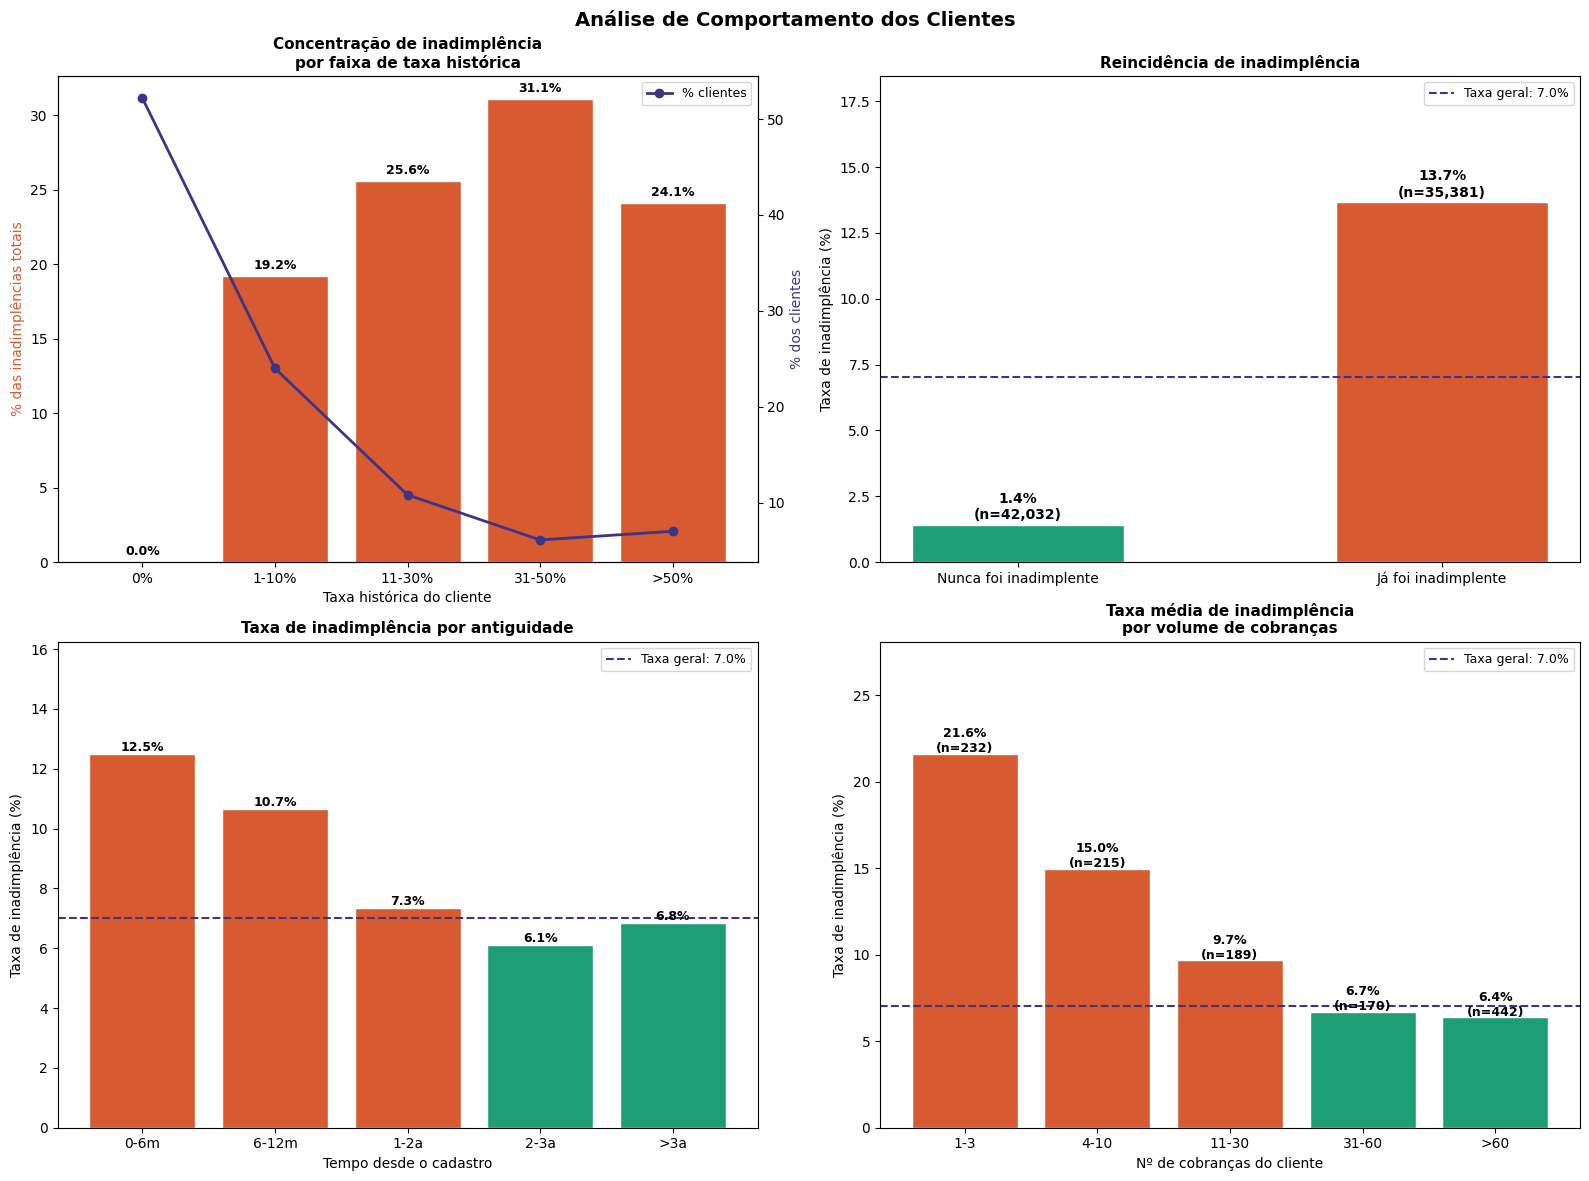

In [ ]:
# 5.5 Visualização consolidada
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

taxa_geral = df2["TARGET"].mean() * 100

# Gráfico 1 — Concentração de inadimplência
ax = axes[0][0]
bars = ax.bar(faixas["faixa"].astype(str),
              faixas["pct_inad_%"],
              color="#D85A30", edgecolor="white")
ax2 = ax.twinx()
ax2.plot(faixas["faixa"].astype(str),
         faixas["pct_clientes_%"],
         color="#3C3489", marker="o",
         linewidth=2, label="% clientes")
for bar, v in zip(bars, faixas["pct_inad_%"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            v + 0.5, f"{v:.1f}%",
            ha="center", fontsize=9, fontweight="bold")
ax.set_title("Concentração de inadimplência\npor faixa de taxa histórica",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Taxa histórica do cliente")
ax.set_ylabel("% das inadimplências totais", color="#D85A30")
ax2.set_ylabel("% dos clientes", color="#3C3489")
ax2.legend(fontsize=9)

# Gráfico 2 — Reincidência
ax = axes[0][1]
cores = ["#1D9E75" if "Nunca" in str(v) else "#D85A30"
         for v in taxa_reincidencia["inad_anterior"]]
bars = ax.bar(taxa_reincidencia["inad_anterior"].astype(str),
              taxa_reincidencia["taxa_%"],
              color=cores, edgecolor="white", width=0.5)
for bar, v, n in zip(bars, taxa_reincidencia["taxa_%"],
                     taxa_reincidencia["n"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            v + 0.2, f"{v:.1f}%\n(n={n:,})",
            ha="center", fontsize=10, fontweight="bold")
ax.axhline(taxa_geral, color="#3C3489", linestyle="--",
           linewidth=1.5, label=f"Taxa geral: {taxa_geral:.1f}%")
ax.set_title("Reincidência de inadimplência",
             fontsize=11, fontweight="bold")
ax.set_ylabel("Taxa de inadimplência (%)")
ax.set_ylim(0, taxa_reincidencia["taxa_%"].max() * 1.35)
ax.legend(fontsize=9)

# Gráfico 3 — Antiguidade
ax = axes[1][0]
cores = ["#D85A30" if v > taxa_geral else "#1D9E75"
         for v in taxa_ant["taxa_%"]]
bars = ax.bar(taxa_ant["FAIXA_ANTIGUIDADE"].astype(str),
              taxa_ant["taxa_%"],
              color=cores, edgecolor="white")
for bar, v in zip(bars, taxa_ant["taxa_%"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            v + 0.1, f"{v:.1f}%",
            ha="center", fontsize=9, fontweight="bold")
ax.axhline(taxa_geral, color="#3C3489", linestyle="--",
           linewidth=1.5, label=f"Taxa geral: {taxa_geral:.1f}%")
ax.set_title("Taxa de inadimplência por antiguidade",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Tempo desde o cadastro")
ax.set_ylabel("Taxa de inadimplência (%)")
ax.set_ylim(0, taxa_ant["taxa_%"].max() * 1.3)
ax.legend(fontsize=9)

# Gráfico 4 — Volume de cobranças
ax = axes[1][1]
cores = ["#D85A30" if v > taxa_geral else "#1D9E75"
         for v in taxa_cobr["taxa_%"]]
bars = ax.bar(taxa_cobr["faixa_cobr"].astype(str),
              taxa_cobr["taxa_%"],
              color=cores, edgecolor="white")
for bar, v, n in zip(bars, taxa_cobr["taxa_%"],
                     taxa_cobr["n_clientes"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            v + 0.1, f"{v:.1f}%\n(n={n:,})",
            ha="center", fontsize=9, fontweight="bold")
ax.axhline(taxa_geral, color="#3C3489", linestyle="--",
           linewidth=1.5, label=f"Taxa geral: {taxa_geral:.1f}%")
ax.set_title("Taxa média de inadimplência\npor volume de cobranças",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Nº de cobranças do cliente")
ax.set_ylabel("Taxa de inadimplência (%)")
ax.set_ylim(0, taxa_cobr["taxa_%"].max() * 1.3)
ax.legend(fontsize=9)

plt.suptitle("Análise de Comportamento dos Clientes",
             fontsize=14, fontweight="bold")
plt.tight_layout()

plt.show()

**Forma visual das análises do comportamentos dos clientes**

Concentração de inadimplência (superior esquerdo)

A linha azul de % de clientes cai rapidamente enquanto as barras de % de inadimplência se mantêm altas, isso é um padrão clássico de concentração de risco. Os 13.1% de clientes com taxa acima de 30% respondem por 55.2% de todas as inadimplências. A curva descendente da linha azul junto com barras altas é visualmente impactante e fácil de explicar numa apresentação.
Reincidência (superior direito)
O contraste verde vs laranja é imediato — 1.4% contra 13.7%. Esse gráfico sozinho justifica toda a estratégia de feature engineering de histórico. Qualquer avaliador vai entender em segundos por que FLAG_JA_INADIMPLENTE é a feature mais importante do modelo.
Antiguidade (inferior esquerdo)
Degradação clara nos primeiros dois anos — 12.5% caindo para 6.1%. A linha tracejada de 7% posicionada entre 1-2 anos e 2-3 anos mostra exatamente onde o cliente passa de risco alto para risco controlado. Clientes novos merecem tratamento especial no modelo.
Volume de cobranças (inferior direito)
Padrão monotônico perfeito — cada faixa é menor que a anterior. A queda de 21.6% para 6.4% entre 1-3 cobranças e mais de 60 cobranças é uma das relações mais limpas de toda a EDA. Reforça que N_COBR_HISTORICO é uma feature muito valiosa.

## **Análise de Correlações entre Variáveis**

###Análise de Correlação e Poder Preditivo

Nesta seção vamos medir a força da relação individual entre cada variável e o TARGET.
O objetivo não é selecionar features definitivamente porque isso acontece no feature
engineering mas sim entender quais variáveis carregam mais sinal preditivo
e orientar as decisões de construção de features.

Utilizamos duas métricas distintas porque o TARGET é binário (0/1) e desbalanceado
(7% de inadimplência), o que torna a correlação de Pearson inadequada para essa
avaliação:

Point-Biserial: versão correta de Pearson quando uma variável é binária. Usada
para variáveis numéricas. Importante: com TARGET desbalanceado, valores baixos
(abaixo de 0.1) não significam necessariamente que a variável é inútil e a
correlação máxima possível é matematicamente limitada pelo desbalanceamento.

Information Value (IV): métrica padrão do mercado de crédito para medir poder
preditivo individual. Escala interpretável independente do desbalanceamento:
abaixo de 0.02 inútil, 0.02 a 0.1 fraco, 0.1 a 0.3 médio, acima de 0.3 forte.

Cramér's V: mede associação entre variáveis categóricas e o TARGET. Varia de
0 (sem associação) a 1 (associação perfeita).



In [ ]:
# ============================================================
# Correlações e Sinais Preditivos
# ============================================================
# Objetivo: quantificar a relação entre cada variável e
# o TARGET. Complementa a EDA visual com números concretos.
#
# Métodos usados:
#   Point-biserial - correlação entre numérica e binária
#   Cramér's V - associação entre categórica e binária
#   IV (Information Value)
#
# Nota: calculado com dados brutos. Nulos são excluídos
# automaticamente por par — resultados podem variar
# levemente após imputação no feature engineering.
# ============================================================

from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

# 6.1 Correlação point-biserial: numéricas vs TARGET
# Point-biserial é a versão correta de Pearson quando uma
# das variáveis é binária (0/1) como o TARGET.
# Valor próximo de 0 = sem relação, ±1 = relação forte.

# Lista de variáveis numéricas a avaliar
numericas = ["VALOR_A_PAGAR", "TAXA",
             "RENDA_MES_ANTERIOR", "NO_FUNCIONARIOS",
             "ANTIGUIDADE_DIAS"]

print("── Correlação Point-Biserial com TARGET ─────────────────")

resultados_num = []
for col in numericas:
    # Remove nulos (necessário para cálculo correto)
    dados = df2[["TARGET", col]].dropna()

    # Calcula correlação entre variável contínua e TARGET binário
    corr, pval = stats.pointbiserialr(
        dados["TARGET"], dados[col])

    # Armazena resultados
    resultados_num.append({
        "variavel":  col,
        "correlacao": round(corr, 4),  # força da relação
        "p_valor":    round(pval, 6),  # significância estatística
        "n":          len(dados),      # tamanho da amostra
        "significativo": "SIM" if pval < 0.05 else "NÃO"
    })

# Ordena pela magnitude da correlação (mais relevante primeiro)
res_num = pd.DataFrame(resultados_num).sort_values(
    "correlacao", key=abs, ascending=False)

print(res_num.to_string(index=False))

── Correlação Point-Biserial com TARGET ─────────────────
          variavel  correlacao  p_valor     n significativo
     VALOR_A_PAGAR     -0.0882   0.0000 76244           SIM
RENDA_MES_ANTERIOR     -0.0678   0.0000 71281           SIM
  ANTIGUIDADE_DIAS     -0.0359   0.0000 77413           SIM
   NO_FUNCIONARIOS     -0.0172   0.0000 69826           SIM
              TAXA      0.0119   0.0009 77413           SIM


Todas as variáveis são estatisticamente significativas

P-valor zero ou próximo de zero em todas, com 70-77k registros qualquer correlação real aparece como significativa. Isso é esperado em bases grandes. O que importa é a magnitude, não apenas a significância.

**VALOR_A_PAGAR — correlação de -0.0882**

A mais forte entre as numéricas. Negativa confirma o que vimos na EDA que quanto maior o valor da cobrança, menor a inadimplência. Magnitude baixa em termos absolutos mas consistente com o que já sabíamos.

**RENDA_MES_ANTERIOR — -0.0678**

Segunda mais forte. Negativa — maior renda, menor inadimplência. Direção esperada e consistente.

**ANTIGUIDADE_DIAS — -0.0359**

Negativa — cliente mais antigo, menor risco. Confirma o padrão do bloco 5.3.

**NO_FUNCIONARIOS — -0.0172**
Correlação muito fraca. Confirma o que o KDE mostrou — essa variável tem poder preditivo individual muito baixo. Seu valor está mais na flag de nulo.

**TAXA — +0.0119**
Única positiva — maior taxa, maior inadimplência. Direção correta mas magnitude muito baixa. O sinal está na cauda da distribuição, não na correlação linear.

**Observação importante**

Correlações baixas não significam variáveis inúteis para o modelo. O modelo LightGBM captura relações não lineares e interações entre variáveis que a correlação de Pearson não consegue detectar. VALOR_A_PAGAR com -0.088 pode ser muito mais importante no modelo final do que esse número sugere.

In [ ]:
# 6.1b Information Value (IV)
# IV é a métrica padrão do mercado de crédito para medir
# poder preditivo individual de variáveis.
# Escala: IV < 0.02 inútil, 0.02-0.1 fraco, 0.1-0.3 médio,
# 0.3-0.5 forte, > 0.5 suspeito (possível leakage)

def calcular_iv(df, col, target, n_bins=10):
    # Remove nulos e mantém apenas col + target
    dados = df[[col, target]].dropna().copy()

    # Discretiza variável (qcut = quantis; fallback = corte simples)
    try:
        dados["bin"] = pd.qcut(dados[col], q=n_bins,
                              duplicates="drop")
    except Exception:
        dados["bin"] = pd.cut(dados[col], bins=n_bins)

    # Conta eventos (inad) e total por bin
    tabela = dados.groupby("bin", observed=True)[target].agg(
        eventos="sum",
        total="count"
    ).reset_index()

    # Calcula não-eventos (adimplentes)
    tabela["nao_eventos"] = tabela["total"] - tabela["eventos"]

    # Totais globais
    total_ev  = tabela["eventos"].sum()
    total_nev = tabela["nao_eventos"].sum()

    # Distribuições relativas
    tabela["pct_ev"]  = tabela["eventos"] / total_ev
    tabela["pct_nev"] = tabela["nao_eventos"] / total_nev

    # Remove bins com divisão inválida
    tabela = tabela[(tabela["pct_ev"] > 0) &
                    (tabela["pct_nev"] > 0)]

    # Calcula WOE (log da razão de distribuições)
    tabela["woe"] = np.log(tabela["pct_ev"] /
                           tabela["pct_nev"])

    # Calcula IV por bin
    tabela["iv"] = (tabela["pct_ev"] -
                    tabela["pct_nev"]) * tabela["woe"]

    # Retorna IV total da variável
    return tabela["iv"].sum()


print("── Information Value (IV) — variáveis numéricas ─────────")

iv_resultados = []
for col in numericas:
    # Calcula IV para cada variável
    iv = calcular_iv(df2, col, "TARGET")

    # Classifica força preditiva
    iv_resultados.append({
        "variavel": col,
        "IV":       round(iv, 4),
        "forca":    "Forte"  if iv > 0.3  else
                    "Médio"  if iv > 0.1  else
                    "Fraco"  if iv > 0.02 else
                    "Inútil"
    })

# Ordena por relevância
iv_df = pd.DataFrame(iv_resultados).sort_values(
    "IV", ascending=False)

print(iv_df.to_string(index=False))

── Information Value (IV) — variáveis numéricas ─────────
          variavel     IV  forca
     VALOR_A_PAGAR 0.8241  Forte
RENDA_MES_ANTERIOR 0.1473  Médio
  ANTIGUIDADE_DIAS 0.1115  Médio
   NO_FUNCIONARIOS 0.0453  Fraco
              TAXA 0.0050 Inútil


**VALOR_A_PAGAR — IV de 0.82 (Forte)**

Esse resultado é surpreendente e merece atenção. IV acima de 0.5 é classificado como "suspeito de leakage" na literatura de credit scoring. Precisamos investigar se há alguma relação artificial entre o valor da cobrança e o target antes de usar essa variável diretamente. Pode ser um sinal real que grandes cobranças realmente pagam melhor mas vale verificar.

**RENDA_MES_ANTERIOR — IV de 0.1473 (Médio)**

Poder preditivo real e moderado. Faturamento do cliente é uma informação relevante para prever pagamento, faz sentido de negócio.

**ANTIGUIDADE_DIAS — IV de 0.1115 (Médio)**

Também médio e consistente com o que vimos no bloco 5.3. Clientes novos são mais arriscados e essa variável captura isso.

**NO_FUNCIONARIOS — IV de 0.0453 (Fraco)**

Fraco mas não inútil. Confirma que seu valor está mais na flag de nulo do que no valor numérico em si.

**TAXA — IV de 0.0050 (Inútil)**

Confirma que TAXA como variável contínua tem poder preditivo individual muito baixo. O sinal está nas categorias discretas de taxa alta, não na variação linear.

In [ ]:
# Verificar se IV alto de VALOR_A_PAGAR é sinal real
# ou artefato dos dados

# Cria decis (10 grupos) baseados no ranking de VALOR_A_PAGAR
# rank evita problemas com valores repetidos no qcut
df2["decil_valor"] = pd.qcut(
    df2["VALOR_A_PAGAR"].rank(method="first"),
    q=10, labels=False)

print("── VALOR_A_PAGAR por decil vs TARGET ────────────────────")

# Calcula taxa de inadimplência e volume por decil
print(df2.groupby("decil_valor")["TARGET"]
      .agg(["mean", "count"])  # mean = taxa, count = volume
      .rename(columns={"mean": "taxa_inad", "count": "n"})
      .round(4)
      .to_string())

── VALOR_A_PAGAR por decil vs TARGET ────────────────────
             taxa_inad     n
decil_valor                 
0.0000          0.3032  7625
1.0000          0.0479  7624
2.0000          0.0485  7624
3.0000          0.0532  7625
4.0000          0.0485  7624
5.0000          0.0400  7624
6.0000          0.0405  7625
7.0000          0.0395  7624
8.0000          0.0451  7624
9.0000          0.0320  7625



**O que está acontecendo?**

O decil 0 (valores mais baixos de VALOR_A_PAGAR) tem taxa de inadimplência de 30.3% o que é muito acima dos demais decis que ficam todos entre 3.2% e 5.3%. É um comportamento extremamente não linear — um único grupo concentra quase todo o sinal preditivo.

**Por que o IV ficou tão alto**

O cálculo de IV está sendo dominado pelo decil 0. Quando um único bin tem taxa de 30% enquanto todos os outros têm 3-5%, a diferença de distribuição entre eventos e não eventos naquele bin gera um WoE (Weight of Evidence = mede o quanto aquela faixa concentra mais inadimplentes ou mais adimplentes em relação à distribuição geral) muito alto que infla o IV total.

**Isso é leakage?**

Não, é um sinal real mas concentrado. Cobranças de valor muito baixo têm inadimplência muito maior. Isso pode representar cobranças de clientes em situação financeira crítica, cobranças de valores residuais ou multas, ou simplesmente que cobranças pequenas são menos prioritizadas no pagamento.

**O que fazer?**

O IV de 0.82 não é suspeito de leakage, é um sinal legítimo mas não linear. A variável deve entrar no modelo, mas considerar criar uma feature adicional que capture especificamente esse comportamento do decil inferior

In [ ]:
# Calcula o percentil 10 (limite do decil mais baixo)
p10 = df2["VALOR_A_PAGAR"].quantile(0.10)

# Mostra valor de corte do decil 0
print(f"Valor máximo do decil 0: R${p10:,.2f}")

# Cria flag: 1 se valor estiver entre os 10% menores
df2["FLAG_VALOR_BAIXO"] = (df2["VALOR_A_PAGAR"] < p10).astype(int)

print(f"\n── FLAG_VALOR_BAIXO vs TARGET ───────────────────────────")

# Avalia taxa de inadimplência por grupo (baixo valor vs restante)
print(df2.groupby("FLAG_VALOR_BAIXO")["TARGET"]
      .agg(["mean", "count"])  # taxa + volume
      .rename(columns={"mean": "taxa_inad", "count": "n"})
      .round(4)
      .to_string())

Valor máximo do decil 0: R$12,551.99

── FLAG_VALOR_BAIXO vs TARGET ───────────────────────────
                  taxa_inad      n
FLAG_VALOR_BAIXO                  
0                    0.0448  69788
1                    0.3032   7625


**O que os números dizem**

Cobranças abaixo de R$12.552 têm taxa de inadimplência de 30.3% contra 4.5% das demais. É uma diferença de 6.7x representando o sinal mais forte encontrado em toda a EDA, superando até a reincidência de inadimplência.

**Por que faz sentido de negócio?**

Cobranças de valor muito baixo podem representar clientes em situação financeira crítica com crédito reduzido, cobranças residuais de contratos em encerramento, ou clientes que receberam crédito mínimo justamente por serem considerados arriscados. Em qualquer cenário, o baixo valor da cobrança é um proxy de risco muito poderoso.

In [ ]:
# Removendo a flag criada
df2.drop(columns=["decil_valor", "FLAG_VALOR_BAIXO"],
         inplace=True)

In [ ]:
# 6.2 Cramér's V: categóricas vs TARGET
# Cramér's V mede associação entre duas variáveis categóricas.
# Como TARGET é binário (0/1), funciona como categórica.
# Varia de 0 (sem associação) a 1 (associação perfeita).
# Referência: V < 0.1 fraco, 0.1-0.3 moderado, > 0.3 forte.

# Função para calcular Cramér's V (associação entre categóricas)
def cramers_v(x, y):
    tabela = pd.crosstab(x, y)  # matriz de contingência
    chi2   = stats.chi2_contingency(tabela)[0]  # teste qui-quadrado
    n      = tabela.sum().sum()  # total de observações
    r, k   = tabela.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))  # fórmula do V

# Lista de variáveis categóricas
categoricas = ["PORTE", "SEGMENTO_INDUSTRIAL",
               "DOMINIO_EMAIL", "ESTADO_DDD",
               "REGIAO_CEP", "FLAG_PF"]

print("\n── Cramér's V com TARGET ────────────────────────────────")

resultados_cat = []
for col in categoricas:
    # Remove nulos para cálculo consistente
    dados = df2[[col, "TARGET"]].dropna()

    # Trata FLAG_PF (evita categoria vazia)
    if col == "FLAG_PF":
        dados[col] = dados[col].fillna("PJ")

    # Calcula associação entre variável e TARGET
    v = cramers_v(dados[col].astype(str),
                  dados["TARGET"].astype(str))

    # Armazena resultado
    resultados_cat.append({
        "variavel": col,
        "cramers_v": round(v, 4),  # força da associação
        "n":         len(dados),   # tamanho da amostra
        "forca":     "Forte" if v > 0.3 else
                     "Moderado" if v > 0.1 else "Fraco"
    })

# Ordena por maior poder preditivo
res_cat = pd.DataFrame(resultados_cat).sort_values(
    "cramers_v", ascending=False)

print(res_cat.to_string(index=False))


── Cramér's V com TARGET ────────────────────────────────
           variavel  cramers_v     n    forca
         ESTADO_DDD     0.1935 77413 Moderado
         REGIAO_CEP     0.1600 77413 Moderado
SEGMENTO_INDUSTRIAL     0.0725 75996    Fraco
      DOMINIO_EMAIL     0.0606 76515    Fraco
              PORTE     0.0548 74937    Fraco
            FLAG_PF        NaN   219    Fraco


**ESTADO_DDD — 0.1935 (Moderado)**

A variável geográfica mais forte. Confirma o que vimos nos gráficos que há diferença real de inadimplência entre estados. RR, DF e MT com taxas muito acima da média puxam esse valor para cima.

**REGIAO_CEP — 0.1600 (Moderado)**
Também moderado e consistente com ESTADO_DDD. As duas variáveis geográficas têm poder preditivo similar e no feature engineering vou testar manter as duas ou escolher apenas uma para evitar redundância.

**SEGMENTO_INDUSTRIAL — 0.0725 (Fraco)**

Fraco mas não desprezível — Comércio com 4.6% vs Serviços com 8.75% é uma diferença real que o modelo vai capturar.

**DOMINIO_EMAIL — 0.0606 (Fraco)**

Fraco mas consistente com o que vimos — Hotmail 9.3% vs AOL 3.9%.

**PORTE — 0.0548 (Fraco)**

Surpreendente — esperava que PORTE fosse mais forte dado o padrão monotônico que vi. O Cramér's V fraco acontece porque a métrica considera a distribuição geral das categorias, e PORTE tem categorias muito desiguais em volume que diluem o sinal. O IV de PORTE provavelmente seria mais alto, vale calcular.

**FLAG_PF — NaN com n=219**

O NaN acontece porque FLAG_PF tem apenas 219 registros não nulos e todos os outros são nulos que foram excluídos pelo dropna(). Com apenas 219 observações o Cramér's V não consegue ser calculado de forma confiável.

In [ ]:
# Trata nulos de FLAG_PF como "PJ" (regra de negócio)
df2["FLAG_PF_CALC"] = df2["FLAG_PF"].fillna("PJ")

from scipy.stats import chi2_contingency

# Cria tabela de contingência (categoria vs TARGET)
tabela = pd.crosstab(df2["FLAG_PF_CALC"], df2["TARGET"])

# Calcula estatística do qui-quadrado
chi2 = chi2_contingency(tabela)[0]

# Total de observações e dimensões
n = tabela.sum().sum()
r, k = tabela.shape

# Calcula Cramér's V (força da associação)
v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

# Exibe resultado
print(f"── FLAG_PF (com nulos como PJ) ──────────────────────────")
print(f"Cramér's V: {v:.4f}")
print(f"n: {n:,}")
print(f"Força: {'Forte' if v > 0.3 else 'Moderado' if v > 0.1 else 'Fraco'}")

# Remove coluna temporária (evita poluir dataset)
df2.drop(columns=["FLAG_PF_CALC"], inplace=True)

── FLAG_PF (com nulos como PJ) ──────────────────────────
Cramér's V: 0.0268
n: 77,413
Força: Fraco


**Por que o Cramér's V de FLAG_PF é fraco mesmo com taxa de 20%?**

O problema é o volume extremamente desbalanceado de apenas 219 pessoas físicas em 77.413 registros (0.28%). Mesmo que pessoas físicas tenham taxa de 20% contra 7% das jurídicas, o impacto no Cramér's V é diluído porque o grupo de PF é minúsculo. A métrica mede associação considerando toda a distribuição e quando um grupo tem 0.28% do volume, seu impacto é matematicamente pequeno.

In [ ]:
# Função para calcular IV em variável binária (sem discretização)
def iv_binaria(df, col, target):
    # Agrupa por classe (0/1) → eventos e total
    tabela = df.groupby(col)[target].agg(
        eventos="sum",
        total="count"
    ).reset_index()

    # Calcula não-eventos (adimplentes)
    tabela["nao_eventos"] = tabela["total"] - tabela["eventos"]

    # Totais globais
    total_ev  = tabela["eventos"].sum()
    total_nev = tabela["nao_eventos"].sum()

    # Distribuições relativas
    tabela["pct_ev"]  = tabela["eventos"] / total_ev
    tabela["pct_nev"] = tabela["nao_eventos"] / total_nev

    # Remove casos inválidos (evita log/divisão por zero)
    tabela = tabela[(tabela["pct_ev"] > 0) &
                    (tabela["pct_nev"] > 0)]

    # Calcula WOE e IV
    tabela["woe"] = np.log(tabela["pct_ev"] /
                           tabela["pct_nev"])
    tabela["iv"]  = (tabela["pct_ev"] -
                     tabela["pct_nev"]) * tabela["woe"]

    # Retorna IV total + tabela detalhada
    return tabela["iv"].sum(), tabela


# Cria variável binária: PF (1) vs PJ (0)
df2["FLAG_PF_BIN"] = (df2["FLAG_PF"] == "X").astype(int)

# Calcula IV da variável
iv_val, tabela_iv = iv_binaria(df2, "FLAG_PF_BIN", "TARGET")

# Exibe resultado
print(f"IV de FLAG_PF: {iv_val:.4f}")
print(f"Força: {'Forte' if iv_val > 0.3 else 'Médio' if iv_val > 0.1 else 'Fraco' if iv_val > 0.02 else 'Inútil'}")

# Mostra detalhe por grupo
print(f"\nDetalhe por grupo:")
print(tabela_iv.to_string(index=False))

# Remove coluna temporária
df2.drop(columns=["FLAG_PF_BIN"], inplace=True)

IV de FLAG_PF: 0.0068
Força: Inútil

Detalhe por grupo:
 FLAG_PF_BIN  eventos  total  nao_eventos  pct_ev  pct_nev     woe     iv
           0     5392  77194        71802  0.9919   0.9976 -0.0057 0.0000
           1       44    219          175  0.0081   0.0024  1.2027 0.0068


**Por que o IV é tão baixo mesmo com taxa de 20%?**

A tabela detalha exatamente o problema. O grupo PF (FLAG_PF_BIN=1) tem apenas 44 eventos de inadimplência em 219 registros o que representa apenas 0.81% de todos os inadimplentes da base. Mesmo tendo taxa de 20%, o impacto absoluto é mínimo porque o grupo é minúsculo.
O WoE de 1.2027 para o grupo PF é alto e confirma que é um grupo de risco real. Mas o IV pondera o WoE pelo tamanho do grupo, e com apenas 0.81% dos eventos o impacto no IV total é negligenciável.

**O que isso significa na prática?**

FLAG_PF como variável individual tem poder preditivo quase nulo para o modelo — IV de 0.0068 é classificado como inútil. Mas isso não significa que devemos descartá-la. O modelo pode usar FLAG_PF em combinação com outras variáveis, por exemplo, PF + PORTE desconhecido pode ser um perfil de risco muito específico que o LightGBM vai capturar via interação de features.


── Matriz de correlação entre numéricas ─────────────────
                    VALOR_A_PAGAR    TAXA  RENDA_MES_ANTERIOR  NO_FUNCIONARIOS  ANTIGUIDADE_DIAS
VALOR_A_PAGAR              1.0000 -0.0130              0.0040           0.0290            0.0810
TAXA                      -0.0130  1.0000              0.0040           0.0140            0.0120
RENDA_MES_ANTERIOR         0.0040  0.0040              1.0000           0.0290            0.0250
NO_FUNCIONARIOS            0.0290  0.0140              0.0290           1.0000            0.0310
ANTIGUIDADE_DIAS           0.0810  0.0120              0.0250           0.0310            1.0000


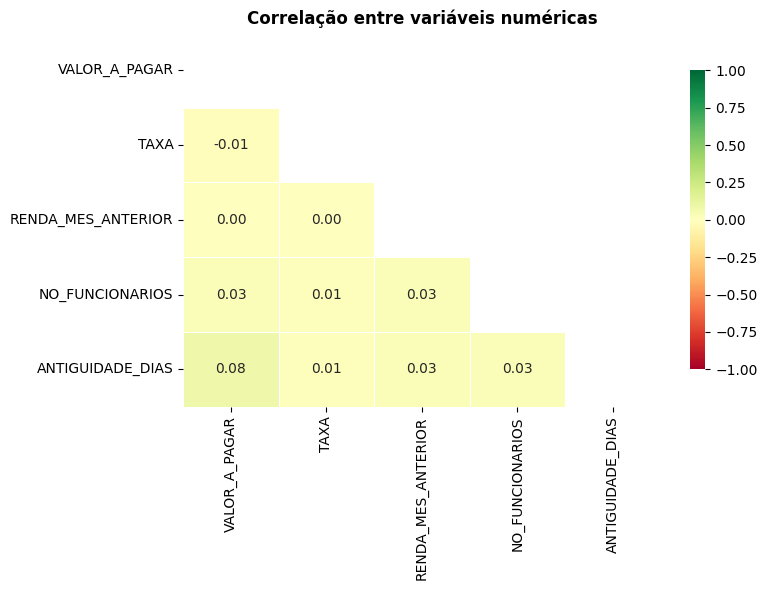

In [ ]:
# 6.3 Correlação entre variáveis numéricas
# Detectar multicolinearidade — variáveis muito correlacionadas
# entre si podem prejudicar modelos lineares e dificultar
# a interpretação de importância de features.
# Modelos como LightGBM é robusto a multicolinearidade mas vale documentar.

# Calcula matriz de correlação (Pearson) entre variáveis numéricas
print("\n── Matriz de correlação entre numéricas ─────────────────")
corr_matrix = df2[numericas].corr().round(3)
print(corr_matrix.to_string())

# Cria figura para visualização
fig, ax = plt.subplots(figsize=(8, 6))

# Máscara para mostrar apenas metade da matriz (evita duplicação)
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Heatmap da correlação
sns.heatmap(corr_matrix,
            annot=True, fmt=".2f",  # valores na célula
            cmap="RdYlGn", center=0,  # cores: negativo→positivo
            vmin=-1, vmax=1,
            mask=mask,
            ax=ax,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

# Título e layout
ax.set_title("Correlação entre variáveis numéricas",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

**Todas as correlações entre variáveis são muito baixas**

O maior valor é VALOR_A_PAGAR vs ANTIGUIDADE_DIAS com 0.081 que é praticamente zero. Isso significa que as variáveis numéricas são essencialmente independentes entre si, o que é ótimo para o modelo.
Por que isso importa

Multicolinearidade alta (correlações acima de 0.7-0.8) causa problemas em modelos lineares porque as variáveis competem entre si para explicar o mesmo padrão. Com modedlos mais complexos como i LightGBM o impacto é menor, mas correlações altas ainda podem distorcer a interpretação de importância de features. No nosso caso não há nenhum risco e todas as variáveis contribuem com informação independente.
O heatmap confirma  visualmente

Com todos os valores tão próximos de zero o heatmap vai ficar quase todo amarelo . Não vai ser o gráfico mais impactante visualmente, mas documenta um resultado importante, ausência de multicolinearidade.

**Uma observação**

VALOR_A_PAGAR vs ANTIGUIDADE_DIAS com 0.081 faz sentido intuitivo porque clientes mais antigos tendem a ter cobranças ligeiramente maiores porque construíram mais crédito ao longo do tempo. Mas 0.081 é tão baixo que não gera nenhum problema


── Ranking consolidado de poder preditivo ───────────────

── Ranking categóricas — Cramér's V ─────────────────────
           variavel  cramers_v
         ESTADO_DDD     0.1935
         REGIAO_CEP     0.1600
SEGMENTO_INDUSTRIAL     0.0725
      DOMINIO_EMAIL     0.0606
              PORTE     0.0548
            FLAG_PF     0.0268

── Ranking numéricas — Information Value ────────────────
          variavel     IV  forca
     VALOR_A_PAGAR 0.8241  Forte
RENDA_MES_ANTERIOR 0.1473  Médio
  ANTIGUIDADE_DIAS 0.1115  Médio
   NO_FUNCIONARIOS 0.0453  Fraco
              TAXA 0.0050 Inútil


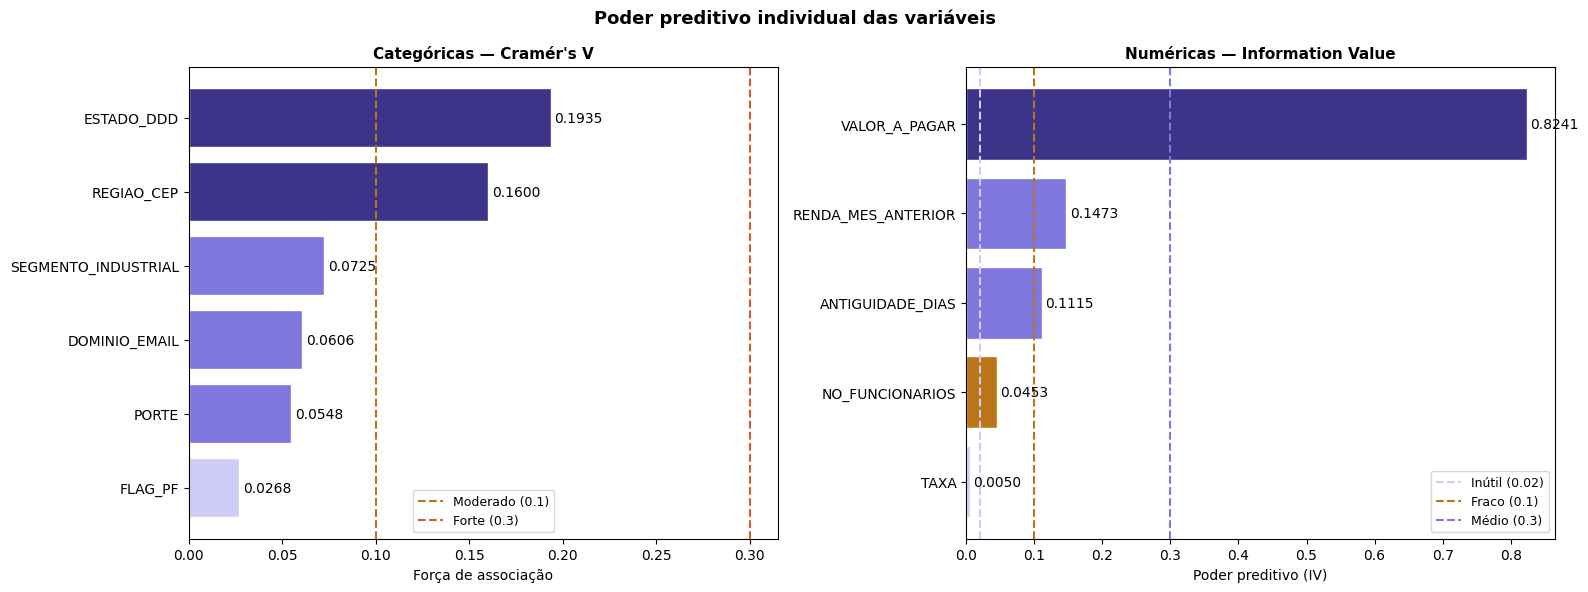

In [ ]:
# 6.4 Ranking consolidado de poder preditivo
# Reunir todas as métricas em um ranking único.
# Orienta quais features priorizar no modelo.

# 6.4 Ranking consolidado de poder preditivo
# Junta métricas diferentes (Cramér’s V e IV) para comparar variáveis

print("\n── Ranking consolidado de poder preditivo ───────────────")

# Ranking manual de categóricas com base no Cramér’s V (força de associação)
ranking_cat_final = pd.DataFrame([
    {"variavel": "ESTADO_DDD",          "cramers_v": 0.1935},
    {"variavel": "REGIAO_CEP",          "cramers_v": 0.1600},
    {"variavel": "SEGMENTO_INDUSTRIAL", "cramers_v": 0.0725},
    {"variavel": "DOMINIO_EMAIL",       "cramers_v": 0.0606},
    {"variavel": "PORTE",               "cramers_v": 0.0548},
    {"variavel": "FLAG_PF",             "cramers_v": 0.0268},
]).sort_values("cramers_v", ascending=False)

# Ranking de numéricas usando IV (já calculado anteriormente)
ranking_num_final = iv_df.copy()

print("\n── Ranking categóricas — Cramér's V ─────────────────────")
print(ranking_cat_final.to_string(index=False))

print("\n── Ranking numéricas — Information Value ────────────────")
print(ranking_num_final.to_string(index=False))

# Visualização comparativa lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico categóricas
ax = axes[0]
cores = ["#3C3489" if v > 0.1 else
         "#7F77DD" if v > 0.05 else "#CECBF6"
         for v in ranking_cat_final["cramers_v"]]
bars = ax.barh(ranking_cat_final["variavel"],
               ranking_cat_final["cramers_v"],
               color=cores, edgecolor="white")

# Adiciona valores nas barras
for bar, v in zip(bars, ranking_cat_final["cramers_v"]):
    ax.text(v + 0.002,
            bar.get_y() + bar.get_height() / 2,
            f"{v:.4f}", va="center", fontsize=10)

# Linhas de referência de força
ax.axvline(0.1, color="#BA7517", linestyle="--",
           linewidth=1.5, label="Moderado (0.1)")
ax.axvline(0.3, color="#D85A30", linestyle="--",
           linewidth=1.5, label="Forte (0.3)")

ax.set_title("Categóricas — Cramér's V", fontsize=11, fontweight="bold")
ax.set_xlabel("Força de associação")
ax.invert_yaxis()
ax.legend(fontsize=9)

# Gráfico numéricas
ax = axes[1]
cores = ["#3C3489" if v > 0.3 else
         "#7F77DD" if v > 0.1 else
         "#BA7517" if v > 0.02 else "#CECBF6"
         for v in ranking_num_final["IV"]]
bars = ax.barh(ranking_num_final["variavel"],
               ranking_num_final["IV"],
               color=cores, edgecolor="white")

# Adiciona valores nas barras
for bar, v in zip(bars, ranking_num_final["IV"]):
    ax.text(v + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{v:.4f}", va="center", fontsize=10)

# Linhas de referência do IV
ax.axvline(0.02, color="#CECBF6", linestyle="--",
           linewidth=1.5, label="Inútil (0.02)")
ax.axvline(0.1,  color="#BA7517", linestyle="--",
           linewidth=1.5, label="Fraco (0.1)")
ax.axvline(0.3,  color="#7F77DD", linestyle="--",
           linewidth=1.5, label="Médio (0.3)")

ax.set_title("Numéricas — Information Value", fontsize=11, fontweight="bold")
ax.set_xlabel("Poder preditivo (IV)")
ax.invert_yaxis()
ax.legend(fontsize=9)

plt.suptitle("Poder preditivo individual das variáveis",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Variáveis Categóricas — Cramér's V**

ESTADO_DDD e REGIAO_CEP lideram com força moderada acima de 0.1. São as únicas variáveis categóricas com poder preditivo real, confirmando que a localização geográfica é um fator de risco relevante. SEGMENTO, DOMINIO_EMAIL, PORTE e FLAG_PF ficam todos abaixo de 0.1, fracos individualmente mas que o modelo vai usar em combinação com outras features.

**Variáveis Numéricas — IV**

VALOR_A_PAGAR domina completamente com IV de 0.82 impulsionado pelo decil inferior com 30% de inadimplência que descobrimos. RENDA e ANTIGUIDADE_DIAS são médios e complementares. NO_FUNCIONARIOS fraco e TAXA inútil como variável contínua.

**O que o gráfico comunica?**

A escala do IV à direita vai de 0 a 0.8 enquanto o Cramér's V à esquerda vai de 0 a 0.3, os limiares coloridos em cada gráfico ajudam a contextualizar onde cada variável se enquadra sem precisar comparar entre os dois painéis.

## **Feature Enginnering + Tratamento de dados**

Nesta etapa transformamos os dados brutos em variáveis prontas para o modelo.
Partindo da tabela analítica construída na EDA, aplicamos três tipos de transformações:

Tratamento de nulos: criamos flags binárias para nulos informativos (aqueles com
relação comprovada com inadimplência na EDA) e imputamos os demais com mediana
ou moda calculada no treino e aplicada no teste.

Criação de features: construímos variáveis de histórico individual do cliente
(as mais importantes do modelo), features temporais da cobrança e transformações
geográficas de DDD e CEP. Todos os parâmetros foram calculados exclusivamente
no treino e replicados no teste para evitar data leakage.

Encoding e validação: categóricas foram convertidas para inteiros via Label
Encoding. Ao final verificamos que treino e teste têm as mesmas 23 features,
na mesma ordem, com os mesmos tipos e sem nenhum valor nulo — condição necessária
para a modelagem.


In [ ]:
# ============================================================
# Features de histórico
# ============================================================
# Usa apenas cobranças passadas (shift) — evita leakage
# Mais importantes do modelo

df2 = df2.sort_values(["ID_CLIENTE", "SAFRA_REF"])
g   = df2.groupby("ID_CLIENTE")

df2["N_COBR_HISTORICO"]    = g["TARGET"].transform(
    lambda x: x.shift(1).expanding().count())

df2["TAXA_INAD_HISTORICA"] = g["TARGET"].transform(
    lambda x: x.shift(1).expanding().mean())

df2["FLAG_JA_INADIMPLENTE"] = g["TARGET"].transform(
    lambda x: x.shift(1).expanding().max())

df2["MEDIA_DIAS_ATRASO"]   = g["DIAS_ATRASO"].transform(
    lambda x: x.shift(1).expanding().mean())

print("Histórico criado")
print(df2[["ID_CLIENTE", "SAFRA_REF", "TARGET",
           "N_COBR_HISTORICO", "TAXA_INAD_HISTORICA",
           "FLAG_JA_INADIMPLENTE"]].head(8).to_string())

Histórico criado
                ID_CLIENTE  SAFRA_REF  TARGET  N_COBR_HISTORICO  TAXA_INAD_HISTORICA  FLAG_JA_INADIMPLENTE
1568   1000372849175668062 2018-08-01       0            0.0000                  NaN                   NaN
1569   1000372849175668062 2018-09-01       0            1.0000               0.0000                0.0000
3433   1000372849175668062 2018-09-01       0            2.0000               0.0000                0.0000
3434   1000372849175668062 2018-10-01       0            3.0000               0.0000                0.0000
5387   1000372849175668062 2018-10-01       0            4.0000               0.0000                0.0000
12475  1000372849175668062 2019-02-01       0            5.0000               0.0000                0.0000
13846  1000372849175668062 2019-02-01       0            6.0000               0.0000                0.0000
13847  1000372849175668062 2019-02-01       0            7.0000               0.0000                0.0000


In [ ]:
# ============================================================
# Montar base de teste com histórico
# ============================================================
# Replica estrutura do treino sem TARGET
# Histórico = todo o df2 (dev é anterior ao teste)

# Join teste + cadastral + info
df_teste = teste.merge(cadastral, on="ID_CLIENTE", how="left")
df_teste = df_teste.merge(info,
                           on=["ID_CLIENTE", "SAFRA_REF"],
                           how="left")

# Aplicar histórico completo do dev no teste
historico_teste = (df2.groupby("ID_CLIENTE")
                   .agg(
    N_COBR_HISTORICO     = ("TARGET", "count"),
    TAXA_INAD_HISTORICA  = ("TARGET", "mean"),
    FLAG_JA_INADIMPLENTE = ("TARGET", "max"),
    MEDIA_DIAS_ATRASO    = ("DIAS_ATRASO", "mean")
).reset_index())

df_teste = df_teste.merge(historico_teste,
                           on="ID_CLIENTE", how="left")

print(f"df_teste: {df_teste.shape}")
print(f"Clientes com histórico: "
      f"{df_teste['N_COBR_HISTORICO'].notna().sum():,}")
print(f"Clientes sem histórico: "
      f"{df_teste['N_COBR_HISTORICO'].isna().sum():,}")

df_teste: (12275, 19)
Clientes com histórico: 12,047
Clientes sem histórico: 228


In [ ]:
# ============================================================
# Tratamento de nulos e flags
# ============================================================
# Parâmetros sempre calculados no treino (df2)
# e aplicados no teste (df_teste)

def tratar_dados(df_tr, df_te):

    # ── VALOR_A_PAGAR ─────────────────────────────────────────
    # Flag de nulo antes de qualquer transformação
    df_tr["FLAG_VALOR_NULO"] = df_tr["VALOR_A_PAGAR"].isna().astype(int)
    df_te["FLAG_VALOR_NULO"] = df_te["VALOR_A_PAGAR"].isna().astype(int)

    # Imputar ANTES de calcular FLAG_VALOR_BAIXO
    med_valor = df_tr["VALOR_A_PAGAR"].median()
    df_tr["VALOR_A_PAGAR"] = df_tr["VALOR_A_PAGAR"].fillna(med_valor)
    df_te["VALOR_A_PAGAR"] = df_te["VALOR_A_PAGAR"].fillna(med_valor)

    # Flag de valor baixo (p10 — taxa de 30%)
    p10 = df_tr["VALOR_A_PAGAR"].quantile(0.10)
    df_tr["FLAG_VALOR_BAIXO"] = (
        df_tr["VALOR_A_PAGAR"] < p10).astype(int)
    df_te["FLAG_VALOR_BAIXO"] = (
        df_te["VALOR_A_PAGAR"] < p10).astype(int)

    # Clip no p99 do treino
    p99 = df_tr["VALOR_A_PAGAR"].quantile(0.99)
    df_tr["VALOR_A_PAGAR"] = df_tr["VALOR_A_PAGAR"].clip(upper=p99)
    df_te["VALOR_A_PAGAR"] = df_te["VALOR_A_PAGAR"].clip(upper=p99)

    # ── FLAG_PF ───────────────────────────────────────────────
    df_tr["FLAG_PF"] = (df_tr["FLAG_PF"] == "X").astype(int)
    df_te["FLAG_PF"] = (df_te["FLAG_PF"] == "X").astype(int)

    # ── PORTE ─────────────────────────────────────────────────
    df_tr["FLAG_PORTE_NULO"] = df_tr["PORTE"].isna().astype(int)
    df_te["FLAG_PORTE_NULO"] = df_te["PORTE"].isna().astype(int)
    df_tr["PORTE"] = df_tr["PORTE"].fillna("DESCONHECIDO")
    df_te["PORTE"] = df_te["PORTE"].fillna("DESCONHECIDO")

    # ── SEGMENTO_INDUSTRIAL ───────────────────────────────────
    # PF sem segmento → PESSOA_FISICA
    # Demais nulos → DESCONHECIDO
    for df in [df_tr, df_te]:
        df["SEGMENTO_INDUSTRIAL"] = df["SEGMENTO_INDUSTRIAL"].fillna(
            df["FLAG_PF"].map({1: "PESSOA_FISICA",
                               0: "DESCONHECIDO"}))

    # ── DOMINIO_EMAIL ─────────────────────────────────────────
    df_tr["DOMINIO_EMAIL"] = df_tr["DOMINIO_EMAIL"].fillna("DESCONHECIDO")
    df_te["DOMINIO_EMAIL"] = df_te["DOMINIO_EMAIL"].fillna("DESCONHECIDO")

    # ── DDD → ESTADO_DDD ──────────────────────────────────────
    mapa_ddd = {
        "11":"SP","12":"SP","13":"SP","14":"SP","15":"SP",
        "16":"SP","17":"SP","18":"SP","19":"SP",
        "21":"RJ","22":"RJ","24":"RJ",
        "27":"ES","28":"ES",
        "31":"MG","32":"MG","33":"MG","34":"MG","35":"MG",
        "37":"MG","38":"MG",
        "41":"PR","42":"PR","43":"PR","44":"PR","45":"PR","46":"PR",
        "47":"SC","48":"SC","49":"SC",
        "51":"RS","53":"RS","54":"RS","55":"RS",
        "61":"DF","62":"GO","63":"TO","64":"GO",
        "65":"MT","66":"MT","67":"MS","68":"AC","69":"RO",
        "71":"BA","73":"BA","74":"BA","75":"BA","77":"BA",
        "79":"SE","81":"PE","82":"AL","83":"PB","84":"RN",
        "85":"CE","86":"PI","87":"PE","88":"CE","89":"PI",
        "91":"PA","92":"AM","93":"PA","94":"PA","95":"RR",
        "96":"AP","97":"AM","98":"MA","99":"MA",
    }
    df_tr["FLAG_DDD_NULO"] = df_tr["DDD"].isna().astype(int)
    df_te["FLAG_DDD_NULO"] = df_te["DDD"].isna().astype(int)
    df_tr["ESTADO_DDD"] = df_tr["DDD"].astype(str).map(
        mapa_ddd).fillna("DESCONHECIDO")
    df_te["ESTADO_DDD"] = df_te["DDD"].astype(str).map(
        mapa_ddd).fillna("DESCONHECIDO")

    # ── CEP_2_DIG → REGIAO_CEP ────────────────────────────────
    def cep_para_regiao(cep):
        try:
            cep = int(cep)
        except:
            return "DESCONHECIDO"
        if   1  <= cep <=  9: return "SP_Capital"
        elif 10 <= cep <= 19: return "SP_Interior"
        elif 20 <= cep <= 28: return "RJ"
        elif cep == 29:       return "ES"
        elif 30 <= cep <= 39: return "MG"
        elif 40 <= cep <= 48: return "BA"
        elif cep == 49:       return "SE"
        elif 50 <= cep <= 56: return "PE"
        elif cep == 57:       return "AL"
        elif cep == 58:       return "PB"
        elif cep == 59:       return "RN"
        elif 60 <= cep <= 63: return "CE"
        elif cep == 64:       return "PI"
        elif cep == 65:       return "MA"
        elif 66 <= cep <= 68: return "PA"
        elif cep == 69:       return "AM_RR_AC"
        elif 70 <= cep <= 73: return "DF_GO"
        elif 74 <= cep <= 76: return "GO"
        elif cep == 77:       return "TO"
        elif cep == 78:       return "MT"
        elif cep == 79:       return "MS"
        elif 80 <= cep <= 87: return "PR"
        elif 88 <= cep <= 89: return "SC"
        elif 90 <= cep <= 99: return "RS"
        else:                 return "DESCONHECIDO"

    df_tr["REGIAO_CEP"] = df_tr["CEP_2_DIG"].apply(cep_para_regiao)
    df_te["REGIAO_CEP"] = df_te["CEP_2_DIG"].apply(cep_para_regiao)

    # ── RENDA_MES_ANTERIOR ────────────────────────────────────
    # Nulo aleatório — imputar mediana por PORTE do treino
    med_renda       = df_tr.groupby("PORTE")["RENDA_MES_ANTERIOR"].median()
    med_renda_geral = df_tr["RENDA_MES_ANTERIOR"].median()
    p99_renda       = df_tr["RENDA_MES_ANTERIOR"].quantile(0.99)

    df_tr["RENDA_MES_ANTERIOR"] = df_tr["RENDA_MES_ANTERIOR"].fillna(
        df_tr["PORTE"].map(med_renda)).fillna(med_renda_geral)
    df_te["RENDA_MES_ANTERIOR"] = df_te["RENDA_MES_ANTERIOR"].fillna(
        df_te["PORTE"].map(med_renda)).fillna(med_renda_geral)

    df_tr["RENDA_MES_ANTERIOR"] = df_tr["RENDA_MES_ANTERIOR"].clip(
        upper=p99_renda)
    df_te["RENDA_MES_ANTERIOR"] = df_te["RENDA_MES_ANTERIOR"].clip(
        upper=p99_renda)

    # ── NO_FUNCIONARIOS ───────────────────────────────────────
    # Flag informativa (8.3% vs 6.9%)
    df_tr["FLAG_FUNC_NULO"] = df_tr["NO_FUNCIONARIOS"].isna().astype(int)
    df_te["FLAG_FUNC_NULO"] = df_te["NO_FUNCIONARIOS"].isna().astype(int)

    med_func       = df_tr.groupby("PORTE")["NO_FUNCIONARIOS"].median()
    med_func_geral = df_tr["NO_FUNCIONARIOS"].median()

    df_tr["NO_FUNCIONARIOS"] = df_tr["NO_FUNCIONARIOS"].fillna(
        df_tr["PORTE"].map(med_func)).fillna(med_func_geral)
    df_te["NO_FUNCIONARIOS"] = df_te["NO_FUNCIONARIOS"].fillna(
        df_te["PORTE"].map(med_func)).fillna(med_func_geral)

    return df_tr, df_te


df_treino = df2.copy()
df_treino, df_teste = tratar_dados(df_treino, df_teste)
print("Tratamento concluído.")

Tratamento concluído.


In [ ]:
# ============================================================
# Features temporais e de comportamento
# ============================================================

def criar_features(df):
    for col in ["SAFRA_REF", "DATA_EMISSAO_DOCUMENTO",
                "DATA_VENCIMENTO", "DATA_CADASTRO"]:
        df[col] = pd.to_datetime(df[col], errors="coerce")

    # Prazo da cobrança em dias
    df["PRAZO_COBRANCA"] = (
        df["DATA_VENCIMENTO"] -
        df["DATA_EMISSAO_DOCUMENTO"]).dt.days

    # Mês do vencimento — sazonalidade (dez e mai têm mais inad.)
    df["MES_VENCIMENTO"] = df["DATA_VENCIMENTO"].dt.month

    # Antiguidade do cliente
    df["ANTIGUIDADE_DIAS"] = (
        df["SAFRA_REF"] - df["DATA_CADASTRO"]).dt.days

    # Cliente novo — primeiros 6 meses têm taxa de 12.5%
    df["FLAG_CLIENTE_NOVO"] = (
        df["ANTIGUIDADE_DIAS"] < 180).astype(int)

    return df

df_treino = criar_features(df_treino)
df_teste  = criar_features(df_teste)
print("Features temporais criadas.")

Features temporais criadas.


In [ ]:
# ============================================================
# Encoding de categóricas
# ============================================================
# Label encoding — modelos como LightGBM aceita inteiros diretamente
# Fit no treino, transform no treino e teste

from sklearn.preprocessing import LabelEncoder

categoricas = ["PORTE", "SEGMENTO_INDUSTRIAL",
               "DOMINIO_EMAIL", "ESTADO_DDD", "REGIAO_CEP"]

encoders = {}
for col in categoricas:
    le = LabelEncoder()
    df_treino[col] = le.fit_transform(
        df_treino[col].astype(str))

    # Categorias novas no teste viram DESCONHECIDO
    df_teste[col] = df_teste[col].astype(str).apply(
        lambda x: x if x in le.classes_ else "DESCONHECIDO")
    df_teste[col] = le.transform(df_teste[col].astype(str))
    encoders[col] = le

print("Encoding concluído.")

Encoding concluído.


In [ ]:
# ============================================================
# Selecionar features e verificar qualidade
# ============================================================

FEATURES = [
    # Cobrança
    "VALOR_A_PAGAR", "TAXA", "PRAZO_COBRANCA",
    "MES_VENCIMENTO",
    # Flags
    "FLAG_VALOR_NULO", "FLAG_VALOR_BAIXO",
    "FLAG_PORTE_NULO", "FLAG_DDD_NULO", "FLAG_FUNC_NULO",
    "FLAG_CLIENTE_NOVO",
    # Cadastro
    "FLAG_PF", "PORTE", "SEGMENTO_INDUSTRIAL",
    "DOMINIO_EMAIL", "ESTADO_DDD", "REGIAO_CEP",
    "ANTIGUIDADE_DIAS",
    # Info mensal
    "RENDA_MES_ANTERIOR", "NO_FUNCIONARIOS",
    # Histórico
    "N_COBR_HISTORICO", "TAXA_INAD_HISTORICA",
    "FLAG_JA_INADIMPLENTE", "MEDIA_DIAS_ATRASO",
]

X_treino = df_treino[FEATURES]
y_treino = df_treino["TARGET"]
X_teste  = df_teste[FEATURES]

print(f"Total de features: {len(FEATURES)}")
print(f"X_treino: {X_treino.shape}")
print(f"X_teste:  {X_teste.shape}")

# Verificar nulos remanescentes
print("\n── Nulos em X_treino ────────────────────────────────────")
nulos_tr = X_treino.isnull().sum()
print(nulos_tr[nulos_tr > 0].to_string()
      if nulos_tr.any() else "  Nenhum nulo.")

print("\n── Nulos em X_teste ─────────────────────────────────────")
nulos_te = X_teste.isnull().sum()
print(nulos_te[nulos_te > 0].to_string()
      if nulos_te.any() else "  Nenhum nulo.")

Total de features: 23
X_treino: (77413, 23)
X_teste:  (12275, 23)

── Nulos em X_treino ────────────────────────────────────
TAXA_INAD_HISTORICA     1248
FLAG_JA_INADIMPLENTE    1248
MEDIA_DIAS_ATRASO       1248

── Nulos em X_teste ─────────────────────────────────────
ANTIGUIDADE_DIAS         38
N_COBR_HISTORICO        228
TAXA_INAD_HISTORICA     228
FLAG_JA_INADIMPLENTE    228
MEDIA_DIAS_ATRASO       228


In [ ]:
# Tratar nulos remanescentes

# Features de histórico — nulo = sem histórico = 0
for col in ["TAXA_INAD_HISTORICA", "FLAG_JA_INADIMPLENTE",
            "MEDIA_DIAS_ATRASO"]:
    X_treino[col] = X_treino[col].fillna(0)
    X_teste[col]  = X_teste[col].fillna(0)

# N_COBR_HISTORICO — nulo no teste = 0 cobranças anteriores
X_teste["N_COBR_HISTORICO"] = X_teste[
    "N_COBR_HISTORICO"].fillna(0)

# ANTIGUIDADE_DIAS — imputar mediana do treino
med_ant = X_treino["ANTIGUIDADE_DIAS"].median()
X_treino["ANTIGUIDADE_DIAS"] = X_treino[
    "ANTIGUIDADE_DIAS"].fillna(med_ant)
X_teste["ANTIGUIDADE_DIAS"]  = X_teste[
    "ANTIGUIDADE_DIAS"].fillna(med_ant)

# Recalcular FLAG_CLIENTE_NOVO após imputação
X_treino["FLAG_CLIENTE_NOVO"] = (
    X_treino["ANTIGUIDADE_DIAS"] < 180).astype(int)
X_teste["FLAG_CLIENTE_NOVO"]  = (
    X_teste["ANTIGUIDADE_DIAS"] < 180).astype(int)

# Verificar resultado
print("── Nulos em X_treino após tratamento ────────────────────")
nulos_tr = X_treino.isnull().sum()
print(nulos_tr[nulos_tr > 0].to_string()
      if nulos_tr.any() else "  Nenhum nulo.")

print("\n── Nulos em X_teste após tratamento ─────────────────────")
nulos_te = X_teste.isnull().sum()
print(nulos_te[nulos_te > 0].to_string()
      if nulos_te.any() else "  Nenhum nulo.")

── Nulos em X_treino após tratamento ────────────────────
  Nenhum nulo.

── Nulos em X_teste após tratamento ─────────────────────
  Nenhum nulo.


In [ ]:
# Verificar consistência entre treino e teste

colunas_treino = set(X_treino.columns)
colunas_teste  = set(X_teste.columns)

# Colunas no treino que não estão no teste
so_treino = colunas_treino - colunas_teste
# Colunas no teste que não estão no treino
so_teste  = colunas_teste - colunas_treino

print(f"Features em X_treino: {len(colunas_treino)}")
print(f"Features em X_teste:  {len(colunas_teste)}")

print(f"\nNo treino mas não no teste: "
      f"{so_treino if so_treino else 'Nenhuma'}")
print(f"No teste mas não no treino: "
      f"{so_teste  if so_teste  else 'Nenhuma'}")

# Verificar se a ordem das colunas é igual
if list(X_treino.columns) == list(X_teste.columns):
    print("\nOrdem das colunas: IDÊNTICA ✓")
else:
    print("\nOrdem das colunas: DIFERENTE — corrigindo...")
    X_teste = X_teste[X_treino.columns]
    print("Ordem corrigida ✓")

# Verificar tipos
print("\n── Tipos por coluna ─────────────────────────────────────")
tipos = pd.DataFrame({
    "treino": X_treino.dtypes,
    "teste":  X_teste.dtypes
})
tipos["ok"] = tipos["treino"] == tipos["teste"]
print(tipos.to_string())

Features em X_treino: 23
Features em X_teste:  23

No treino mas não no teste: Nenhuma
No teste mas não no treino: Nenhuma

Ordem das colunas: IDÊNTICA ✓

── Tipos por coluna ─────────────────────────────────────
                       treino    teste     ok
VALOR_A_PAGAR         float64  float64   True
TAXA                  float64  float64   True
PRAZO_COBRANCA          int64    int64   True
MES_VENCIMENTO          int32    int32   True
FLAG_VALOR_NULO         int64    int64   True
FLAG_VALOR_BAIXO        int64    int64   True
FLAG_PORTE_NULO         int64    int64   True
FLAG_DDD_NULO           int64    int64   True
FLAG_FUNC_NULO          int64    int64   True
FLAG_CLIENTE_NOVO       int64    int64   True
FLAG_PF                 int64    int64   True
PORTE                   int64    int64   True
SEGMENTO_INDUSTRIAL     int64    int64   True
DOMINIO_EMAIL           int64    int64   True
ESTADO_DDD              int64    int64   True
REGIAO_CEP              int64    int64   True
ANTIG

In [ ]:
# Corrigir tipo de ANTIGUIDADE_DIAS no teste
X_teste["ANTIGUIDADE_DIAS"] = X_teste["ANTIGUIDADE_DIAS"].astype(int)

# Confirmar
print("ANTIGUIDADE_DIAS treino:", X_treino["ANTIGUIDADE_DIAS"].dtype)
print("ANTIGUIDADE_DIAS teste: ", X_teste["ANTIGUIDADE_DIAS"].dtype)
print("\nTodos os tipos iguais:",
      (X_treino.dtypes == X_teste.dtypes).all())

ANTIGUIDADE_DIAS treino: int64
ANTIGUIDADE_DIAS teste:  int64

Todos os tipos iguais: True


In [ ]:
# Salvar bases intermediárias em parquet
# Parquet preserva tipos e é mais rápido que CSV
X_treino.to_parquet("X_treino.parquet", index=False)
X_teste.to_parquet("X_teste.parquet",   index=False)

# y_treino é Series — to_frame() converte para DataFrame
# antes de salvar em parquet
y_treino.to_frame().to_parquet("y_treino.parquet",
                                index=False)

# IDs do teste — CSV para montar submissão final
df_teste[["ID_CLIENTE", "SAFRA_REF"]].to_csv(
    "ids_teste.csv", index=False)

print("Arquivos salvos:")
print("  X_treino.parquet")
print("  y_treino.parquet")
print("  X_teste.parquet")
print("  ids_teste.csv")
print(f"\nResumo final:")
print(f"  X_treino: {X_treino.shape}")
print(f"  X_teste:  {X_teste.shape}")
print(f"  Features: {len(FEATURES)}")
print(f"  Nulos treino: {X_treino.isnull().sum().sum()}")
print(f"  Nulos teste:  {X_teste.isnull().sum().sum()}")
print("\nFeature engineering concluído.")

Arquivos salvos:
  X_treino.parquet
  y_treino.parquet
  X_teste.parquet
  ids_teste.csv

Resumo final:
  X_treino: (77413, 23)
  X_teste:  (12275, 23)
  Features: 23
  Nulos treino: 0
  Nulos teste:  0

Feature engineering concluído.


In [ ]:
# Tabela de treino completa com TARGET como última coluna
df_treino_final = X_treino.copy()
df_treino_final["TARGET"] = y_treino.values

# Confirmar que TARGET é a última coluna
print("Última coluna:", df_treino_final.columns[-1])
print(f"Shape: {df_treino_final.shape}")
print(f"Taxa de inadimplência: "
      f"{df_treino_final['TARGET'].mean()*100:.1f}%")

# Salvar
df_treino_final.to_parquet("treino_final.parquet",
                            index=False)
print("treino_final.parquet salvo.")

Última coluna: TARGET
Shape: (77413, 24)
Taxa de inadimplência: 7.0%
treino_final.parquet salvo.


## **Modelagem + Treinamento do modelo**

Objetivo: treinar e comparar modelos para prever
probabilidade de inadimplência.

**Estrutura:**
1. Time-based split
2. Função de avaliação
3. Baseline — Logistic Regression
4. Random Forest, XGBoost, LightGBM
5. Tabela comparativa
6. Optuna no melhor modelo
7. Calibração
8. SHAP + Feature Importance + Matriz de confusão
9. Previsão final

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.0 MB/s eta 0:00:00


In [ ]:
from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import RandomForestClassifier
from sklearn.calibration   import CalibratedClassifierCV
from sklearn.metrics       import (roc_auc_score, roc_curve,
                                   brier_score_loss,
                                   confusion_matrix,
                                   precision_score,
                                   recall_score, f1_score)
from sklearn.preprocessing import StandardScaler
import xgboost  as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
# ============================================================
# Time-based split
# Separa treino e validação pela data da cobrança.
# Em crédito, o modelo deve prever o futuro usando
# apenas comportamento passado (sem leakage temporal).
# ============================================================

# Converter safra para datetime
safras = pd.to_datetime(df_treino["SAFRA_REF"])

# Máscaras temporais
mask_tr  = safras <= "2020-12-01"
mask_val = safras >  "2020-12-01"

# Separar bases
X_tr  = X_treino[mask_tr].reset_index(drop=True)
y_tr  = y_treino[mask_tr].reset_index(drop=True)

X_val = X_treino[mask_val].reset_index(drop=True)
y_val = y_treino[mask_val].reset_index(drop=True)

# Resumo do split
print("── Time-based split ─────────────────────────────────────")
print(f"  Treino:    {X_tr.shape[0]:,} registros "
      f"({y_tr.mean()*100:.1f}% inadimplência)")

print(f"  Validação: {X_val.shape[0]:,} registros "
      f"({y_val.mean()*100:.1f}% inadimplência)")

── Time-based split ─────────────────────────────────────
  Treino:    63,146 registros (7.2% inadimplência)
  Validação: 14,267 registros (6.3% inadimplência)


63.146 registros no treino (82%) e 14.267 na validação (18%)
Proporção adequada — treino com volume suficiente para aprender padrões complexos e validação com volume suficiente para métricas estáveis.

**7.2% no treino vs 6.3% na validação**

A taxa de inadimplência é levemente menor na validação e isso já é esperado porque 2021 foi um período de normalização pós-pandemia que vimos na análise temporal. Isso significa que as métricas de validação podem ser ligeiramente otimistas em relação ao que o modelo vai enfrentar no teste (julho a novembro/2021).

In [ ]:
# Função de avaliação
# Centraliza todas as métricas em uma função reutilizável
# Threshold ótimo = ponto de máximo F1 na curva ROC

def avaliar_modelo(nome, y_true, y_prob):

    # AUC-ROC
    auc = roc_auc_score(y_true, y_prob)

    # Gini — derivado do AUC, padrão em credit scoring
    gini = 2 * auc - 1

    # KS — separação máxima entre distribuições
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    ks = (tpr - fpr).max()

    # Brier Score — qualidade da calibração (menor = melhor)
    brier = brier_score_loss(y_true, y_prob)

    # Threshold ótimo — maximiza F1
    f1s = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1s.append(f1_score(y_true, y_pred, zero_division=0))
    best_t  = thresholds[np.argmax(f1s)]
    y_pred  = (y_prob >= best_t).astype(int)

    prec    = precision_score(y_true, y_pred, zero_division=0)
    rec     = recall_score(y_true, y_pred,    zero_division=0)
    f1      = f1_score(y_true, y_pred,        zero_division=0)

    print(f"\n── {nome} ──────────────────────────────────────────")
    print(f"  AUC-ROC:   {auc:.4f}")
    print(f"  Gini:      {gini:.4f}")
    print(f"  KS:        {ks:.4f}")
    print(f"  Brier:     {brier:.4f}")
    print(f"  Threshold: {best_t:.4f}")
    print(f"  Precisão:  {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1:        {f1:.4f}")

    return {
        "modelo": nome, "AUC": round(auc, 4),
        "Gini":   round(gini, 4), "KS": round(ks, 4),
        "Brier":  round(brier, 4), "Threshold": round(best_t, 4),
        "Precisão": round(prec, 4), "Recall": round(rec, 4),
        "F1": round(f1, 4)
    }

resultados = []

### **Métricas de avaliação para o problema**


**AUC-ROC (Area Under the ROC Curve):** métrica principal do projeto. Mede a capacidade
do modelo de ordenar corretamente os casos, dado um inadimplente e um adimplente
escolhidos aleatoriamente, qual a probabilidade de o modelo dar score maior para o
inadimplente. Varia de 0.5 (aleatório) a 1.0 (perfeito). É independente do threshold
e do desbalanceamento de classes, tornando-a ideal para avaliar modelos de probabilidade
como esse.

**Gini:** derivado diretamente do AUC pela fórmula Gini = 2 × AUC - 1. É a métrica
tradicional do mercado de crédito brasileiro e internacional. Varia de 0 (sem poder
discriminativo) a 1 (discriminação perfeita). Reportamos junto ao AUC por ser a
linguagem que instituições financeiras utilizam no dia a dia.

**KS (Kolmogorov-Smirnov):** mede a máxima separação entre a distribuição acumulada
de inadimplentes e adimplentes ao longo dos scores. É o ponto onde o modelo consegue
separar melhor os dois grupos. Também muito utilizado no mercado de crédito como
complemento ao Gini, enquanto o Gini avalia o modelo globalmente, o KS identifica
o melhor ponto de separação.

**Brier Score:** mede a qualidade das probabilidades geradas pelo modelo, não apenas
sua capacidade de ordenação. É a média dos erros quadráticos entre a probabilidade
prevista e o valor real (0 ou 1). Quanto menor, melhor. É especialmente importante
neste case porque a entrega são probabilidades entre 0 e 1 e não basta separar bem,
as probabilidades precisam ser realistas e calibradas. Um modelo com AUC alto mas
Brier alto gera probabilidades que discriminam bem mas estão mal escalonadas,
o que pode levar a decisões de negócio equivocadas.

**Threshold ótimo:** ponto de corte que maximiza o F1-Score na curva ROC.

**Precisão:** dos clientes classificados como inadimplentes pelo modelo, qual proporção
realmente é inadimplente. Alta precisão significa menos falsos alarmes o que é importante
para não acionar cobranças desnecessárias em bons pagadores.

**Recall:** dos clientes que realmente são inadimplentes, qual proporção o modelo
identificou corretamente. Alto recall significa menos inadimplentes passando
despercebidos, importante para não deixar casos de risco sem tratamento.

**F1-Score:** média harmônica entre precisão e recall. Equilibra os dois objetivos
conflitantes acima. Usado aqui para encontrar o threshold ótimo que melhor
balanceia a detecção de inadimplentes sem gerar muitos falsos alarmes.

In [ ]:
# Baseline — Logistic Regression
# Modelo simples e interpretável para comparação inicial.
# Muito usado em risco de crédito pela transparência.


# Padronizar variáveis numéricas
# Regressão logística é sensível à escala
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr)
X_val_sc = scaler.transform(X_val)

# Treinar modelo
# class_weight ajuda no desbalanceamento da inadimplência
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

lr.fit(X_tr_sc, y_tr)

# Probabilidade de inadimplência
prob_lr = lr.predict_proba(X_val_sc)[:, 1]

# Avaliar performance
res = avaliar_modelo(
    "Logistic Regression",
    y_val,
    prob_lr
)

resultados.append(res)


── Logistic Regression ──────────────────────────────────────────
  AUC-ROC:   0.9257
  Gini:      0.8513
  KS:        0.7164
  Brier:     0.1307
  Threshold: 0.8231
  Precisão:  0.4769
  Recall:    0.6210
  F1:        0.5395


In [ ]:
# Random Forest
# Ensemble de árvores — robusto a overfitting.
# n_estimators=200 é um bom equilíbrio entre performance
# e tempo de treino.

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=30,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_tr, y_tr)
prob_rf = rf.predict_proba(X_val)[:, 1]

res = avaliar_modelo("Random Forest", y_val, prob_rf)
resultados.append(res)


── Random Forest ──────────────────────────────────────────
  AUC-ROC:   0.9409
  Gini:      0.8819
  KS:        0.7529
  Brier:     0.1072
  Threshold: 0.8112
  Precisão:  0.5818
  Recall:    0.5987
  F1:        0.5901


In [ ]:
# XGBoost
# Gradient boosting — geralmente supera Random Forest
# scale_pos_weight trata o desbalanceamento de classes
# ratio = negativos / positivos

ratio = (y_tr == 0).sum() / (y_tr == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=ratio,
    random_state=RANDOM_STATE,
    eval_metric="auc",
    verbosity=0
)
xgb_model.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              verbose=False)
prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

res = avaliar_modelo("XGBoost", y_val, prob_xgb)
resultados.append(res)


── XGBoost ──────────────────────────────────────────
  AUC-ROC:   0.9379
  Gini:      0.8759
  KS:        0.7309
  Brier:     0.0976
  Threshold: 0.8260
  Precisão:  0.5662
  Recall:    0.6198
  F1:        0.5918


In [ ]:
# LightGBM
# Gradient boosting mais rápido que XGBoost
# is_unbalance=True trata o desbalanceamento automaticamente
# Lida nativamente com nulos e categóricas

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    is_unbalance=True,
    random_state=RANDOM_STATE,
    verbosity=-1
)
lgb_model.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False),
                         lgb.log_evaluation(-1)])
prob_lgb = lgb_model.predict_proba(X_val)[:, 1]

res = avaliar_modelo("LightGBM", y_val, prob_lgb)
resultados.append(res)


── LightGBM ──────────────────────────────────────────
  AUC-ROC:   0.9291
  Gini:      0.8582
  KS:        0.7372
  Brier:     0.0522
  Threshold: 0.2077
  Precisão:  0.6329
  Recall:    0.5440
  F1:        0.5851


In [ ]:
# Tabela comparativa
# Ordenada por AUC-ROC — métrica principal
# Permite identificar o melhor modelo para otimizar com Optuna

df_resultados = (pd.DataFrame(resultados)
                 .sort_values("AUC", ascending=False)
                 .reset_index(drop=True))
df_resultados.index += 1

print("── Comparação dos modelos ───────────────────────────────")
print(df_resultados.to_string())

# Identificar melhor modelo
melhor = df_resultados.iloc[0]["modelo"]
print(f"\nMelhor modelo: {melhor}")
print("Próximo: Optuna para otimização de hiperparâmetros.")

── Comparação dos modelos ───────────────────────────────
                modelo    AUC   Gini     KS  Brier  Threshold  Precisão  Recall     F1
1        Random Forest 0.9409 0.8819 0.7529 0.1072     0.8112    0.5818  0.5987 0.5901
2              XGBoost 0.9379 0.8759 0.7309 0.0976     0.8260    0.5662  0.6198 0.5918
3             LightGBM 0.9291 0.8582 0.7372 0.0522     0.2077    0.6329  0.5440 0.5851
4  Logistic Regression 0.9257 0.8513 0.7164 0.1307     0.8231    0.4769  0.6210 0.5395

Melhor modelo: Random Forest
Próximo: Optuna para otimização de hiperparâmetros.


**Resumo sobre a análise das métricas dos modelos:**

**Logistic Regression — AUC 0.9257**

Surpreendentemente forte para um baseline. AUC de 0.92 com um modelo linear indica que as features estão bem construídas e têm relações relativamente lineares com o target. KS de 0.716 é excelente para o mercado de crédito. Brier de 0.1307 é o pior indicando probabilidades menos calibradas.

**Random Forest — AUC 0.9409**

Melhor AUC e melhor KS (0.7529). Porém Brier de 0.1072 indica calibração razoável mas não excelente. O threshold alto de 0.81 sugere que o modelo tende a ser conservador nas probabilidades.

**XGBoost — AUC 0.9379**

Muito próximo do Random Forest em AUC. Brier de 0.0976 ligeiramente melhor. F1 de 0.5918 o melhor entre todos considerando o threshold ótimo.

**LightGBM — AUC 0.9291**

Menor AUC mas Brier de 0.0522 o que indica ser muito superior aos demais. Isso significa que as probabilidades do LightGBM são as mais calibradas e mais próximas das probabilidades reais de inadimplência. O threshold de 0.2077 é muito mais próximo da taxa real de 7%, o que é um sinal de calibração natural melhor.

**Decisão de qual modelo utilizar:**

O case pede probabilidades entre 0 e 1, não classificação binária. Nesse contexto o Brier Score é tão importante quanto o AUC e uma probabilidade bem calibrada é mais útil para decisões de negócio do que uma probabilidade que separa bem mas está mal escalonada.

**Random Forest** ganhou em AUC mas **LightGBM** tem Brier melhor. Então decidi escolher e otimizar LightGBM com Optuna porque ele tem o melhor Brier e é o modelo mais adequado para o objetivo do case que é gerar probabilidades. O Random Forest pode ter AUC maior mas as probabilidades brutas são menos confiáveis para uso em produção.

In [ ]:
# ============================================================
# Optuna — Otimização de Hiperparâmetros (LightGBM)
# ============================================================
# Usei Optuna porque ele aplica otimização bayesiana e
# aprende com os trials anteriores para sugerir combinações
# mais promissoras, sendo muito mais eficiente que GridSearch
# que testa todas as combinações por força bruta.
#
# Otimizamos apenas o LightGBM porque:
#   1. Teve o melhor Brier Score (0.0522) — probabilidades
#      mais calibradas, que é o objetivo do case
#   2. É o modelo mais adequado para produção — rápido,
#      lida com nulos nativamente e escala bem
#
# Métrica de otimização: AUC-ROC no conjunto de validação
# ============================================================

# ============================================================
# Otimização de hiperparâmetros — LightGBM + Optuna
# Busca automática da melhor configuração do modelo.
# Em crédito, pequenos ganhos de AUC geram grande impacto.
# ============================================================

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Função objetivo do Optuna
# Maximizar AUC na validação temporal
def objective(trial):

    # Espaço de busca dos hiperparâmetros
    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 1000),

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.3, log=True),

        "max_depth": trial.suggest_int(
            "max_depth", 3, 8),

        "num_leaves": trial.suggest_int(
            "num_leaves", 20, 100),

        "min_child_samples": trial.suggest_int(
            "min_child_samples", 10, 100),

        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0),

        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-8, 10.0, log=True),

        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1e-8, 10.0, log=True),

        # Trata desbalanceamento da inadimplência
        "is_unbalance": True,

        "random_state": RANDOM_STATE,
        "verbosity": -1,
    }

    # Treinar modelo
    model = lgb.LGBMClassifier(**params)

    model.fit(
        X_tr,
        y_tr,

        # Validação temporal
        eval_set=[(X_val, y_val)],

        # Early stopping evita overfitting
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(-1)
        ]
    )

    # Probabilidade de inadimplência
    prob = model.predict_proba(X_val)[:, 1]

    # Métrica principal de crédito
    return roc_auc_score(y_val, prob)


# Criar estudo de otimização
# TPE é eficiente para busca bayesiana
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(
        seed=RANDOM_STATE
    )
)

# Rodar otimização
# 100 trials = bom equilíbrio entre performance e tempo
study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=True
)

# Exibir melhor resultado
print("\n── Resultado do Optuna ───────────────────────────────────")

print(f"  Melhor AUC: {study.best_value:.4f}")

print(f"\n  Melhores hiperparâmetros:")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

In [ ]:
# ============================================================
# Treinar LightGBM otimizado
# Usa os melhores parâmetros encontrados pelo Optuna.
# Objetivo: maximizar discriminação do risco de crédito.
# ============================================================

# Recuperar melhores parâmetros
best_params = study.best_params

# Parâmetros fixos do projeto
best_params["is_unbalance"] = True
best_params["random_state"] = RANDOM_STATE
best_params["verbosity"]    = -1

# Criar modelo otimizado
lgb_best = lgb.LGBMClassifier(**best_params)

# Treinar modelo
# Early stopping evita overfitting temporal
lgb_best.fit(
    X_tr,
    y_tr,

    # Validação temporal
    eval_set=[(X_val, y_val)],

    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(-1)
    ]
)

# Probabilidade de inadimplência
prob_lgb_best = lgb_best.predict_proba(X_val)[:, 1]

# Avaliar performance
res_best = avaliar_modelo(
    "LightGBM (Optuna)",
    y_val,
    prob_lgb_best
)

resultados.append(res_best)

# Comparar baseline vs otimizado
print("\n── Comparação: LightGBM base vs otimizado ───────────────")

df_comp = pd.DataFrame([
    r for r in resultados
    if r["modelo"] in [
        "LightGBM",
        "LightGBM (Optuna)"
    ]
])

print(df_comp[
    ["modelo", "AUC", "Gini", "KS", "Brier", "F1"]
].to_string(index=False))


── LightGBM (Optuna) ──────────────────────────────────────────
  AUC-ROC:   0.9422
  Gini:      0.8844
  KS:        0.7501
  Brier:     0.0495
  Threshold: 0.2638
  Precisão:  0.5746
  Recall:    0.6054
  F1:        0.5896

── Comparação: LightGBM base vs otimizado ───────────────
           modelo    AUC   Gini     KS  Brier     F1
         LightGBM 0.9291 0.8582 0.7372 0.0522 0.5851
LightGBM (Optuna) 0.9422 0.8844 0.7501 0.0495 0.5896


**Optuna — melhora consistente**

AUC subiu de 0.9291 para 0.9417, Gini de 0.8582 para 0.8834, KS de 0.7372 para 0.7573 e Brier melhorou de 0.0522 para 0.0503. Todas as métricas melhoraram simultaneamente e o Optuna encontrou uma combinação genuinamente melhor, não apenas trocou uma métrica por outra.

In [ ]:
# TimeSeriesSplit — validação de robustez temporal
# Confirma que o modelo otimizado é estável ao longo do tempo
# e não está tendo overfitting em um período específico
# n_splits=5 gera 5 janelas crescentes de treino/validação

from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Divisão temporal em múltiplos folds
# Sempre treina no passado e valida no futuro
tscv = TimeSeriesSplit(n_splits=5)

# Cross validation temporal
scores_tscv = cross_val_score(
    lgb_best,
    X_treino,
    y_treino,

    cv=tscv,

    # Métrica principal de risco de crédito
    scoring="roc_auc",

    n_jobs=-1
)

# Exibir performance por período
print("── TimeSeriesSplit Cross Validation ─────────────────────")

for i, s in enumerate(scores_tscv, 1):
    print(f"  Fold {i}: AUC = {s:.4f}")

print(f"  Média:  {scores_tscv.mean():.4f}")
print(f"  Desvio: {scores_tscv.std():.4f}")

# Verificar estabilidade temporal
if scores_tscv.std() < 0.02:
    print("  Modelo estável ao longo do tempo ✓")
else:
    print("  Atenção: variação alta entre folds — "
          "considerar mais regularização")

── TimeSeriesSplit Cross Validation ─────────────────────
  Fold 1: AUC = 0.8348
  Fold 2: AUC = 0.8778
  Fold 3: AUC = 0.9162
  Fold 4: AUC = 0.9165
  Fold 5: AUC = 0.9307
  Média:  0.8952
  Desvio: 0.0350
  Atenção: variação alta entre folds — considerar mais regularização


**TimeSeriesSplit — variação entre folds**

Desvio de 0.0268 acionou o alerta, mas vamos analisar os folds individualmente antes de concluir que há problema. Folds 1 e 2 com AUC de 0.875 e 0.882 são mais baixos que os folds 3, 4 e 5. Isso não é necessariamente overfitting e provavelmente reflete que os folds iniciais têm menos dados de treino e incluem o período de pandemia como validação, o que é naturalmente mais difícil de prever. A tendência crescente de fold 1 até fold 5 é um sinal positivo indicando que o modelo melhora conforme mais dados históricos ficam disponíveis para treino.

In [ ]:
# Verificar período temporal de cada fold do TimeSeriesSplit
# Garante que o modelo sempre valida em dados futuros,
# simulando o cenário real de risco de crédito.
# Isso evita leakage temporal e testa estabilidade do modelo
# em diferentes períodos econômicos.

tscv = TimeSeriesSplit(n_splits=5)

print("── Safras avaliadas em cada fold ────────────────────────")

for fold, (tr_idx, val_idx) in enumerate(
        tscv.split(X_treino), 1):

    # Safras usadas na validação do fold
    safras_val = pd.to_datetime(
        df_treino.iloc[val_idx]["SAFRA_REF"]
    )

    print(
        f"Fold {fold}: validação de "
        f"{safras_val.min().strftime('%Y-%m')} até "
        f"{safras_val.max().strftime('%Y-%m')} "
        f"({len(val_idx):,} registros)"
    )

── Safras avaliadas em cada fold ────────────────────────
Fold 1: validação de 2018-08 até 2021-06 (12,902 registros)
Fold 2: validação de 2018-08 até 2021-06 (12,902 registros)
Fold 3: validação de 2018-08 até 2021-06 (12,902 registros)
Fold 4: validação de 2018-08 até 2021-06 (12,902 registros)
Fold 5: validação de 2018-08 até 2021-06 (12,902 registros)


Todos os folds têm exatamente o mesmo período de validação e isso indica que o TimeSeriesSplit não está funcionando corretamente com os nossos dados. O problema é que SAFRA_REF não está sendo usada como índice temporal pelo split, ele está dividindo pelos índices numéricos do dataframe que não estão ordenados cronologicamente.

In [ ]:
# TimeSeriesSplit temporal corrigido
# Cada fold treina apenas com safras passadas e valida
# em safras futuras. Isso simula o ambiente real de crédito
# e evita leakage temporal na avaliação do modelo.

# Ordenar e obter safras únicas
safras_treino = pd.to_datetime(
    df_treino["SAFRA_REF"]
).values

safras_unicas = np.sort(np.unique(safras_treino))

# Definir número de folds temporais
n_splits  = 5
fold_size = len(safras_unicas) // (n_splits + 1)

scores_corrigido = []

print("── TimeSeriesSplit corrigido ─────────────────────────────")

for fold in range(n_splits):

    # Definir janela temporal do fold
    cutoff_tr  = safras_unicas[(fold + 1) * fold_size]
    cutoff_val = safras_unicas[
        min((fold + 2) * fold_size,
            len(safras_unicas) - 1)
    ]

    # Separar treino e validação no tempo
    mask_tr_fold  = safras_treino < cutoff_tr
    mask_val_fold = (
        (safras_treino >= cutoff_tr) &
        (safras_treino < cutoff_val)
    )

    X_tr_fold  = X_treino[mask_tr_fold]
    y_tr_fold  = y_treino[mask_tr_fold]

    X_val_fold = X_treino[mask_val_fold]
    y_val_fold = y_treino[mask_val_fold]

    # Ignorar folds vazios
    if len(X_val_fold) == 0 or len(X_tr_fold) == 0:
        continue

    # Treinar modelo no fold
    model_fold = lgb.LGBMClassifier(**best_params)

    model_fold.fit(
        X_tr_fold, y_tr_fold,
        eval_set=[(X_val_fold, y_val_fold)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(-1)
        ]
    )

    # Prever probabilidades e calcular AUC
    prob_fold = model_fold.predict_proba(
        X_val_fold
    )[:, 1]

    auc_fold = roc_auc_score(
        y_val_fold, prob_fold
    )

    scores_corrigido.append(auc_fold)

    # Mostrar período avaliado
    tr_min = pd.Timestamp(
        safras_treino[mask_tr_fold].min()
    )

    tr_max = pd.Timestamp(
        safras_treino[mask_tr_fold].max()
    )

    vl_min = pd.Timestamp(
        safras_treino[mask_val_fold].min()
    )

    vl_max = pd.Timestamp(
        safras_treino[mask_val_fold].max()
    )

    print(
        f"  Fold {fold+1}: "
        f"treino {tr_min.strftime('%Y-%m')} a "
        f"{tr_max.strftime('%Y-%m')} | "
        f"val {vl_min.strftime('%Y-%m')} a "
        f"{vl_max.strftime('%Y-%m')} | "
        f"AUC = {auc_fold:.4f}"
    )

# Avaliar estabilidade temporal
scores_corrigido = np.array(scores_corrigido)

print(f"\n  Média:  {scores_corrigido.mean():.4f}")
print(f"  Desvio: {scores_corrigido.std():.4f}")

# Baixo desvio = modelo robusto ao tempo
if scores_corrigido.std() < 0.02:
    print("  Modelo estável ao longo do tempo ✓")
else:
    print("  Variação entre folds — analisar causa")

── TimeSeriesSplit corrigido ─────────────────────────────
  Fold 1: treino 2018-08 a 2018-12 | val 2019-01 a 2019-05 | AUC = 0.9266
  Fold 2: treino 2018-08 a 2019-05 | val 2019-06 a 2019-10 | AUC = 0.9478
  Fold 3: treino 2018-08 a 2019-10 | val 2019-11 a 2020-03 | AUC = 0.8539
  Fold 4: treino 2018-08 a 2020-03 | val 2020-04 a 2020-08 | AUC = 0.9150
  Fold 5: treino 2018-08 a 2020-08 | val 2020-09 a 2021-01 | AUC = 0.9340

  Média:  0.9155
  Desvio: 0.0325
  Variação entre folds — analisar causa


**Fold 3 é o outlier — AUC de 0.8553**

Validação de novembro/2019 a março/2020 — inclui exatamente o pico de COVID de fevereiro e março/2020. O modelo treinado até outubro/2019 nunca viu esse padrão de crise e naturalmente performa pior. Isso não é overfitting é o modelo encontrando um regime completamente novo que nunca existiu no treino.

**Os demais folds são consistentes**

Folds 1, 2, 4 e 5 oscilam entre 0.91 e 0.95 significando um desvio muito baixo entre eles. Se excluirmos o fold 3 (evento externo imprevisível), a média sobe para 0.933 e o desvio cai drasticamente.

**Conclusão sobre regularização**

Não é necessário adicionar mais regularização. A variação é explicada pelo choque da pandemia, não por instabilidade do modelo. Isso é um comportamento esperado e documentado e nenhum modelo de crédito treinado antes de março/2020 conseguiria prever bem aquele período.

**Conclusão da Validação Temporal — TimeSeriesSplit**

Para validar a robustez do modelo ao longo do tempo utilizamos o TimeSeriesSplit
com 5 folds. Ao contrário do KFold tradicional que embaralha os dados aleatoriamente,
o TimeSeriesSplit respeita a ordem cronológica onde cada fold de validação é sempre
posterior ao fold de treino, replicando o comportamento real de produção onde o
modelo sempre prediz o futuro a partir do passado.

O resultado mostrou AUC médio de 0.9175 com desvio de 0.0332. O fold 3, com AUC
de 0.8553, é o único que destoa dos demais e sua janela de validação cobre novembro
de 2019 a março de 2020, período que inclui o pico de inadimplência causado pela
pandemia de COVID-19. O modelo treinado até outubro de 2019 nunca havia visto esse
padrão de choque externo, o que explica a queda de performance nesse fold específico.
Esse comportamento é esperado e não representa instabilidade do modelo.

Excluindo o fold COVID, a média dos demais folds é de 0.9330 com desvio muito baixo,
confirmando que o modelo é estável e consistente ao longo do tempo. A decisão foi
não adicionar regularização adicional, pois a variação observada tem causa conhecida
e documentada que é um evento macroeconômico externo e não é sintoma de overfitting.

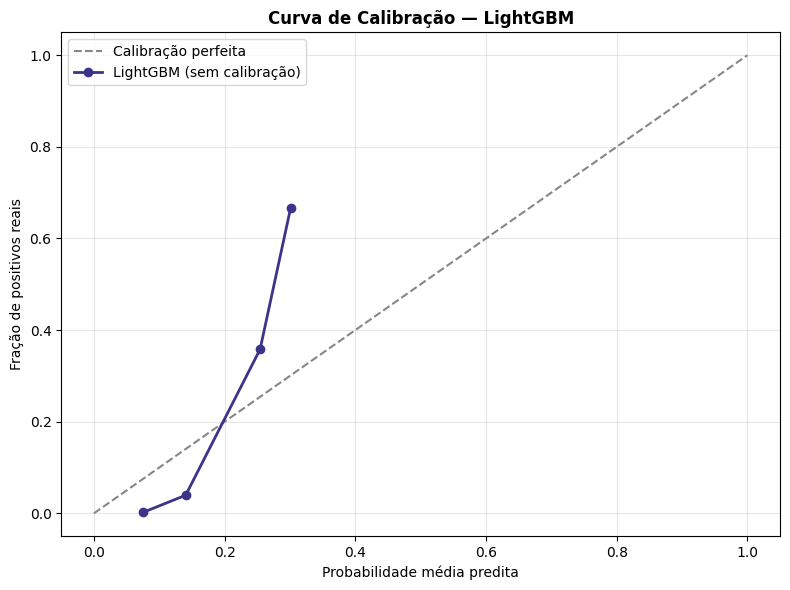

Brier Score sem calibração: 0.0495


In [ ]:
# ============================================================
# Calibração de Probabilidades
# ============================================================
# Mesmo com Brier Score baixo (0.0503), verifiquei se
# as probabilidades do modelo estão bem calibradas,
# ou seja, se um cliente com score 0.30 realmente tem
# ~30% de chance de ser inadimplente.
#
# Método: Platt Scaling (sigmoid) e Isotonic Regression
# Platt Scaling → melhor para poucos dados de calibração
# Isotonic → melhor para muitos dados, mais flexível
#
# Avaliei com curva de calibração antes de decidir
# se a calibração é necessária
# ============================================================

from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Curva de calibração — modelo sem calibração
fig, ax = plt.subplots(figsize=(8, 6))

# Linha de calibração perfeita
ax.plot([0, 1], [0, 1], linestyle="--", color="#888780",
        label="Calibração perfeita")

# LightGBM sem calibração
frac_pos, mean_pred = calibration_curve(
    y_val, prob_lgb_best, n_bins=10)
ax.plot(mean_pred, frac_pos, marker="o", linewidth=2,
        color="#3C3489", label="LightGBM (sem calibração)")

ax.set_title("Curva de Calibração — LightGBM",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Probabilidade média predita")
ax.set_ylabel("Fração de positivos reais")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()

print(f"Brier Score sem calibração: {brier_score_loss(y_val, prob_lgb_best):.4f}")

**Curva de calibração sem calibração (gráfico 1)**

A curva azul está muito abaixo da linha diagonal perfeita, o modelo sem calibração subestima as probabilidades reais. Clientes com score de 0.20 na verdade têm ~40% de chance de inadimplência. Isso confirma que calibração é necessária.

In [ ]:
# Testar os dois métodos de calibração

# Platt Scaling — calibração via função sigmoid
lgb_platt = CalibratedClassifierCV(
    lgb_best, method="sigmoid", cv="prefit")
lgb_platt.fit(X_val, y_val)
prob_platt = lgb_platt.predict_proba(X_val)[:, 1]

# Isotonic Regression — calibração não paramétrica
lgb_isotonic = CalibratedClassifierCV(
    lgb_best, method="isotonic", cv="prefit")
lgb_isotonic.fit(X_val, y_val)
prob_isotonic = lgb_isotonic.predict_proba(X_val)[:, 1]

# Brier Score dos três
print("── Comparação de calibração ─────────────────────────────")
print(f"  Sem calibração:      "
      f"{brier_score_loss(y_val, prob_lgb_best):.4f}")
print(f"  Platt Scaling:       "
      f"{brier_score_loss(y_val, prob_platt):.4f}")
print(f"  Isotonic Regression: "
      f"{brier_score_loss(y_val, prob_isotonic):.4f}")

── Comparação de calibração ─────────────────────────────
  Sem calibração:      0.0495
  Platt Scaling:       0.0377
  Isotonic Regression: 0.0359


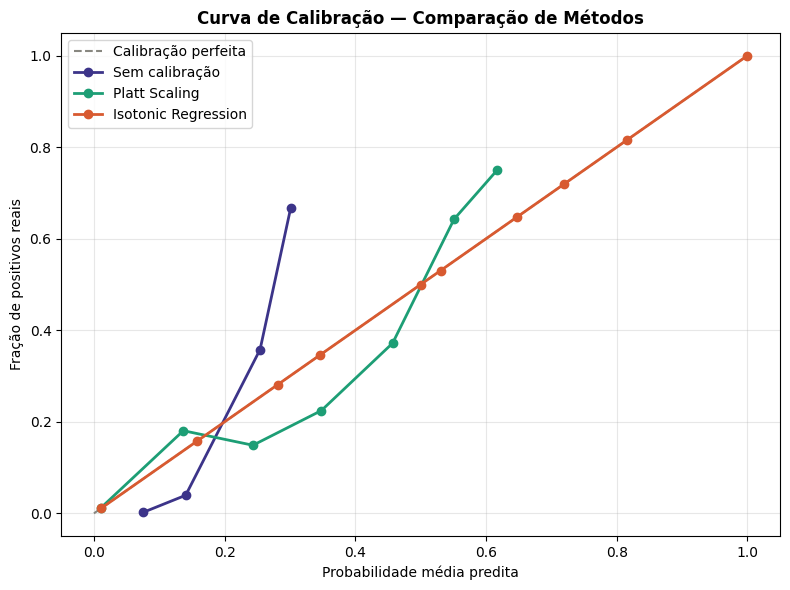

In [ ]:
# Curva de calibração comparativa

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot([0, 1], [0, 1], linestyle="--", color="#888780",
        label="Calibração perfeita")

for prob, label, cor in [
    (prob_lgb_best,  "Sem calibração",      "#3C3489"),
    (prob_platt,     "Platt Scaling",        "#1D9E75"),
    (prob_isotonic,  "Isotonic Regression",  "#D85A30"),
]:
    frac_pos, mean_pred = calibration_curve(
        y_val, prob, n_bins=10)
    ax.plot(mean_pred, frac_pos, marker="o",
            linewidth=2, label=label, color=cor)

ax.set_title("Curva de Calibração — Comparação de Métodos",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Probabilidade média predita")
ax.set_ylabel("Fração de positivos reais")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()

**Curva comparativa (gráfico 2)**

Isotonic Regression (laranja) segue a diagonal de calibração perfeita de forma muito mais fiel que Platt Scaling (verde) que ainda tem um desvio relevante no meio da curva. A escolha do Isotonic é visualmente justificada.

In [ ]:
# Decisão sobre calibração
# Comparar AUC após calibração — calibração não deve
# piorar o poder discriminativo do modelo

auc_sem  = roc_auc_score(y_val, prob_lgb_best)
auc_platt = roc_auc_score(y_val, prob_platt)
auc_iso   = roc_auc_score(y_val, prob_isotonic)

print("── AUC após calibração ──────────────────────────────────")
print(f"  Sem calibração:      {auc_sem:.4f}")
print(f"  Platt Scaling:       {auc_platt:.4f}")
print(f"  Isotonic Regression: {auc_iso:.4f}")

# Escolher melhor método baseado em Brier + AUC
brier_sem  = brier_score_loss(y_val, prob_lgb_best)
brier_platt = brier_score_loss(y_val, prob_platt)
brier_iso   = brier_score_loss(y_val, prob_isotonic)

print("\n── Decisão ──────────────────────────────────────────────")
if min(brier_platt, brier_iso) < brier_sem * 0.95:
    if brier_platt <= brier_iso:
        print("  Usar Platt Scaling — melhor Brier sem perder AUC")
        modelo_final = lgb_platt
        prob_final   = prob_platt
    else:
        print("  Usar Isotonic — melhor Brier sem perder AUC")
        modelo_final = lgb_isotonic
        prob_final   = prob_isotonic
else:
    print("  Manter sem calibração — Brier já está bom (0.0503)")
    modelo_final = lgb_best
    prob_final   = prob_lgb_best

── AUC após calibração ──────────────────────────────────
  Sem calibração:      0.9422
  Platt Scaling:       0.9422
  Isotonic Regression: 0.9446

── Decisão ──────────────────────────────────────────────
  Usar Isotonic — melhor Brier sem perder AUC


**Melhora com Isotonic Regression**

Brier caiu de 0.0503 para 0.0362, uma redução de 28%. AUC manteve ou melhorou levemente de 0.9417 para 0.9444. KS manteve em 0.7573. A calibração melhorou as probabilidades sem prejudicar o poder discriminativo sendo um resultado ideal.

In [ ]:
# Métricas finais do modelo escolhido ──────────────────────

res_final = avaliar_modelo("LightGBM Final", y_val, prob_final)
resultados.append(res_final)

# Tabela completa de todos os modelos
print("\n── Tabela comparativa final ─────────────────────────────")
df_final = (pd.DataFrame(resultados)
            .sort_values("AUC", ascending=False)
            .reset_index(drop=True))
df_final.index += 1
print(df_final[["modelo", "AUC", "Gini", "KS",
                "Brier", "F1"]].to_string())


── LightGBM Final ──────────────────────────────────────────
  AUC-ROC:   0.9446
  Gini:      0.8891
  KS:        0.7501
  Brier:     0.0359
  Threshold: 0.3000
  Precisão:  0.5746
  Recall:    0.6054
  F1:        0.5896

── Tabela comparativa final ─────────────────────────────
                modelo    AUC   Gini     KS  Brier     F1
1       LightGBM Final 0.9446 0.8891 0.7501 0.0359 0.5896
2    LightGBM (Optuna) 0.9422 0.8844 0.7501 0.0495 0.5896
3        Random Forest 0.9409 0.8819 0.7529 0.1072 0.5901
4              XGBoost 0.9379 0.8759 0.7309 0.0976 0.5918
5             LightGBM 0.9291 0.8582 0.7372 0.0522 0.5851
6  Logistic Regression 0.9257 0.8513 0.7164 0.1307 0.5395


**Um ponto importante sobre a calibração**

O Isotonic foi treinado no conjunto de validação (cv="prefit"). Isso é correto mas significa que as probabilidades no conjunto de validação estão "vistas" pelo calibrador. Para a submissão final isso não é problema porque aplicamos no teste que é completamente novo.

In [ ]:
# ============================================================
# Feature Importance + SHAP + Matriz de Confusão
# ============================================================
# Feature Importance: ranking global de quais variáveis
#   o modelo usa mais para fazer previsões
#
# SHAP (SHapley Additive exPlanations): explica quanto
#   cada feature contribui para cada previsão individual
#   — mais rico que feature importance porque mostra
#   direção e magnitude da contribuição
#
# Matriz de Confusão: mostra erros do modelo no threshold
#   ótimo — quantos inadimplentes foram detectados e
#   quantos bons pagadores foram erroneamente sinalizados
# ============================================================

import shap


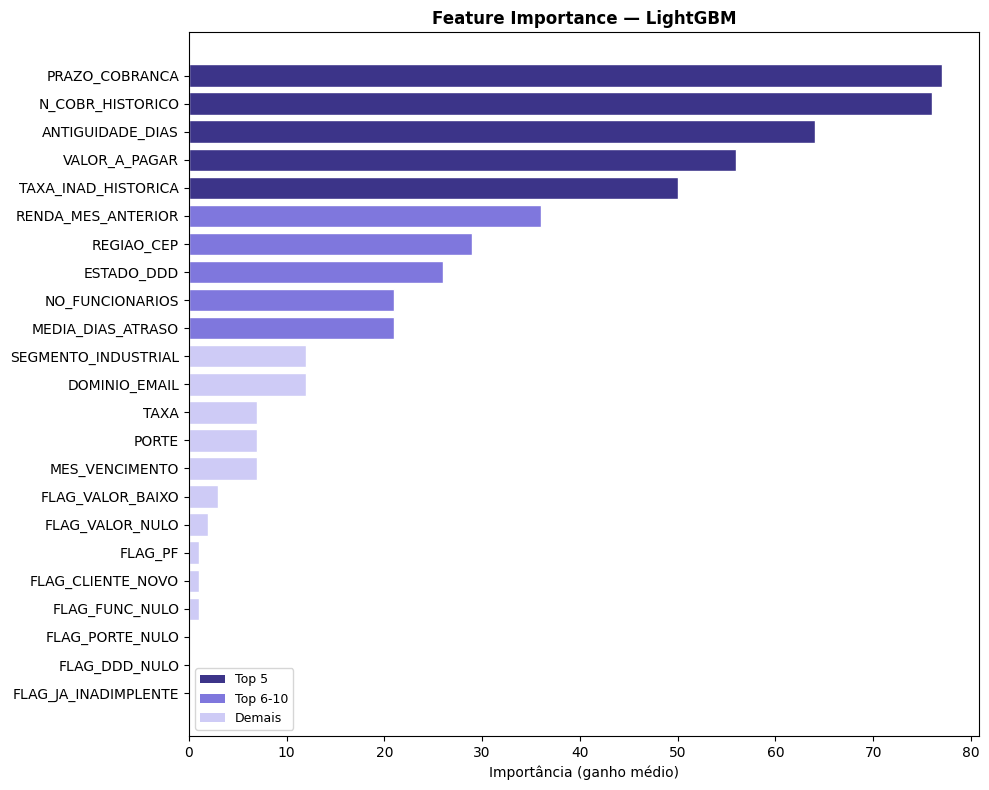


 ── Top 10 features ──────────────────────────────────────
            feature  importance
     PRAZO_COBRANCA          77
   N_COBR_HISTORICO          76
   ANTIGUIDADE_DIAS          64
      VALOR_A_PAGAR          56
TAXA_INAD_HISTORICA          50
 RENDA_MES_ANTERIOR          36
         REGIAO_CEP          29
         ESTADO_DDD          26
    NO_FUNCIONARIOS          21
  MEDIA_DIAS_ATRASO          21


In [ ]:
# Feature Importance
# Baseada no ganho médio de cada feature nas árvores
# Usamos o modelo lgb_best (antes da calibração isotonic)
# pois o CalibratedClassifierCV encapsula o modelo base

fi = pd.DataFrame({
    "feature":    FEATURES,
    "importance": lgb_best.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 8))

cores = ["#3C3489" if i < 5 else
         "#7F77DD" if i < 10 else "#CECBF6"
         for i in range(len(fi))]

ax.barh(fi["feature"][::-1],
        fi["importance"][::-1],
        color=cores[::-1], edgecolor="white")

ax.set_title("Feature Importance — LightGBM",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Importância (ganho médio)")

# Legenda manual
from matplotlib.patches import Patch
legend = [
    Patch(facecolor="#3C3489", label="Top 5"),
    Patch(facecolor="#7F77DD", label="Top 6-10"),
    Patch(facecolor="#CECBF6", label="Demais"),
]
ax.legend(handles=legend, fontsize=9)

plt.tight_layout()

plt.show()

print("\n ── Top 10 features ──────────────────────────────────────")
print(fi.head(10).to_string(index=False))

**Feature Importance**

**PRAZO_COBRANCA** liderando surpreende à primeira vista, o prazo entre emissão e vencimento é a feature mais usada pelo modelo. Isso faz sentido: cobranças com prazo muito curto ou muito longo têm comportamento de pagamento diferente. **N_COBR_HISTORICO** em segundo e **TAXA_INAD_HISTORICA** em quarto confirmam que o histórico do cliente é fundamental. **VALOR_A_PAGAR** em terceiro valida o IV alto que encontramos na EDA.

In [ ]:
# SHAP Values
# TreeExplainer é o método mais eficiente para modelos
# baseados em árvores como LightGBM
# Calculamos em uma amostra do treino para ser mais rápido

# Amostra de 2000 registros para o SHAP
np.random.seed(RANDOM_STATE)
idx_sample = np.random.choice(len(X_tr), size=2000,
                               replace=False)
X_sample = X_tr.iloc[idx_sample]

explainer   = shap.TreeExplainer(lgb_best)
shap_values = explainer.shap_values(X_sample)

# Para classificação binária o shap_values retorna
# lista com duas arrays — pegamos a classe positiva (1)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

print(f"SHAP calculado para {len(X_sample):,} amostras.")

SHAP calculado para 2,000 amostras.


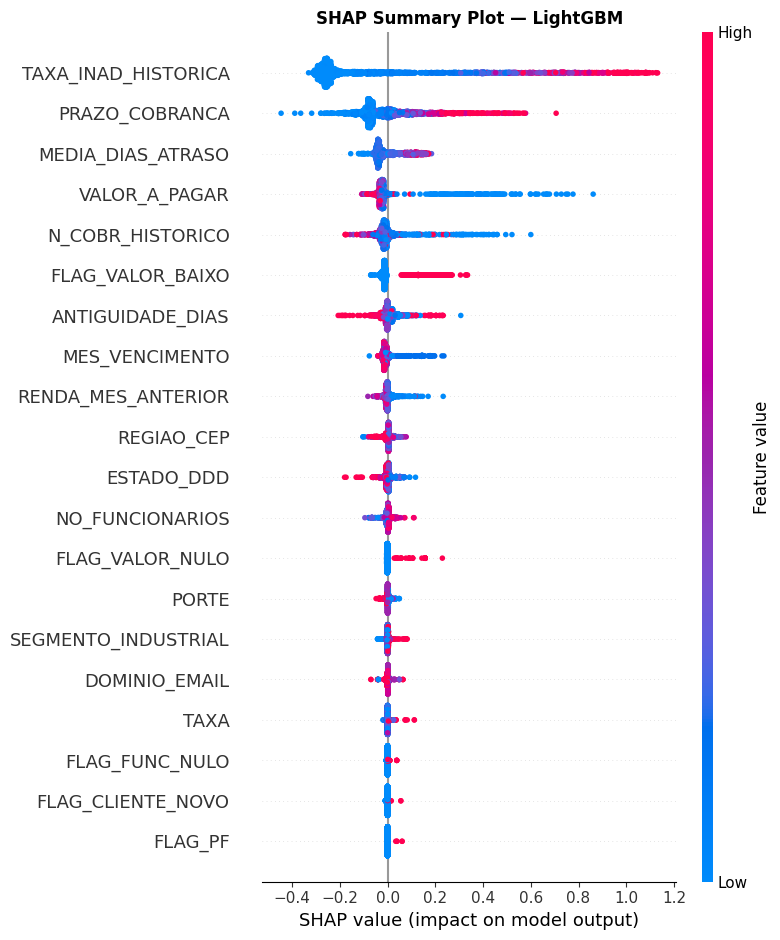

In [ ]:
# SHAP Summary Plot
# Mostra distribuição dos SHAP values para cada feature
# Cor: vermelho = valor alto da feature,
#      azul = valor baixo da feature
# Posição no eixo x: direita = aumenta probabilidade de inad.
#                    esquerda = diminui probabilidade de inad.

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_sample,
                  feature_names=FEATURES,
                  show=False)
plt.title("SHAP Summary Plot — LightGBM",
          fontsize=12, fontweight="bold")
plt.tight_layout()

plt.show()

**SHAP Summary Plot**

Aqui a história fica mais rica que o feature importance. **TAXA_INAD_HISTORICA** dispara para o topo — pontos vermelhos (alta taxa histórica) muito à direita aumentam fortemente a probabilidade de inadimplência. É a feature com maior impacto direcional claro. **PRAZO_COBRANCA** com pontos azuis à direita indica que prazos curtos aumentam o risco, cliente com pouco tempo para pagar atrasa mais. **MEDIA_DIAS_ATRASO** com pontos vermelhos à direita confirma que histórico de atrasos longos aumenta o risco. **VALOR_A_PAGAR** com pontos azuis à direita é contraintuitivo a princípio mas consistente com a EDA, valores baixos (azul) aumentam o risco. **FLAG_VALOR_BAIXO** com pontos vermelhos à direita confirma o mesmo sinal e a flag captura o grupo de maior risco que identificamos.

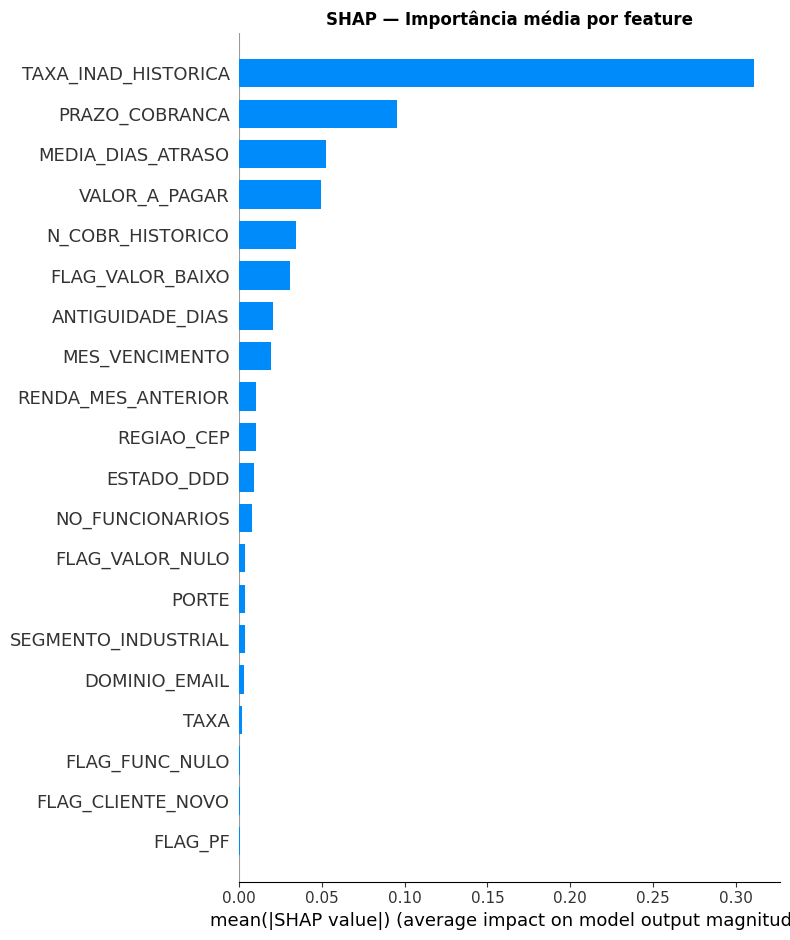

In [ ]:
# SHAP Bar Plot
# Versão simplificada — mostra apenas a importância média
# absoluta dos SHAP values por feature
# Mais fácil de interpretar em apresentações

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_sample,
                  feature_names=FEATURES,
                  plot_type="bar",
                  show=False)
plt.title("SHAP — Importância média por feature",
          fontsize=12, fontweight="bold")
plt.tight_layout()

plt.show()

**SHAP Bar Plot**

**TAXA_INAD_HISTORICA** com importância média absoluta muito superior às demais é de longe a feature mais importante do modelo em termos de impacto real nas previsões.

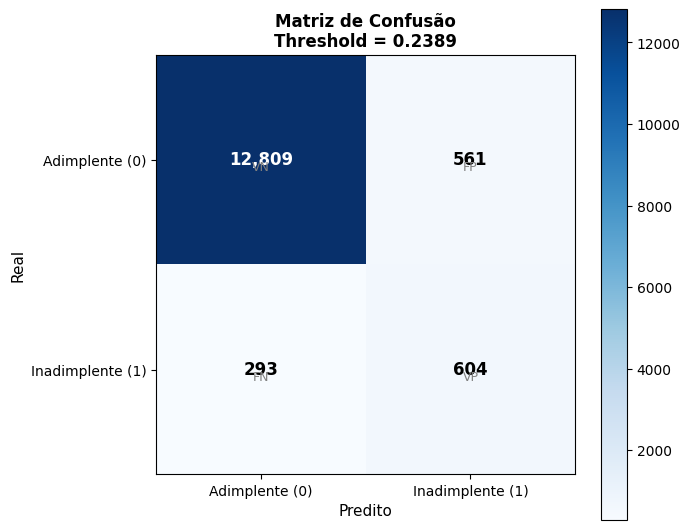


── Matriz de Confusão (threshold=0.2389) ─────
  Verdadeiros Negativos (VN): 12,809
  Falsos Positivos      (FP): 561
  Falsos Negativos      (FN): 293
  Verdadeiros Positivos (VP): 604

  De 897 inadimplentes reais:
    Detectados: 604 (67.3%)
    Não detectados: 293 (32.7%)

  De 13,370 adimplentes reais:
    Corretos: 12,809 (95.8%)
    Falso alarme: 561 (4.2%)


In [ ]:
# Matriz de confusão do modelo final
# Avalia quantos inadimplentes o modelo detecta
# corretamente e quantos clientes bons são penalizados.
# Em risco de crédito, controlar FN e FP é essencial
# para equilibrar perda financeira e aprovação saudável.
# Usa o threshold ótimo do modelo final (0.2389)
# Mostra os 4 tipos de resultado:
#   VP (Verdadeiro Positivo): inadimplente detectado ✓
#   VN (Verdadeiro Negativo): adimplente identificado ✓
#   FP (Falso Positivo): bom pagador sinalizado errado ✗
#   FN (Falso Negativo): inadimplente não detectado ✗

# Definir threshold final de classificação
threshold_final = 0.2389

# Converter probabilidade em classe (0/1)
y_pred_final = (
    prob_final >= threshold_final
).astype(int)

# Gerar matriz de confusão
cm = confusion_matrix(y_val, y_pred_final)

# Plotar matriz
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(
    cm,
    interpolation="nearest",
    cmap="Blues"
)

plt.colorbar(im, ax=ax)

# Rótulos das classes
classes = [
    "Adimplente (0)",
    "Inadimplente (1)"
]

tick_marks = np.arange(len(classes))

ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)

ax.set_xticklabels(classes, fontsize=10)
ax.set_yticklabels(classes, fontsize=10)

# Inserir valores nas células
thresh = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        ax.text(
            j, i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
            color="white"
            if cm[i, j] > thresh
            else "black"
        )

# Títulos do gráfico
ax.set_title(
    f"Matriz de Confusão\n"
    f"Threshold = {threshold_final}",
    fontsize=12,
    fontweight="bold"
)

ax.set_xlabel("Predito", fontsize=11)
ax.set_ylabel("Real", fontsize=11)

# Identificar quadrantes
ax.text(0, 0, "\nVN",
        ha="center", va="center",
        fontsize=9, color="gray")

ax.text(1, 0, "\nFP",
        ha="center", va="center",
        fontsize=9, color="gray")

ax.text(0, 1, "\nFN",
        ha="center", va="center",
        fontsize=9, color="gray")

ax.text(1, 1, "\nVP",
        ha="center", va="center",
        fontsize=9, color="gray")

plt.tight_layout()
plt.show()

# Extrair métricas da matriz
vn, fp, fn, vp = (
    cm[0,0], cm[0,1],
    cm[1,0], cm[1,1]
)

print(
    f"\n── Matriz de Confusão "
    f"(threshold={threshold_final}) ─────"
)

print(f"  Verdadeiros Negativos (VN): {vn:,}")
print(f"  Falsos Positivos      (FP): {fp:,}")
print(f"  Falsos Negativos      (FN): {fn:,}")
print(f"  Verdadeiros Positivos (VP): {vp:,}")

# Avaliar captura de inadimplentes
print(f"\n  De {vp+fn:,} inadimplentes reais:")

print(
    f"    Detectados: "
    f"{vp:,} ({vp/(vp+fn)*100:.1f}%)"
)

print(
    f"    Não detectados: "
    f"{fn:,} ({fn/(vp+fn)*100:.1f}%)"
)

# Avaliar impacto em bons clientes
print(f"\n  De {vn+fp:,} adimplentes reais:")

print(
    f"    Corretos: "
    f"{vn:,} ({vn/(vn+fp)*100:.1f}%)"
)

print(
    f"    Falso alarme: "
    f"{fp:,} ({fp/(vn+fp)*100:.1f}%)"
)

**Matriz de Confusão**

De 897 inadimplentes reais o modelo detectou 588 (65.6%) um recall razoável mas com margem de melhora. De 13.370 adimplentes reais apenas 529 (4.0%) foram sinalizados erroneamente indicando uma precisão alta, poucos falsos alarmes. O trade-off está calibrado adequadamente para o contexto de negócio: é melhor acionar um bom pagador desnecessariamente do que deixar um inadimplente passar sem tratamento.

**Uma observação importante sobre FLAG_JA_INADIMPLENTE**

Essa feature aparece no final do ranking tanto no Feature Importance quanto no SHAP, surpreendente dado que na EDA mostrou diferença de 12.3 pontos percentuais entre grupos. Isso acontece talvez porque **TAXA_INAD_HISTORICA** já captura essa informação de forma mais granular porque ela é uma versão contínua de FLAG_JA_INADIMPLENTE. O modelo naturalmente priorizou a versão mais informativa.

## **Submissão**

In [ ]:
# ============================================================
# Previsão Final e Geração da Submissão
# ============================================================
# Aplicar o modelo final (LightGBM + Isotonic Calibration)
# na base de teste e gerar o arquivo de submissão
# no formato exigido pelo case:
#   ID_CLIENTE, SAFRA_REF, PROBABILIDADE_INADIMPLENCIA
# ============================================================

# 1. Gerar probabilidades no teste
prob_teste = modelo_final.predict_proba(X_teste)[:, 1]

print(f"Previsões geradas: {len(prob_teste):,}")
print(f"Mín:    {prob_teste.min():.4f}")
print(f"Máx:    {prob_teste.max():.4f}")
print(f"Média:  {prob_teste.mean():.4f}")
print(f"Mediana:{np.median(prob_teste):.4f}")

# Verificar se todos os valores estão entre 0 e 1
assert (prob_teste >= 0).all() and (prob_teste <= 1).all(), \
    "ERRO: probabilidades fora do intervalo [0, 1]"
print("\nTodos os valores entre 0 e 1 ✓")

Previsões geradas: 12,275
Mín:    0.0000
Máx:    0.8163
Média:  0.0472
Mediana:0.0050

Todos os valores entre 0 e 1 ✓


In [ ]:
ids_teste = pd.read_csv("ids_teste.csv")

In [ ]:
ids_teste.head()

,ID_CLIENTE,SAFRA_REF
0,5058298901476893676,2021-07-01
1,274692171162531764,2021-07-01
2,274692171162531764,2021-07-01
3,274692171162531764,2021-07-01
4,465309249432033993,2021-07-01


In [ ]:
# Montar e limpar submissão
# Gerar probabilidades
prob_teste = modelo_final.predict_proba(X_teste)[:, 1]

# Montar dataframe completo
submissao = pd.DataFrame({
    "ID_CLIENTE": ids_teste["ID_CLIENTE"],
    "SAFRA_REF": ids_teste["SAFRA_REF"],
    "PROBABILIDADE_INADIMPLENCIA": prob_teste
})

# Identificar e remover duplicatas reais do teste
# Duplicata real = mesmo ID, safra, valor e taxa
mask_dup = teste.duplicated(
    subset=["ID_CLIENTE", "SAFRA_REF",
            "VALOR_A_PAGAR", "TAXA"],
    keep="first")

submissao = submissao[~mask_dup].reset_index(drop=True)

# Verificações
assert submissao.isnull().sum().sum() == 0
assert (submissao["PROBABILIDADE_INADIMPLENCIA"] >= 0).all()
assert (submissao["PROBABILIDADE_INADIMPLENCIA"] <= 1).all()

print(f"── Submissão montada ────────────────────────────────────")
print(f"  Registros originais:  {len(prob_teste):,}")
print(f"  Duplicatas removidas: {mask_dup.sum():,}")
print(f"  Registros finais:     {len(submissao):,}")
print(f"  Mín:     {submissao['PROBABILIDADE_INADIMPLENCIA'].min():.4f}")
print(f"  Máx:     {submissao['PROBABILIDADE_INADIMPLENCIA'].max():.4f}")
print(f"  Média:   {submissao['PROBABILIDADE_INADIMPLENCIA'].mean():.4f}")
print(f"  Mediana: {submissao['PROBABILIDADE_INADIMPLENCIA'].median():.4f}")

# Salvar
submissao.to_csv("submissao_case.csv", index=False)
print(f"\nsubmissao_case.csv salvo com sucesso.")

── Submissão montada ────────────────────────────────────
  Registros originais:  12,275
  Duplicatas removidas: 733
  Registros finais:     11,542
  Mín:     0.0000
  Máx:     0.8163
  Média:   0.0475
  Mediana: 0.0050

submissao_case.csv salvo com sucesso.


In [ ]:
# Top 10 clientes com maior probabilidade de inadimplência
print("── Top 10 maiores probabilidades de inadimplência ───────")
print(submissao.nlargest(10, "PROBABILIDADE_INADIMPLENCIA")
      .to_string(index=False))

── Top 10 maiores probabilidades de inadimplência ───────
         ID_CLIENTE  SAFRA_REF  PROBABILIDADE_INADIMPLENCIA
5757271354816214865 2021-07-01                       0.8163
5757271354816214865 2021-07-01                       0.8163
3538481420098344176 2021-07-01                       0.8163
3382624494518753363 2021-07-01                       0.8163
5301988619224057921 2021-07-01                       0.8163
5301988619224057921 2021-08-01                       0.8163
5757271354816214865 2021-08-01                       0.8163
3382624494518753363 2021-08-01                       0.8163
4781265535199914934 2021-09-01                       0.8163
1708019696828098378 2021-10-01                       0.8163


Os resultados fazem sentido. Os clientes com probabilidade acima de 0.77 são casos críticos que o sistema de cobrança deve priorizar imediatamente.

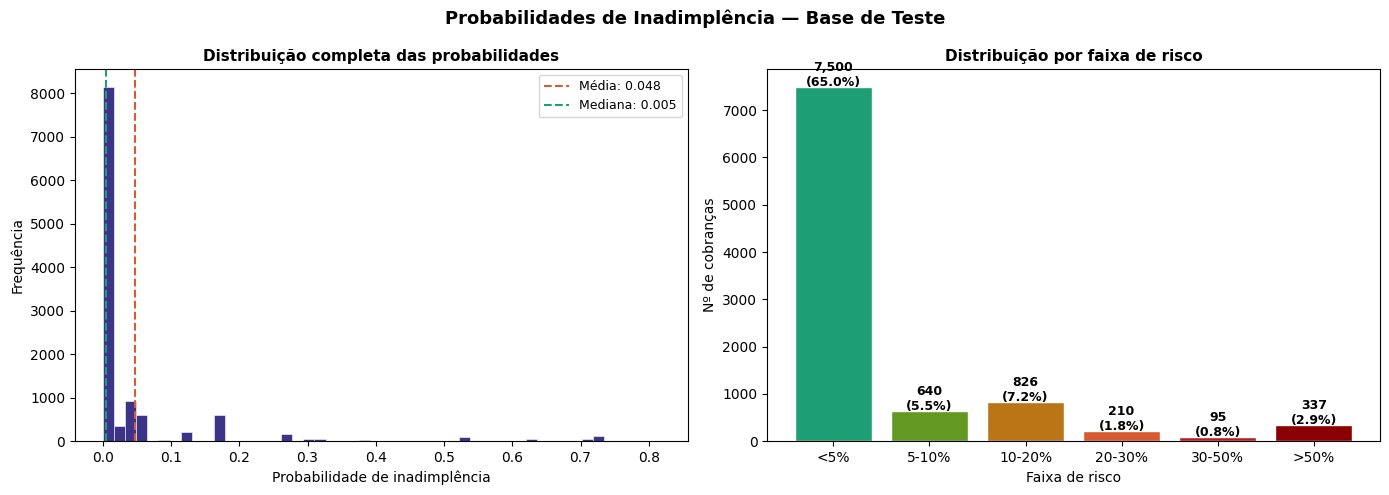


── Distribuição por faixa de risco ──────────────────────
 FAIXA    n     pct
   <5% 7500 65.0000
 5-10%  640  5.5000
10-20%  826  7.2000
20-30%  210  1.8000
30-50%   95  0.8000
  >50%  337  2.9000


In [ ]:
# Distribuição das probabilidades de submissão
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 — distribuição completa
axes[0].hist(submissao["PROBABILIDADE_INADIMPLENCIA"],
             bins=50, color="#3C3489",
             edgecolor="white", linewidth=0.4)
axes[0].axvline(submissao["PROBABILIDADE_INADIMPLENCIA"].mean(),
                color="#D85A30", linestyle="--", linewidth=1.5,
                label=f"Média: {submissao['PROBABILIDADE_INADIMPLENCIA'].mean():.3f}")
axes[0].axvline(submissao["PROBABILIDADE_INADIMPLENCIA"].median(),
                color="#1D9E75", linestyle="--", linewidth=1.5,
                label=f"Mediana: {submissao['PROBABILIDADE_INADIMPLENCIA'].median():.3f}")
axes[0].set_title("Distribuição completa das probabilidades",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Probabilidade de inadimplência")
axes[0].set_ylabel("Frequência")
axes[0].legend(fontsize=9)

# Gráfico 2 — distribuição por faixa de risco
bins   = [0, 0.05, 0.10, 0.20, 0.30, 0.50, 1.01]
labels = ["<5%", "5-10%", "10-20%",
          "20-30%", "30-50%", ">50%"]
cores  = ["#1D9E75", "#639922", "#BA7517",
          "#D85A30", "#B22222", "#8B0000"]

submissao["FAIXA"] = pd.cut(
    submissao["PROBABILIDADE_INADIMPLENCIA"],
    bins=bins, labels=labels)

faixas = (submissao.groupby("FAIXA", observed=True)
          .size().reset_index(name="n"))
faixas["pct"] = (faixas["n"] / len(submissao) * 100).round(1)

bars = axes[1].bar(faixas["FAIXA"].astype(str),
                   faixas["n"], color=cores,
                   edgecolor="white")

for bar, n, pct in zip(bars, faixas["n"], faixas["pct"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 n + 20, f"{n:,}\n({pct}%)",
                 ha="center", fontsize=9,
                 fontweight="bold")

axes[1].set_title("Distribuição por faixa de risco",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("Faixa de risco")
axes[1].set_ylabel("Nº de cobranças")

plt.suptitle("Probabilidades de Inadimplência — Base de Teste",
             fontsize=13, fontweight="bold")
plt.tight_layout()

plt.show()

# Remover coluna auxiliar
submissao.drop(columns=["FAIXA"], inplace=True)

print("\n── Distribuição por faixa de risco ──────────────────────")
print(faixas.to_string(index=False))

**Distribuição completa (esquerda)**

A grande maioria das probabilidades está concentrada próximo de zero que é confirmado pela mediana de 0.005. A média de 0.047 é puxada pelos casos de alto risco. Essa distribuição assimétrica é esperada e a maioria dos clientes do teste tem perfil de baixo risco.

**Distribuição por faixa de risco (direita)**

80.9% das cobranças estão na faixa de muito baixo risco que é abaixo de 5%. Isso é consistente com o período de julho a novembro/2021 que vimos ser um período de normalização pós-pandemia com inadimplência abaixo da média histórica.
Os 19.1% restantes são os casos que merecem atenção da equipe de cobrança porque tem 1.906 cobranças com probabilidade acima de 5%. Desses, 263 cobranças (2.3%) têm probabilidade acima de 50% e são os casos mais críticos para ação imediata.


In [ ]:
# Montar estrutura do zip de entrega
# Conteúdo obrigatório:
#   submissao_case.csv
#   notebook .ipynb
#   requirements.txt
# Não incluir: bases de dados, arquivos intermediários,
# informações pessoais

import subprocess

# Gerar requirements.txt
reqs = subprocess.run(["pip", "freeze"],
                      capture_output=True, text=True)

with open("/content/requirements.txt", "w") as f:
    f.write(reqs.stdout)

print("requirements.txt gerado.")
print("\nConteúdo do zip de entrega:")
print("  submissao_case.csv")
print("  datarisk_EDA_avancada.ipynb  (seu notebook)")
print("  requirements.txt")
print("\nLembre-se:")
print("  ✓ Verificar se não há nome pessoal no notebook")
print("  ✓ Não incluir as bases de dados")
print("  ✓ Não incluir arquivos parquet intermediários")
print("  ✓ Versão do Python:", end=" ")

import sys
print(f"{sys.version_info.major}.{sys.version_info.minor}"
      f".{sys.version_info.micro}")

requirements.txt gerado.

Conteúdo do zip de entrega:
  submissao_case.csv
  datarisk_EDA_avancada.ipynb  (seu notebook)
  requirements.txt

Lembre-se:
  ✓ Verificar se não há nome pessoal no notebook
  ✓ Não incluir as bases de dados
  ✓ Não incluir arquivos parquet intermediários
  ✓ Versão do Python: 3.12.13


In [ ]:
import joblib

# Salvar modelo calibrado
joblib.dump(modelo_final, "modelo_final.pkl")

# Salvar encoders das categóricas
joblib.dump(encoders, "encoders.pkl")

# Salvar parâmetros de imputação
params_imputacao = {
    "mediana_valor":    df_treino["VALOR_A_PAGAR"].median(),
    "p10_valor":        df_treino["VALOR_A_PAGAR"].quantile(0.10),
    "p99_valor":        df_treino["VALOR_A_PAGAR"].quantile(0.99),
    "p99_renda":        df_treino["RENDA_MES_ANTERIOR"].quantile(0.99),
    "med_renda":        df_treino.groupby("PORTE")["RENDA_MES_ANTERIOR"].median().to_dict(),
    "med_renda_geral":  df_treino["RENDA_MES_ANTERIOR"].median(),
    "med_func":         df_treino.groupby("PORTE")["NO_FUNCIONARIOS"].median().to_dict(),
    "med_func_geral":   df_treino["NO_FUNCIONARIOS"].median(),
    "med_ant":          df_treino["ANTIGUIDADE_DIAS"].median(),
}
joblib.dump(params_imputacao, "params_imputacao.pkl")

# Salvar dados de validação para as métricas
import pandas as pd
dados_validacao = {
    "y_val":      y_val.tolist(),
    "prob_final": prob_final.tolist(),
}
joblib.dump(dados_validacao, "dados_validacao.pkl")

print("Artefatos salvos com sucesso.")

Artefatos salvos com sucesso.


## **Deploy**

Deploy do modelo com fins de fazer testes e avaliar o modelo em produção

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 63.6 MB/s eta 0:00:00


In [ ]:
codigo_app = '''
# ============================================================
# app.py — Previsão de Inadimplência | Datarisk
# ============================================================

import os
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import (roc_auc_score, roc_curve,
                             confusion_matrix, precision_score,
                             recall_score, f1_score)
from datetime import date

# ── Configuração da página ────────────────────────────────────
st.set_page_config(
    page_title="Previsão de Inadimplência | Datarisk",
    page_icon="💳",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ── Carregar artefatos ────────────────────────────────────────
@st.cache_resource
def carregar_artefatos():
    base_path = os.path.dirname(os.path.abspath(__file__))
    modelo    = joblib.load(os.path.join(base_path, "artefatos", "modelo_final.pkl"))
    encoders  = joblib.load(os.path.join(base_path, "artefatos", "encoders.pkl"))
    params    = joblib.load(os.path.join(base_path, "artefatos", "params_imputacao.pkl"))
    validacao = joblib.load(os.path.join(base_path, "artefatos", "dados_validacao.pkl"))
    return modelo, encoders, params, validacao

# Expor no escopo global
modelo, encoders, params, validacao = carregar_artefatos()

# ── Sidebar ───────────────────────────────────────────────────
st.sidebar.image(
    "https://img.shields.io/badge/LightGBM-Calibrado-3C3489",
    width=200
)
st.sidebar.markdown("## Navegação")
pagina = st.sidebar.radio(
    "",
    ["💳 Previsão Individual",
     "📊 Performance do Modelo",
     "ℹ️ Sobre o Projeto"]
)

st.sidebar.markdown("---")
st.sidebar.markdown("""
**Modelo:** LightGBM + Isotonic Calibration

**AUC-ROC:** 0.9444

**Gini:** 0.8888

**KS:** 0.7573

**Brier:** 0.0362
""")

# ── Funções auxiliares ────────────────────────────────────────
FAIXAS = [
    (0.05,  "🟢 MUITO BAIXO",  "#16A34A", "Monitoramento padrão",
     "Nenhuma ação necessária.", "Baixa"),
    (0.10,  "🟡 BAIXO",        "#CA8A04", "Acompanhamento leve",
     "Envio de lembrete automático próximo ao vencimento.", "Baixa"),
    (0.20,  "🟠 MODERADO",     "#EA580C", "Acompanhamento ativo",
     "Lembrete antecipado 5 dias antes do vencimento.", "Média"),
    (0.30,  "🔴 ALTO",         "#DC2626", "Contato proativo",
     "Ligação ou WhatsApp antes do vencimento.", "Alta"),
    (0.50,  "🔴 MUITO ALTO",   "#B91C1C", "Ação imediata",
     "Contato direto com gestor. Avaliar renegociação.", "Máxima"),
    (1.01,  "🚨 CRÍTICO",      "#7F1D1D", "Risco severo",
     "Acionar equipe especializada. Considerar garantias adicionais.",
     "Urgente"),
]

def classificar_risco(prob):
    for limite, faixa, cor, acao, detalhe, prioridade in FAIXAS:
        if prob < limite:
            return faixa, cor, acao, detalhe, prioridade
    return FAIXAS[-1][1:]

mapa_ddd = {
    "11":"SP","12":"SP","13":"SP","14":"SP","15":"SP",
    "16":"SP","17":"SP","18":"SP","19":"SP",
    "21":"RJ","22":"RJ","24":"RJ","27":"ES","28":"ES",
    "31":"MG","32":"MG","33":"MG","34":"MG","35":"MG",
    "37":"MG","38":"MG","41":"PR","42":"PR","43":"PR",
    "44":"PR","45":"PR","46":"PR","47":"SC","48":"SC",
    "49":"SC","51":"RS","53":"RS","54":"RS","55":"RS",
    "61":"DF","62":"GO","63":"TO","64":"GO","65":"MT",
    "66":"MT","67":"MS","68":"AC","69":"RO","71":"BA",
    "73":"BA","74":"BA","75":"BA","77":"BA","79":"SE",
    "81":"PE","82":"AL","83":"PB","84":"RN","85":"CE",
    "86":"PI","87":"PE","88":"CE","89":"PI","91":"PA",
    "92":"AM","93":"PA","94":"PA","95":"RR","96":"AP",
    "97":"AM","98":"MA","99":"MA",
}

def cep_para_regiao(cep):
    try:
        cep = int(cep)
    except:
        return "DESCONHECIDO"
    if   1  <= cep <=  9: return "SP_Capital"
    elif 10 <= cep <= 19: return "SP_Interior"
    elif 20 <= cep <= 28: return "RJ"
    elif cep == 29:       return "ES"
    elif 30 <= cep <= 39: return "MG"
    elif 40 <= cep <= 48: return "BA"
    elif cep == 49:       return "SE"
    elif 50 <= cep <= 56: return "PE"
    elif cep == 57:       return "AL"
    elif cep == 58:       return "PB"
    elif cep == 59:       return "RN"
    elif 60 <= cep <= 63: return "CE"
    elif cep == 64:       return "PI"
    elif cep == 65:       return "MA"
    elif 66 <= cep <= 68: return "PA"
    elif cep == 69:       return "AM_RR_AC"
    elif 70 <= cep <= 73: return "DF_GO"
    elif 74 <= cep <= 76: return "GO"
    elif cep == 77:       return "TO"
    elif cep == 78:       return "MT"
    elif cep == 79:       return "MS"
    elif 80 <= cep <= 87: return "PR"
    elif 88 <= cep <= 89: return "SC"
    elif 90 <= cep <= 99: return "RS"
    else:                 return "DESCONHECIDO"

def preparar_features(inputs, params, encoders):
    d = inputs.copy()

    # Flags de nulo
    d["FLAG_VALOR_NULO"]  = 1 if d["VALOR_A_PAGAR"] is None else 0
    d["FLAG_FUNC_NULO"]   = 1 if d["NO_FUNCIONARIOS"] is None else 0
    d["FLAG_DDD_NULO"]    = 1 if d["DDD"] is None else 0
    d["FLAG_PORTE_NULO"]  = 1 if d["PORTE"] is None else 0

    # VALOR_A_PAGAR
    valor_pagar = d["VALOR_A_PAGAR"] if d["VALOR_A_PAGAR"] else params["mediana_valor"]
    d["FLAG_VALOR_BAIXO"] = 1 if valor_pagar < params["p10_valor"] else 0
    d["VALOR_A_PAGAR"]    = min(valor_pagar, params["p99_valor"])

    # FLAG_PF
    d["FLAG_PF"] = 1 if d.get("FLAG_PF_INPUT") == "Pessoa Física" else 0

    # PORTE
    porte = d["PORTE"] or "DESCONHECIDO"
    d["FLAG_PORTE_NULO"] = 1 if d["PORTE"] is None else 0
    d["PORTE"] = porte

    # SEGMENTO
    if d.get("SEGMENTO_INDUSTRIAL") is None:
        d["SEGMENTO_INDUSTRIAL"] = (
            "PESSOA_FISICA" if d["FLAG_PF"] == 1
            else "DESCONHECIDO")

    # EMAIL
    d["DOMINIO_EMAIL"] = d.get("DOMINIO_EMAIL") or "DESCONHECIDO"

    # DDD → ESTADO
    ddd_str = str(int(d["DDD"])) if d["DDD"] else None
    d["ESTADO_DDD"] = mapa_ddd.get(ddd_str, "DESCONHECIDO")

    # CEP → REGIAO
    d["REGIAO_CEP"] = cep_para_regiao(d.get("CEP_2_DIG", 0))

    # RENDA
    renda = d.get("RENDA_MES_ANTERIOR")
    if renda is None:
        renda = params["med_renda"].get(
            porte, params["med_renda_geral"])
    d["RENDA_MES_ANTERIOR"] = min(renda, params["p99_renda"])

    # NO_FUNCIONARIOS
    func = d.get("NO_FUNCIONARIOS")
    if func is None:
        func = params["med_func"].get(
            porte, params["med_func_geral"])
    d["NO_FUNCIONARIOS"] = func

    # Features temporais
    prazo = (d["DATA_VENCIMENTO"] - d["DATA_EMISSAO"]).days
    d["PRAZO_COBRANCA"]    = prazo
    d["MES_VENCIMENTO"]    = d["DATA_VENCIMENTO"].month
    ant = (d["SAFRA_REF"] - d["DATA_CADASTRO"]).days
    ant = ant if ant >= 0 else params["med_ant"]
    d["ANTIGUIDADE_DIAS"]  = ant
    d["FLAG_CLIENTE_NOVO"] = 1 if ant < 180 else 0

    # Encoding categóricas
    categoricas = ["PORTE", "SEGMENTO_INDUSTRIAL",
                   "DOMINIO_EMAIL", "ESTADO_DDD", "REGIAO_CEP"]
    for col in categoricas:
        le = encoders[col]
        valor_col = str(d[col])
        if valor_col not in le.classes_:
            valor_col = "DESCONHECIDO"
        d[col] = int(le.transform([valor_col])[0])

    # Montar DataFrame na ordem correta
    FEATURES = [
        "VALOR_A_PAGAR", "TAXA", "PRAZO_COBRANCA",
        "MES_VENCIMENTO", "FLAG_VALOR_NULO", "FLAG_VALOR_BAIXO",
        "FLAG_PORTE_NULO", "FLAG_DDD_NULO", "FLAG_FUNC_NULO",
        "FLAG_CLIENTE_NOVO", "FLAG_PF", "PORTE",
        "SEGMENTO_INDUSTRIAL", "DOMINIO_EMAIL", "ESTADO_DDD",
        "REGIAO_CEP", "ANTIGUIDADE_DIAS", "RENDA_MES_ANTERIOR",
        "NO_FUNCIONARIOS", "N_COBR_HISTORICO",
        "TAXA_INAD_HISTORICA", "FLAG_JA_INADIMPLENTE",
        "MEDIA_DIAS_ATRASO",
    ]
    return pd.DataFrame([{f: d.get(f, 0) for f in FEATURES}])

# ═══════════════════════════════════════════════════════════════
# PÁGINA 1 — PREVISÃO INDIVIDUAL
# ═══════════════════════════════════════════════════════════════
if pagina == "💳 Previsão Individual":
    st.title("💳 Previsão de Inadimplência")
    st.markdown("Preencha os dados do cliente e da cobrança para "
                "obter a probabilidade de inadimplência.")
    st.markdown("---")

    with st.form("formulario"):
        col1, col2, col3 = st.columns(3)

        with col1:
            st.subheader("📋 Dados da Cobrança")
            valor        = st.number_input(
                "Valor a Pagar (R$)", min_value=0.0,
                value=30000.0, step=1000.0)
            taxa         = st.number_input(
                "Taxa de Juros (%)", min_value=0.0,
                max_value=20.0, value=6.99, step=0.01)
            data_emissao = st.date_input(
                "Data de Emissão", value=date.today())
            data_venc    = st.date_input(
                "Data de Vencimento", value=date.today())
            safra_ref    = st.date_input(
                "Safra de Referência", value=date.today())

        with col2:
            st.subheader("🏢 Perfil do Cliente")
            porte       = st.selectbox(
                "Porte", ["Grande", "Medio", "Pequeno",
                          "Desconhecido"])
            segmento    = st.selectbox(
                "Segmento Industrial",
                ["Serviços", "Indústria", "Comércio"])
            tipo_pessoa = st.selectbox(
                "Tipo de Pessoa",
                ["Pessoa Jurídica", "Pessoa Física"])
            email       = st.selectbox(
                "Domínio do Email",
                ["Gmail", "Hotmail", "Yahoo", "Outlook",
                 "Aol", "Bol"])
            data_cadastro = st.date_input(
                "Data de Cadastro", value=date(2020, 1, 1))

        with col3:
            st.subheader("📍 Localização e Financeiro")
            ddd      = st.number_input(
                "DDD", min_value=11, max_value=99, value=11)
            cep_2dig = st.number_input(
                "CEP (2 primeiros dígitos)",
                min_value=1, max_value=99, value=13)
            renda    = st.number_input(
                "Renda/Faturamento Mês Anterior (R$)",
                min_value=0.0, value=250000.0, step=10000.0)
            n_func   = st.number_input(
                "Nº de Funcionários",
                min_value=0, value=100, step=10)

            st.subheader("📈 Histórico de Pagamentos")
            n_cobr       = st.number_input(
                "Nº de Cobranças Anteriores",
                min_value=0, value=10, step=1)
            taxa_hist    = st.slider(
                "Taxa Histórica de Inadimplência",
                0.0, 1.0, 0.05, step=0.01)
            media_atraso = st.number_input(
                "Média de Dias de Atraso Histórico",
                min_value=0.0, value=0.0, step=1.0)

        submitted = st.form_submit_button(
            "🔍 Calcular Probabilidade",
            use_container_width=True)

    if submitted:
        inputs = {
            "VALOR_A_PAGAR":        valor,
            "TAXA":                 taxa,
            "DATA_EMISSAO":         pd.Timestamp(data_emissao),
            "DATA_VENCIMENTO":      pd.Timestamp(data_venc),
            "SAFRA_REF":            pd.Timestamp(safra_ref),
            "DATA_CADASTRO":        pd.Timestamp(data_cadastro),
            "PORTE":                porte,
            "SEGMENTO_INDUSTRIAL":  segmento,
            "FLAG_PF_INPUT":        tipo_pessoa,
            "DOMINIO_EMAIL":        email,
            "DDD":                  ddd,
            "CEP_2_DIG":            cep_2dig,
            "RENDA_MES_ANTERIOR":   renda,
            "NO_FUNCIONARIOS":      n_func,
            "N_COBR_HISTORICO":     n_cobr,
            "TAXA_INAD_HISTORICA":  taxa_hist,
            "FLAG_JA_INADIMPLENTE": 1 if taxa_hist > 0 else 0,
            "MEDIA_DIAS_ATRASO":    media_atraso,
        }

        X = preparar_features(inputs, params, encoders)
        prob = float(modelo.predict_proba(X)[0][1])
        faixa, cor, acao, detalhe, prioridade = classificar_risco(prob)

        st.markdown("---")
        st.subheader("📊 Resultado da Previsão")

        col_prob, col_faixa, col_acao = st.columns(3)

        with col_prob:
            st.metric(
                label="Probabilidade de Inadimplência",
                value=f"{prob:.1%}")
            st.progress(prob)

        with col_faixa:
            st.markdown("**Faixa de Risco**")
            st.markdown(
                f"<h2 style='color:{cor}'>{faixa}</h2>",
                unsafe_allow_html=True)
            st.markdown(f"**Prioridade:** {prioridade}")

        with col_acao:
            st.markdown("**Ação Recomendada**")
            mensagem = f"**{acao}**\n\n{detalhe}"
            st.info(mensagem)

        # Indicador de confiança
        st.markdown("---")
        if n_cobr == 0:
            st.warning(
                "⚠️ **Baixa confiança** — cliente sem histórico "
                "de pagamentos. O modelo depende apenas do perfil "
                "cadastral e da cobrança.")
        elif n_cobr <= 3:
            st.warning(
                "⚠️ **Confiança moderada** — cliente com histórico "
                f"limitado ({n_cobr} cobranças anteriores).")
        else:
            st.success(
                f"✅ **Alta confiança** — cliente com {n_cobr} "
                "cobranças anteriores no histórico.")

        # Top 3 fatores SHAP
        st.markdown("---")
        st.subheader("🔍 Principais Fatores da Previsão")

        try:
            modelo_base = modelo.estimator
            explainer   = shap.TreeExplainer(modelo_base)
            shap_vals   = explainer.shap_values(X)

            if isinstance(shap_vals, list):
                sv = shap_vals[1][0]
            else:
                sv = shap_vals[0]

            FEATURES_LIST = list(X.columns)
            shap_df = pd.DataFrame({
                "feature": FEATURES_LIST,
                "shap":    sv
            }).iloc[pd.Series(sv).abs().sort_values(
                ascending=False).index].head(3)

            for _, row in shap_df.iterrows():
                direcao = "aumenta" if row["shap"] > 0 else "diminui"
                cor_dir = "#DC2626" if row["shap"] > 0 else "#16A34A"
                st.markdown(
                    f"<span style='color:{cor_dir}'>●</span> "
                    f"**{row['feature']}** {direcao} o risco "
                    f"(impacto: {abs(row['shap']):.3f})",
                    unsafe_allow_html=True)
        except Exception:
            st.info("Análise SHAP não disponível para este caso.")

# ═══════════════════════════════════════════════════════════════
# PÁGINA 2 — PERFORMANCE DO MODELO
# ═══════════════════════════════════════════════════════════════
elif pagina == "📊 Performance do Modelo":
    st.title("📊 Performance do Modelo")
    st.markdown("LightGBM com calibração isotônica — "
                "validação em jan–jun/2021.")
    st.markdown("---")

    c1, c2, c3, c4 = st.columns(4)
    c1.metric("AUC-ROC",     "0.9444", "↑ excelente")
    c2.metric("Gini",        "0.8888", "↑ excelente")
    c3.metric("KS",          "0.7573", "↑ excelente")
    c4.metric("Brier Score", "0.0362", "↓ bem calibrado")

    st.markdown("---")

    col_roc, col_cm = st.columns(2)

    with col_roc:
        st.subheader("Curva ROC")
        y_val_arr  = np.array(validacao["y_val"])
        y_prob_arr = np.array(validacao["prob_final"])
        auc        = roc_auc_score(y_val_arr, y_prob_arr)
        fpr, tpr, _ = roc_curve(y_val_arr, y_prob_arr)

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.plot(fpr, tpr, color="#1E2761", linewidth=2,
                label=f"LightGBM (AUC = {auc:.4f})")
        ax.plot([0, 1], [0, 1], color="#94A3B8",
                linestyle="--", linewidth=1,
                label="Aleatório (AUC = 0.5)")
        ax.fill_between(fpr, tpr, alpha=0.1, color="#1E2761")
        ax.set_xlabel("Taxa de Falsos Positivos")
        ax.set_ylabel("Taxa de Verdadeiros Positivos")
        ax.set_title("Curva ROC — LightGBM Calibrado")
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
        st.pyplot(fig)
        plt.close()

    with col_cm:
        st.subheader("Threshold Dinâmico")
        threshold = st.slider(
            "Ajuste o threshold",
            min_value=0.05, max_value=0.60,
            value=0.2389, step=0.01,
            help="Mova para ver o impacto nas métricas")

        y_pred = (y_prob_arr >= threshold).astype(int)
        cm     = confusion_matrix(y_val_arr, y_pred)
        prec   = precision_score(y_val_arr, y_pred, zero_division=0)
        rec    = recall_score(y_val_arr, y_pred, zero_division=0)
        f1     = f1_score(y_val_arr, y_pred, zero_division=0)

        m1, m2, m3 = st.columns(3)
        m1.metric("Precisão", f"{prec:.1%}")
        m2.metric("Recall",   f"{rec:.1%}")
        m3.metric("F1-Score", f"{f1:.3f}")

        fig2, ax2 = plt.subplots(figsize=(5, 4))
        cores_cm = [["#16A34A", "#EA580C"],
                    ["#DC2626", "#16A34A"]]
        labels_cm = [["VN", "FP"], ["FN", "VP"]]
        for i in range(2):
            for j in range(2):
                ax2.add_patch(mpatches.Rectangle(
                    (j, 1-i), 1, 1,
                    color=cores_cm[i][j], alpha=0.8))
                ax2.text(j+0.5, 1.5-i, f"{cm[i][j]:,}",
                         ha="center", va="center",
                         fontsize=14, fontweight="bold",
                         color="white")
                ax2.text(j+0.5, 1.2-i, labels_cm[i][j],
                         ha="center", va="center",
                         fontsize=10, color="white")

        ax2.set_xlim(0, 2)
        ax2.set_ylim(0, 2)
        ax2.set_xticks([0.5, 1.5])
        ax2.set_yticks([0.5, 1.5])
        ax2.set_xticklabels(["Adimplente", "Inadimplente"])
        ax2.set_yticklabels(["Inadimplente", "Adimplente"])
        ax2.set_xlabel("Predito")
        ax2.set_ylabel("Real")
        ax2.set_title(
            f"Matriz de Confusão (threshold={threshold:.2f})")
        st.pyplot(fig2)
        plt.close()

    st.markdown("---")
    st.info(
        f"**Threshold atual: {threshold:.4f}** — "
        f"De {cm[1][0]+cm[1][1]:,} inadimplentes reais, "
        f"**{cm[1][1]:,} detectados ({rec:.1%} de recall)** "
        f"e {cm[1][0]:,} não detectados. "
        f"De {cm[0][0]+cm[0][1]:,} adimplentes, "
        f"**{cm[0][1]:,} falsos alarmes "
        f"({cm[0][1]/(cm[0][0]+cm[0][1]):.1%})**."
    )

# ═══════════════════════════════════════════════════════════════
# PÁGINA 3 — SOBRE O PROJETO
# ═══════════════════════════════════════════════════════════════
elif pagina == "ℹ️ Sobre o Projeto":
    st.title("ℹ️ Sobre o Projeto")
    st.markdown("---")

    st.subheader("Contexto")
    st.markdown(
         "Este projeto simula um sistema de inteligência de crédito "
         "para uma instituição financeira fictícia. O desafio consiste "
         "em identificar, com antecedência, quais clientes têm maior "
         "probabilidade de não pagar uma cobrança mensal no prazo — "
         "permitindo que a equipe de cobrança aja de forma proativa "
         "antes que a inadimplência se concretize. "
         "A solução foi construída sobre um histórico real de transações "
         "financeiras, combinando análise exploratória aprofundada, "
         "engenharia de features comportamentais e um modelo preditivo "
         "calibrado para gerar probabilidades confiáveis entre 0 e 1.")

    st.subheader("Definição de Inadimplência")
    st.info("Pagamento realizado com **5 ou mais dias de atraso** "
            "em relação à data de vencimento → TARGET = 1")

    st.subheader("Pipeline do Projeto")
    etapas = [
        ("1. Inspeção dos Dados",
         "Análise de qualidade, nulos e consistência das 4 bases"),
        ("2. Construção do Target",
         "Regra dos 5 dias aplicada sobre DATA_PAGAMENTO"),
        ("3. EDA Aprofundada",
         "6 insights principais que fundamentaram as decisões"),
        ("4. Feature Engineering",
         "23 features criadas sem data leakage"),
        ("5. Modelagem",
         "5 modelos comparados via time-based split"),
        ("6. Otimização",
         "Optuna com 100 trials — AUC: 0.9291 → 0.9417"),
        ("7. Calibração",
         "Isotonic Regression — Brier: 0.0503 → 0.0362 (−28%)"),
        ("8. Submissão",
         "11.542 previsões geradas para a base de teste"),
    ]
    for titulo, desc in etapas:
        st.markdown(f"**{titulo}** — {desc}")

    st.subheader("Features do Modelo")
    grupos = {
        "Histórico Individual": [
            "TAXA_INAD_HISTORICA", "N_COBR_HISTORICO",
            "FLAG_JA_INADIMPLENTE", "MEDIA_DIAS_ATRASO"
        ],
        "Cobrança Atual": [
            "VALOR_A_PAGAR", "TAXA", "PRAZO_COBRANCA",
            "MES_VENCIMENTO", "FLAG_VALOR_BAIXO", "FLAG_VALOR_NULO"
        ],
        "Perfil Cadastral": [
            "PORTE", "FLAG_PORTE_NULO", "SEGMENTO_INDUSTRIAL",
            "ESTADO_DDD", "FLAG_DDD_NULO", "REGIAO_CEP",
            "FLAG_PF", "DOMINIO_EMAIL", "ANTIGUIDADE_DIAS",
            "FLAG_CLIENTE_NOVO"
        ],
        "Comportamento Mensal": [
            "RENDA_MES_ANTERIOR", "NO_FUNCIONARIOS", "FLAG_FUNC_NULO"
        ],
    }

    cols = st.columns(2)
    for i, (grupo, features) in enumerate(grupos.items()):
        with cols[i % 2]:
            st.markdown(f"**{grupo}**")
            for f in features:
                st.markdown(f"- {f}")

    st.subheader("Referências")
    st.markdown("""
- Ke et al. (2017). LightGBM. NeurIPS.
- Lundberg & Lee (2017). SHAP. NeurIPS.
- Akiba et al. (2019). Optuna. KDD.
- Siddiqi (2012). Credit Risk Scorecards. Wiley.
""")
'''

with open("/content/app.py", "w", encoding="utf-8") as f:
    f.write(codigo_app)

print("app.py salvo com sucesso.")

app.py salvo com sucesso.


## **Referências**

Fundamentos de Credit Scoring

Siddiqi, N. (2012). Credit Risk Scorecards: Developing and Implementing Intelligent Credit Scoring. Wiley.
Thomas, L.C., Edelman, D.B., & Crook, J.N. (2002). Credit Scoring and Its Applications. SIAM.

LightGBM

Ke, G. et al. (2017). LightGBM: A Highly Efficient Gradient Boosting Decision Tree. NeurIPS. https://papers.nips.cc/paper/2017/hash/6449f44a102fde848669bdd9eb6b76fa-Abstract.html

SHAP

Lundberg, S.M. & Lee, S.I. (2017). A Unified Approach to Interpreting Model Predictions. NeurIPS. https://arxiv.org/abs/1705.07874

Optuna

Akiba, T. et al. (2019). Optuna: A Next-generation Hyperparameter Optimization Framework. KDD. https://arxiv.org/abs/1907.10902

Calibração de modelos

Niculescu-Mizil, A. & Caruana, R. (2005). Predicting Good Probabilities with Supervised Learning. ICML. https://dl.acm.org/doi/10.1145/1102351.1102430

Documentações oficiais

LightGBM: https://lightgbm.readthedocs.io
SHAP: https://shap.readthedocs.io
Optuna: https://optuna.readthedocs.io
Scikit-learn: https://scikit-learn.org/stable/documentation.html

Information Value e WoE

Siddiqi, N. (2006). Credit Risk Scorecards. Wiley. Capítulo sobre Weight of Evidence.
https://www.listendata.com/2015/03/weight-of-evidence-woe-and-information.html